## Import Libraries and Data


In [2]:
import pandas as pd
import numpy as np
import os

PLOTS_DIR = 'presentation_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f'Plots will be saved to: {PLOTS_DIR}/')


Plots will be saved to: presentation_plots/


In [3]:
# This code was given by Simon Clarke!!
# sep=',|\t' is another way to split the clusted data that were not splited by ',' as they should be (csv = comma-seperated values)
# on_bad_lines='warn' is just to signal a warning that there are bad lines in the data (it will just 'warn' us, not 'skip' like what we did)

raw_df = pd.read_csv('Data/Melbourne01.csv',names=["Year", "Month", "Day", "Hour", "Minute",
                                          "Air Temp (degrees C)",
                                          "Apparent Temp (degrees C)", "Dew Pt Temp (degrees C)", "Humidity (%)",
                                          "Wind Direction", "Wind Speed (km/h)", "Wind Gust  (km/h)",
                                          "MSLP (hPa)",
                                          "Rainfall since 9 am (mm)", "Dummy1", "Dummy2"],
                sep=',|\t', on_bad_lines='warn')


/var/folders/7c/mz5k512d14v8zwhmbghmxxl80000gn/T/ipykernel_21040/3063880272.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_df = pd.read_csv('Data/Melbourne01.csv',names=["Year", "Month", "Day", "Hour", "Minute",


In [4]:
raw_df

# Just to get an idea what the raw data looks like


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
0,2011.0,1,1,0,4,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
1,2011.0,1,1,0,4,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
2,2011.0,1,1,0,14,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
3,2011.0,1,1,0,14,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
4,2011.0,1,1,0,24,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113280,2025.0,3,12,15,30,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
1113281,2025.0,3,12,15,34,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
1113282,2025.0,3,12,16,0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
1113283,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN


In [5]:
print(raw_df.isna().sum())

# 133 rows of missing value in 'Year' column is due to the shfted thing...
# For Dummy1, Dummy2 we have no idea what they are....


Year                             133
Month                              0
Day                                0
Hour                               0
Minute                             0
Air Temp (degrees C)               0
Apparent Temp (degrees C)          0
Dew Pt Temp (degrees C)            0
Humidity (%)                       0
Wind Direction                     0
Wind Speed (km/h)                  0
Wind Gust  (km/h)                  0
MSLP (hPa)                         0
Rainfall since 9 am (mm)           0
Dummy1                       1113152
Dummy2                       1113152
dtype: int64


## Data Formating


In [6]:
df = raw_df.drop_duplicates()    # drop duplicated rows
df = df.reset_index(drop=True)   # resetting the index after dropping some rows
df.tail()


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
576083,2025.0,3,12,15,30,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
576084,2025.0,3,12,15,34,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
576085,2025.0,3,12,16,0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
576086,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN
576087,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,NW,28.0,35.0,1014.1,0.0,NaN,NaN


In [7]:
shifted_rows_index = df.index[df['Year'].isna()].tolist()  # list out all the shifted rows (missing value in 'Year' column)
df.loc[shifted_rows_index]


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
121011,NaN,2013,9,6,17,0.0,14.9,11.4,5.6,53,N,20.0,22.0,1024.3,0.0,53.0
121012,NaN,2013,9,6,17,30.0,14.7,11.8,6.4,57,N,13.0,17.0,1024.2,0.0,57.0
121013,NaN,2013,9,6,18,0.0,14.4,11.6,7.0,61,N,13.0,17.0,1024.3,0.0,61.0
121014,NaN,2013,9,6,18,30.0,14.1,11.1,7.6,65,N,17.0,20.0,1024.1,0.0,65.0
121015,NaN,2013,9,6,19,0.0,14.1,10.6,7.1,62,N,15.0,19.0,1024.5,0.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121139,NaN,2013,9,9,9,0.0,16.3,6.5,2.0,38,N,56.0,70.0,1012,0.2,38.0
121140,NaN,2013,9,9,9,30.0,17.1,6.2,1.3,34,N,56.0,72.0,1011.4,0.0,34.0
121141,NaN,2013,9,9,10,0.0,18.0,7.6,-0.2,29,N,56.0,74.0,1010.8,0.0,29.0
121142,NaN,2013,9,9,10,30.0,18.6,7.7,-1.0,26,N,54.0,69.0,1010.2,0.0,26.0


From the table above, we can see that ther are no values in the Year column because all the data are shifted one column to the right.


### Dealing with shifted rows


In [8]:
df_fixing = df.loc[shifted_rows_index]  # Create another df for those shifted rows
df_fixing


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
121011,NaN,2013,9,6,17,0.0,14.9,11.4,5.6,53,N,20.0,22.0,1024.3,0.0,53.0
121012,NaN,2013,9,6,17,30.0,14.7,11.8,6.4,57,N,13.0,17.0,1024.2,0.0,57.0
121013,NaN,2013,9,6,18,0.0,14.4,11.6,7.0,61,N,13.0,17.0,1024.3,0.0,61.0
121014,NaN,2013,9,6,18,30.0,14.1,11.1,7.6,65,N,17.0,20.0,1024.1,0.0,65.0
121015,NaN,2013,9,6,19,0.0,14.1,10.6,7.1,62,N,15.0,19.0,1024.5,0.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121139,NaN,2013,9,9,9,0.0,16.3,6.5,2.0,38,N,56.0,70.0,1012,0.2,38.0
121140,NaN,2013,9,9,9,30.0,17.1,6.2,1.3,34,N,56.0,72.0,1011.4,0.0,34.0
121141,NaN,2013,9,9,10,0.0,18.0,7.6,-0.2,29,N,56.0,74.0,1010.8,0.0,29.0
121142,NaN,2013,9,9,10,30.0,18.6,7.7,-1.0,26,N,54.0,69.0,1010.2,0.0,26.0


In [9]:
df_fixing.drop(columns=['Year'], inplace=True)  # Droping Year column since it has no data in it


In [10]:
col_names=['Year', "Month", "Day", "Hour", "Minute", "Air Temp (degrees C)", "Apparent Temp (degrees C)", 
           "Dew Pt Temp (degrees C)", "Humidity (%)", "Wind Direction", "Wind Speed (km/h)", "Wind Gust  (km/h)",
            "MSLP (hPa)", "Rainfall since 9 am (mm)", "Dummy1"]

df_fixing.columns = col_names # Rename all the column names after dropping Year column
df_fixing


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1
121011,2013,9,6,17,0.0,14.9,11.4,5.6,53,N,20.0,22.0,1024.3,0.0,53.0
121012,2013,9,6,17,30.0,14.7,11.8,6.4,57,N,13.0,17.0,1024.2,0.0,57.0
121013,2013,9,6,18,0.0,14.4,11.6,7.0,61,N,13.0,17.0,1024.3,0.0,61.0
121014,2013,9,6,18,30.0,14.1,11.1,7.6,65,N,17.0,20.0,1024.1,0.0,65.0
121015,2013,9,6,19,0.0,14.1,10.6,7.1,62,N,15.0,19.0,1024.5,0.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121139,2013,9,9,9,0.0,16.3,6.5,2.0,38,N,56.0,70.0,1012,0.2,38.0
121140,2013,9,9,9,30.0,17.1,6.2,1.3,34,N,56.0,72.0,1011.4,0.0,34.0
121141,2013,9,9,10,0.0,18.0,7.6,-0.2,29,N,56.0,74.0,1010.8,0.0,29.0
121142,2013,9,9,10,30.0,18.6,7.7,-1.0,26,N,54.0,69.0,1010.2,0.0,26.0


We can see that all the data are shifted back and have correct column names. But you can see that 'Dummy2' column is gone. But we don't really care (right?) because we don't know what it is for.


### Merge them back together


In [11]:
df.drop(df.index[shifted_rows_index], inplace=True) # Drop all the shifted rows from 'df' to get only non-shifted rows
df


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
0,2011.0,1,1,0,4,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
1,2011.0,1,1,0,14,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
2,2011.0,1,1,0,24,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0.0,NaN,NaN
3,2011.0,1,1,0,34,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0.0,NaN,NaN
4,2011.0,1,1,0,44,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576083,2025.0,3,12,15,30,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
576084,2025.0,3,12,15,34,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
576085,2025.0,3,12,16,0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
576086,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN


In [12]:
all_df = pd.concat([df, df_fixing])  # Combining the non-shifted df with the shifted df (which has already been fixed)
all_df = all_df.sort_index()         # Sort all those rows back into place
all_df


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
0,2011.0,1,1,0,4.0,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
1,2011.0,1,1,0,14.0,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
2,2011.0,1,1,0,24.0,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0.0,NaN,NaN
3,2011.0,1,1,0,34.0,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0.0,NaN,NaN
4,2011.0,1,1,0,44.0,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576083,2025.0,3,12,15,30.0,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
576084,2025.0,3,12,15,34.0,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
576085,2025.0,3,12,16,0.0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
576086,2025.0,3,12,16,30.0,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN


So, we now have a dataframe with all the data in the same format.


## Data Cleaning


In [13]:
# Dropping all the non-necessary columns
all_df.drop(columns=['Dummy1', 'Dummy2', 'Apparent Temp (degrees C)','Wind Gust  (km/h)'], inplace=True)
all_df


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
0,2011.0,1,1,0,4.0,24.8,14.0,51.0,SE,11,1007.4,0.0
1,2011.0,1,1,0,14.0,24.8,13.3,48.0,SE,11,1007.5,0.0
2,2011.0,1,1,0,24.0,24.9,13.3,48.0,SE,11,1007.5,0.0
3,2011.0,1,1,0,34.0,24.7,13.4,49.0,SE,11,1007.4,0.0
4,2011.0,1,1,0,44.0,24.1,13.3,51.0,ESE,9,1007.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
576083,2025.0,3,12,15,30.0,33.4,14.9,32.0,NW,20.0,1014.6,0.0
576084,2025.0,3,12,15,34.0,33.5,14.5,31.0,NNW,26.0,1014.6,0.0
576085,2025.0,3,12,16,0.0,34.4,14.8,30.0,WNW,26.0,1014.4,0.0
576086,2025.0,3,12,16,30.0,33.6,14.1,30.0,WNW,26.0,1014.1,0.0


In [14]:
all_df.isna().sum() # Check for missing values


Year                        0
Month                       0
Day                         0
Hour                        0
Minute                      0
Air Temp (degrees C)        0
Dew Pt Temp (degrees C)     0
Humidity (%)                0
Wind Direction              0
Wind Speed (km/h)           0
MSLP (hPa)                  0
Rainfall since 9 am (mm)    0
dtype: int64

Since all the Year, Month, Day, Hour, Minute columns have no missing values, that means we can now create timestamp out of those columns.


### Timestamp


In [15]:
# Convert it into Timestamp format
all_df['Timestamp'] = pd.to_datetime(all_df[['Year','Month','Day','Hour','Minute']])
all_df.head()


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm),Timestamp
0,2011.0,1,1,0,4.0,24.8,14.0,51.0,SE,11,1007.4,0.0,2011-01-01 00:04:00
1,2011.0,1,1,0,14.0,24.8,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:14:00
2,2011.0,1,1,0,24.0,24.9,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:24:00
3,2011.0,1,1,0,34.0,24.7,13.4,49.0,SE,11,1007.4,0.0,2011-01-01 00:34:00
4,2011.0,1,1,0,44.0,24.1,13.3,51.0,ESE,9,1007.3,0.0,2011-01-01 00:44:00


In [16]:
all_df.index = all_df['Timestamp']
all_df.head()


,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm),Timestamp
Timestamp,,,,,,,,,,,,,
2011-01-01 00:04:00,2011.0,1,1,0,4.0,24.8,14.0,51.0,SE,11,1007.4,0.0,2011-01-01 00:04:00
2011-01-01 00:14:00,2011.0,1,1,0,14.0,24.8,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:14:00
2011-01-01 00:24:00,2011.0,1,1,0,24.0,24.9,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:24:00
2011-01-01 00:34:00,2011.0,1,1,0,34.0,24.7,13.4,49.0,SE,11,1007.4,0.0,2011-01-01 00:34:00
2011-01-01 00:44:00,2011.0,1,1,0,44.0,24.1,13.3,51.0,ESE,9,1007.3,0.0,2011-01-01 00:44:00


In [17]:
all_df.drop(columns=['Year','Month','Day','Hour','Minute','Timestamp'], inplace=True)

# Do NOT use all_df.drop_duplicates() here after Timestamp becomes the index.
# That would ignore the timestamp and remove legitimate repeated weather readings
# that happened at different times.
all_df.head()


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2011-01-01 00:04:00,24.8,14.0,51.0,SE,11,1007.4,0.0
2011-01-01 00:14:00,24.8,13.3,48.0,SE,11,1007.5,0.0
2011-01-01 00:24:00,24.9,13.3,48.0,SE,11,1007.5,0.0
2011-01-01 00:34:00,24.7,13.4,49.0,SE,11,1007.4,0.0
2011-01-01 00:44:00,24.1,13.3,51.0,ESE,9,1007.3,0.0


### Check for Missing Values


In [18]:
# Make sure that all the data are in proper format/class as they should be

all_df['Air Temp (degrees C)'] = pd.to_numeric(all_df['Air Temp (degrees C)'], errors='coerce')
all_df['Dew Pt Temp (degrees C)'] = pd.to_numeric(all_df['Dew Pt Temp (degrees C)'], errors='coerce')
all_df['Humidity (%)'] = pd.to_numeric(all_df['Humidity (%)'], errors='coerce')
all_df['Wind Direction'] = all_df['Wind Direction'].astype(str)
all_df['Wind Direction'] = all_df['Wind Direction'].str.strip()
all_df['Wind Speed (km/h)'] = pd.to_numeric(all_df['Wind Speed (km/h)'], errors='coerce')
all_df['MSLP (hPa)'] = pd.to_numeric(all_df['MSLP (hPa)'], errors='coerce')
all_df['Rainfall since 9 am (mm)'] = pd.to_numeric(all_df['Rainfall since 9 am (mm)'], errors='coerce')
all_df.tail()


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2025-03-12 15:30:00,33.4,14.9,32.0,NW,20.0,1014.6,0.0
2025-03-12 15:34:00,33.5,14.5,31.0,NNW,26.0,1014.6,0.0
2025-03-12 16:00:00,34.4,14.8,30.0,WNW,26.0,1014.4,0.0
2025-03-12 16:30:00,33.6,14.1,30.0,WNW,26.0,1014.1,0.0
2025-03-12 16:30:00,33.6,14.1,30.0,NW,28.0,1014.1,0.0


In [19]:
all_df.isna().sum()


Air Temp (degrees C)          0
Dew Pt Temp (degrees C)       0
Humidity (%)                  0
Wind Direction                0
Wind Speed (km/h)             0
MSLP (hPa)                    0
Rainfall since 9 am (mm)    515
dtype: int64

In [20]:
all_df.describe()


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
count,576088.000000,576088.000000,576088.000000,576088.000000,576088.000000,575573.000000
mean,15.890303,9.094013,66.877592,19.192030,1016.458315,0.792494
std,5.598464,4.061513,17.714500,34.009555,85.558443,2.978130
min,0.500000,-9.600000,0.000000,-9999.000000,-9999.000000,0.000000
25%,11.900000,6.100000,55.000000,11.000000,1012.200000,0.000000
50%,15.200000,8.700000,68.000000,17.000000,1017.300000,0.000000
75%,19.100000,11.700000,80.000000,26.000000,1022.400000,0.200000
max,43.500000,36.900000,100.000000,100.000000,1041.900000,54.600000


We can see that from **all_df.isna().sum()** only show missing values for Rainfall columns (505 missing values). 

But when we check **all_df.describe()**, there exists missing values in Wind Speed and MSLP as well but in the form of -9999.00 instead.

So, now we can try to deal with those missing values.

Since Wind Direction is a catogical data (not numeric), it doesn't show in this describe table. So, we should check for the missing value of Wind Direction seperately. We can do that listing out all the unique values in that Wind Direction column.


In [21]:
all_df['Wind Direction'].unique()


<StringArray>
[    'SE',    'ESE',     'NE',    'NNE',    'ENE',      'W',      'N',
     'SW',    'SSE',      'S',    'SSW',    'WSW',     'NW',    'WNW',
    'NNW',      'E',   'CALM', '1016.6', '1016.9', '1017.0', '1017.4',
 '1026.0', '1026.1', '1025.3', '1024.2', '1029.6', '1003.3', '1008.2',
 '1019.0', '1015.5', '1014.2', '1015.9', '1016.2', '1016.1', '1014.1',
 '1014.0', '1013.6', '1012.7', '1013.1', '1014.4', '1014.6', '1015.6',
 '1015.8', '1016.7', '1017.2', '1016.0', '1017.8', '1019.5', '1019.8',
 '1019.9', '1020.4', '1021.0', '1021.2', '1021.7', '1021.9', '1022.3',
 '1022.7', '1004.5', '1022.0', '1010.3', '1012.0', '1010.8',      '-']
Length: 63, dtype: str

And now we found another problem.....

In Wind Direction column, they should be no number!!!


In [22]:
# Go to one of the rows to see what's wrong with the data.
all_df[all_df['Wind Direction'].isin(['1017.0'])]


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,0.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,0.0,0.0


From that table above we can see that the data for Wind Direction and Wind Speed are missing. The value 1017.0 that are currently in Wind Direction column are supposed to be in MSLP column. That means these data are shifted 2 columns to the left.

.....let's fix this.....(deep breath)....


### Dealing with shifted MSLP data


In [23]:
# Get all those rows that hold numeric data in Wind Direction column

valid_direction = ['N','NNE','NE','ENE','E','ESE','SE','SSE',
                   'S','SSW','SW','WSW','W','WNW','NW','NNW', 'CALM', '-']   # All the valid directions

# Create a df for not-shifted rows (Wind Direction column holds Valid Direction)
MSLP_not_shifted_df = all_df[all_df['Wind Direction'].isin(valid_direction)]

# Create a df for shifted rows (Wind Direction column DOES NOT hold valid direction)
MSLP_shifted_df = all_df[~all_df['Wind Direction'].isin(valid_direction)]

# Check if all the listed rows are actually shifted
MSLP_shifted_df


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,1016.6,0.0,0.0,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,1016.9,0.0,0.0,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,0.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,0.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,1017.4,0.0,0.0,0.0
2013-04-19 11:45:00,16.3,0.1,33.0,1026.0,0.0,0.0,0.0
2013-04-30 10:35:00,15.7,6.9,56.0,1026.1,0.0,0.0,0.0
2013-05-29 11:05:00,15.9,6.2,52.0,1025.3,0.0,0.0,0.0
2013-06-26 10:25:00,9.2,3.9,69.0,1024.2,0.0,0.0,0.0


In [24]:
# check if we had correctly capture NOT shifted rows
# There should be only VALID DIRECTION in Wind Direction column for this NOT shifted df

MSLP_not_shifted_df['Wind Direction'].unique()


<StringArray>
[  'SE',  'ESE',   'NE',  'NNE',  'ENE',    'W',    'N',   'SW',  'SSE',
    'S',  'SSW',  'WSW',   'NW',  'WNW',  'NNW',    'E', 'CALM',    '-']
Length: 18, dtype: str

In [25]:
# Check if we had correctly capture the shifted rows
# There should be only numeric values in Wind Direction column for this shifted df

MSLP_shifted_df['Wind Direction'].unique()


<StringArray>
['1016.6', '1016.9', '1017.0', '1017.4', '1026.0', '1026.1', '1025.3',
 '1024.2', '1029.6', '1003.3', '1008.2', '1019.0', '1015.5', '1014.2',
 '1015.9', '1016.2', '1016.1', '1014.1', '1014.0', '1013.6', '1012.7',
 '1013.1', '1014.4', '1014.6', '1015.6', '1015.8', '1016.7', '1017.2',
 '1016.0', '1017.8', '1019.5', '1019.8', '1019.9', '1020.4', '1021.0',
 '1021.2', '1021.7', '1021.9', '1022.3', '1022.7', '1004.5', '1022.0',
 '1010.3', '1012.0', '1010.8']
Length: 45, dtype: str

In [26]:
# Rename the columns just so they match the actual data in the df
new_col=["Air Temp (degrees C)", "Dew Pt Temp (degrees C)", "Humidity (%)", "MSLP (hPa)", "Rainfall since 9 am (mm)", "Dummy1", "Dummy2"]

MSLP_shifted_df.columns = new_col
MSLP_shifted_df.head()


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,1016.6,0.0,0.0,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,1016.9,0.0,0.0,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,0.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,0.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,1017.4,0.0,0.0,0.0


In [27]:
MSLP_shifted_df.drop(columns=['Dummy1','Dummy2'], inplace=True) # Dropping the 2 dummy columns as we don't need them


In [28]:
# Create Wind Direction and Wind Speed column with '-' representing missing values
MSLP_shifted_df['Wind Direction'] = '-'
MSLP_shifted_df['Wind Speed (km/h)'] = -9999.00
MSLP_shifted_df.head()


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),MSLP (hPa),Rainfall since 9 am (mm),Wind Direction,Wind Speed (km/h)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,1016.6,0.0,-,-9999.0
2012-09-24 13:54:00,13.8,2.1,45.0,1016.9,0.0,-,-9999.0
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,-,-9999.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,-,-9999.0
2012-09-24 15:04:00,13.4,1.2,43.0,1017.4,0.0,-,-9999.0


In [29]:
all_df = pd.concat([MSLP_not_shifted_df, MSLP_shifted_df])  # Combining the non-shifted df with the shifted df (which has already been fixed)
all_df = all_df.sort_index()         # Sort all those rows back into place

# Remove only exact duplicate rows where both the timestamp and every value match.
# A plain all_df.drop_duplicates() would ignore the timestamp index.
all_df = all_df.reset_index().drop_duplicates().set_index('Timestamp')
all_df


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2011-01-01 00:04:00,24.8,14.0,51.0,SE,11.0,1007.4,0.0
2011-01-01 00:14:00,24.8,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:24:00,24.9,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:34:00,24.7,13.4,49.0,SE,11.0,1007.4,0.0
2011-01-01 00:44:00,24.1,13.3,51.0,ESE,9.0,1007.3,0.0
...,...,...,...,...,...,...,...
2025-03-12 15:30:00,33.4,14.9,32.0,NW,20.0,1014.6,0.0
2025-03-12 15:34:00,33.5,14.5,31.0,NNW,26.0,1014.6,0.0
2025-03-12 16:00:00,34.4,14.8,30.0,WNW,26.0,1014.4,0.0


In [30]:
all_df['Wind Direction'].unique()


<StringArray>
[  'SE',  'ESE',   'NE',  'NNE',  'ENE',    'W',    'N',   'SW',  'SSE',
    'S',  'SSW',  'WSW',   'NW',  'WNW',  'NNW',    'E', 'CALM',    '-']
Length: 18, dtype: str

Now, all the values in Wind Direction column are in proper format (valid direction).

But there are still missing values that we have to deal with.


### Dealing with Missing Values


In [31]:
# Missing values in Wind Speed and MSLP columns (in form of -9999.00)

cols = ['Wind Speed (km/h)', 'MSLP (hPa)']

all_df[all_df[cols].isin([-9999]).any(axis=1)]  # Printing this out just so we can observe how the -9999.00 data look like


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,-,-9999.0,1016.6,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,-,-9999.0,1016.9,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,-,-9999.0,1017.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,-,-9999.0,1017.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,-,-9999.0,1017.4,0.0
...,...,...,...,...,...,...,...
2024-04-15 10:30:00,17.8,10.4,62.0,W,9.0,-9999.0,0.0
2024-04-15 11:00:00,18.5,10.3,59.0,WNW,4.0,-9999.0,0.0
2024-10-10 20:00:00,13.5,5.9,60.0,S,15.0,-9999.0,0.0


In [32]:
# Missing values in Wind Direction columns (in form of '-')

all_df[all_df['Wind Direction'].isin(['-'])]


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,-,-9999.0,1016.6,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,-,-9999.0,1016.9,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,-,-9999.0,1017.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,-,-9999.0,1017.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,-,-9999.0,1017.4,0.0
...,...,...,...,...,...,...,...
2023-01-19 14:00:00,17.1,7.5,53.0,-,-9999.0,1017.2,0.0
2023-03-03 10:30:00,17.4,7.7,53.0,-,-9999.0,1019.2,0.0
2023-09-18 13:30:00,16.3,11.2,72.0,-,-9999.0,1014.4,0.0


At this point, the data are pretty much clear and in having the same format across all the rows.

Reminder, there are still missing values that we have to work on.

As mentioned above, 
- missing values of Wind Speed and MSLP are in the form of -9999.00
- missing values of Wind Direction are in the form of '-'

So, next step, we should try to deal with these missing vlues by dropping/filling/interpolating/predicting/etc.

I think for now we can simply download the 'all_df' as csv and then try to clean the data from that.


In [33]:
# all_df.to_csv('cleaned_Melbourne-1.csv')   # 


## Handling Missing Values

During initial cleaning, missing values were encoded as special markers rather than actual NaN values:
- **Wind Direction**: missing entries were labelled as `'-'` (a string)
- **Wind Speed & MSLP**: missing entries were labelled as `-9999.0` (a placeholder number)

These were first replaced with `NaN` so pandas can recognise and handle them properly.

### Filling Strategy

| Column | Method | Reason |
|---|---|---|
| Wind Direction | Forward Fill | Categorical — can't interpolate between compass directions, so we carry the last known direction forward |
| Wind Speed | Linear Interpolation | Continuous numeric value that changes gradually, so we estimate between surrounding readings |
| Rainfall | Forward Fill | Only 505 missing out of 570k rows; carrying forward the last recorded value is reasonable for short gaps |
| MSLP | Linear Interpolation | Atmospheric pressure changes gradually, so interpolating between surrounding readings gives a good estimate |

We also re-cast numeric columns to `float64` using `pd.to_numeric()` before interpolating, as concatenation of dataframes during cleaning can silently convert columns to `object` dtype, which breaks interpolation.


In [34]:
import numpy as np

# Replace encoded missing values with NaN
all_df['Wind Direction'] = all_df['Wind Direction'].replace('-', np.nan)
all_df['Wind Speed (km/h)'] = all_df['Wind Speed (km/h)'].replace(-9999.0, np.nan)
all_df['MSLP (hPa)'] = all_df['MSLP (hPa)'].replace(-9999.0, np.nan)

# Verify
print(all_df.isna().sum())


Air Temp (degrees C)          0
Dew Pt Temp (degrees C)       0
Humidity (%)                  0
Wind Direction               62
Wind Speed (km/h)            62
MSLP (hPa)                   34
Rainfall since 9 am (mm)    505
dtype: int64


In [35]:
# Ensure numeric columns are correct dtype before filling
all_df['Wind Speed (km/h)'] = pd.to_numeric(all_df['Wind Speed (km/h)'], errors='coerce')
all_df['MSLP (hPa)'] = pd.to_numeric(all_df['MSLP (hPa)'], errors='coerce')
all_df['Rainfall since 9 am (mm)'] = pd.to_numeric(all_df['Rainfall since 9 am (mm)'], errors='coerce')

# Fill Wind Speed with linear interpolation
all_df['Wind Speed (km/h)'] = all_df['Wind Speed (km/h)'].interpolate(method='linear')

# Fill Wind Direction with forward fill
all_df['Wind Direction'] = all_df['Wind Direction'].ffill()

# Fill Rainfall with forward fill
all_df['Rainfall since 9 am (mm)'] = all_df['Rainfall since 9 am (mm)'].ffill()

# Fill MSLP with linear interpolation
all_df['MSLP (hPa)'] = all_df['MSLP (hPa)'].interpolate(method='linear')

# Verify
print(all_df[['Wind Speed (km/h)', 'Wind Direction', 'Rainfall since 9 am (mm)', 'MSLP (hPa)']].isna().sum())


Wind Speed (km/h)           0
Wind Direction              0
Rainfall since 9 am (mm)    0
MSLP (hPa)                  0
dtype: int64


In [36]:
# Show all rows with any missing values
missing_rows = all_df[all_df.isna().any(axis=1)]
print(f"Total rows with missing values: {len(missing_rows)}")
missing_rows


Total rows with missing values: 0


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,


In [37]:
# Resolve duplicate timestamps before interpolation/resampling-sensitive steps.
# Numeric readings are averaged; rainfall is cumulative since 9am, so max is safer;
# wind direction uses the most common direction at that timestamp.
def most_common_direction(series):
    mode = series.mode(dropna=True)
    return mode.iloc[0] if not mode.empty else np.nan

duplicate_timestamp_rows = all_df.index.duplicated(keep=False).sum()
print(f'Duplicate timestamp rows before aggregation: {duplicate_timestamp_rows:,}')

all_df = all_df.groupby(level=0).agg({
    'Air Temp (degrees C)': 'mean',
    'Dew Pt Temp (degrees C)': 'mean',
    'Humidity (%)': 'mean',
    'Wind Direction': most_common_direction,
    'Wind Speed (km/h)': 'mean',
    'MSLP (hPa)': 'mean',
    'Rainfall since 9 am (mm)': 'max',
}).sort_index()

print(f'Duplicate timestamp rows after aggregation: {all_df.index.duplicated(keep=False).sum():,}')
print(f'Rows after timestamp aggregation: {len(all_df):,}')
all_df.head()


Duplicate timestamp rows before aggregation: 14,143
Duplicate timestamp rows after aggregation: 0
Rows after timestamp aggregation: 568,291


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2011-01-01 00:04:00,24.8,14.0,51.0,SE,11.0,1007.4,0.0
2011-01-01 00:14:00,24.8,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:24:00,24.9,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:34:00,24.7,13.4,49.0,SE,11.0,1007.4,0.0
2011-01-01 00:44:00,24.1,13.3,51.0,ESE,9.0,1007.3,0.0


In [38]:
all_df.head()


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2011-01-01 00:04:00,24.8,14.0,51.0,SE,11.0,1007.4,0.0
2011-01-01 00:14:00,24.8,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:24:00,24.9,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:34:00,24.7,13.4,49.0,SE,11.0,1007.4,0.0
2011-01-01 00:44:00,24.1,13.3,51.0,ESE,9.0,1007.3,0.0


## Hourly Resampling


In [39]:
# Encode wind direction as circular (sin/cos) so it can be averaged meaningfully
direction_degrees = {
    'N': 0,   'NNE': 22.5, 'NE': 45,  'ENE': 67.5,
    'E': 90,  'ESE': 112.5,'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5,'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5,'NW': 315, 'NNW': 337.5,
    'CALM': 0,
}
wind_deg = all_df['Wind Direction'].map(direction_degrees)
all_df['wind_sin'] = np.sin(np.radians(wind_deg))
all_df['wind_cos'] = np.cos(np.radians(wind_deg))

# Rainfall is cumulative from 9 am each day and resets at 9 am
# Assign each row to its rain-day window (9am → next 9am)
all_df['rain_day'] = (all_df.index - pd.Timedelta(hours=9)).normalize()

# Incremental rainfall = difference between consecutive readings within each rain-day
all_df['rainfall_inc'] = (
    all_df.groupby('rain_day')['Rainfall since 9 am (mm)']
    .diff()
    .clip(lower=0)   # negative diffs = data artefact, treat as 0
)
# First reading of each rain-day has NaN diff → use its raw cumulative value
first_obs = all_df['rainfall_inc'].isna()
all_df.loc[first_obs, 'rainfall_inc'] = all_df.loc[first_obs, 'Rainfall since 9 am (mm)'].clip(lower=0)

all_df[['Wind Direction', 'wind_sin', 'wind_cos',
        'Rainfall since 9 am (mm)', 'rainfall_inc']].head(10)


,Wind Direction,wind_sin,wind_cos,Rainfall since 9 am (mm),rainfall_inc
Timestamp,,,,,
2011-01-01 00:04:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:14:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:24:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:34:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:44:00,ESE,0.923880,-0.382683,0.0,0.0
2011-01-01 00:54:00,NE,0.707107,0.707107,0.0,0.0
2011-01-01 01:04:00,NNE,0.382683,0.923880,0.0,0.0
2011-01-01 01:14:00,ENE,0.923880,0.382683,0.0,0.0
2011-01-01 01:24:00,ENE,0.923880,0.382683,0.0,0.0


In [40]:
# Resample to hourly: mean for continuous vars, sum for incremental rainfall
hourly_df = all_df.resample('h').agg({
    'Air Temp (degrees C)':     'mean',
    'Dew Pt Temp (degrees C)':  'mean',
    'Humidity (%)':             'mean',
    'wind_sin':                 'mean',
    'wind_cos':                 'mean',
    'Wind Speed (km/h)':        'mean',
    'MSLP (hPa)':               'mean',
    'rainfall_inc':             'sum',
}).rename(columns={'rainfall_inc': 'Rainfall (mm)'})

# Drop hours that had no observations at all (fully empty)
hourly_df = hourly_df.dropna(subset=['Air Temp (degrees C)'])

# Clean up helper columns
all_df.drop(columns=['wind_sin', 'wind_cos', 'rain_day', 'rainfall_inc'], inplace=True)

# Replace all_df with hourly version for all downstream analysis
all_df = hourly_df

print(f"Hourly rows: {all_df.shape[0]:,}   Columns: {list(all_df.columns)}")
print(f"\nMissing values:\n{all_df.isna().sum()}")
all_df.head()


Hourly rows: 123,359   Columns: ['Air Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)', 'wind_sin', 'wind_cos', 'Wind Speed (km/h)', 'MSLP (hPa)', 'Rainfall (mm)']

Missing values:
Air Temp (degrees C)       0
Dew Pt Temp (degrees C)    0
Humidity (%)               0
wind_sin                   0
wind_cos                   0
Wind Speed (km/h)          0
MSLP (hPa)                 0
Rainfall (mm)              0
dtype: int64


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),wind_sin,wind_cos,Wind Speed (km/h),MSLP (hPa),Rainfall (mm)
Timestamp,,,,,,,,
2011-01-01 00:00:00,24.600000,13.433333,49.500000,0.743236,-0.417334,10.333333,1007.400000,0.0
2011-01-01 01:00:00,23.580000,13.460000,52.800000,0.815640,0.490923,5.800000,1007.280000,0.0
2011-01-01 02:00:00,23.120000,13.580000,54.600000,-0.615224,0.076537,0.000000,1007.260000,0.0
2011-01-01 03:00:00,20.866667,14.633333,67.333333,-0.471405,-0.138071,5.333333,1007.566667,0.0
2011-01-01 04:00:00,18.560000,14.740000,78.000000,0.306147,-0.939104,13.400000,1008.080000,0.0


## Exploratory Data Analysis


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Shape:", all_df.shape)
print("Date range:", all_df.index.min(), "→", all_df.index.max())
print("\nDtypes:\n", all_df.dtypes)
print("\nDescriptive Stats:")
all_df.describe()


Shape: (123359, 8)
Date range: 2011-01-01 00:00:00 → 2025-03-12 16:00:00

Dtypes:
 Air Temp (degrees C)       float64
Dew Pt Temp (degrees C)    float64
Humidity (%)               float64
wind_sin                   float64
wind_cos                   float64
Wind Speed (km/h)          float64
MSLP (hPa)                 float64
Rainfall (mm)              float64
dtype: object

Descriptive Stats:


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),wind_sin,wind_cos,Wind Speed (km/h),MSLP (hPa),Rainfall (mm)
count,123359.000000,123359.000000,123359.000000,123359.000000,123359.000000,123359.000000,123359.000000,123359.000000
mean,15.824939,9.132135,67.272509,-0.218806,0.074724,19.205674,1017.232449,0.084973
std,5.545399,4.018704,17.546832,0.477736,0.801031,10.015268,7.633338,0.717744
min,0.650000,-8.450000,7.800000,-1.000000,-1.000000,0.000000,988.300000,0.000000
25%,11.920000,6.200000,55.666667,-0.689165,-0.810238,11.800000,1012.220000,0.000000
50%,15.116667,8.700000,68.000000,-0.063781,0.063781,17.600000,1017.350000,0.000000
75%,18.900000,11.760000,80.000000,0.063781,0.954328,25.000000,1022.500000,0.000000
max,42.920000,36.100000,100.000000,1.000000,1.000000,78.000000,1041.800000,53.200000


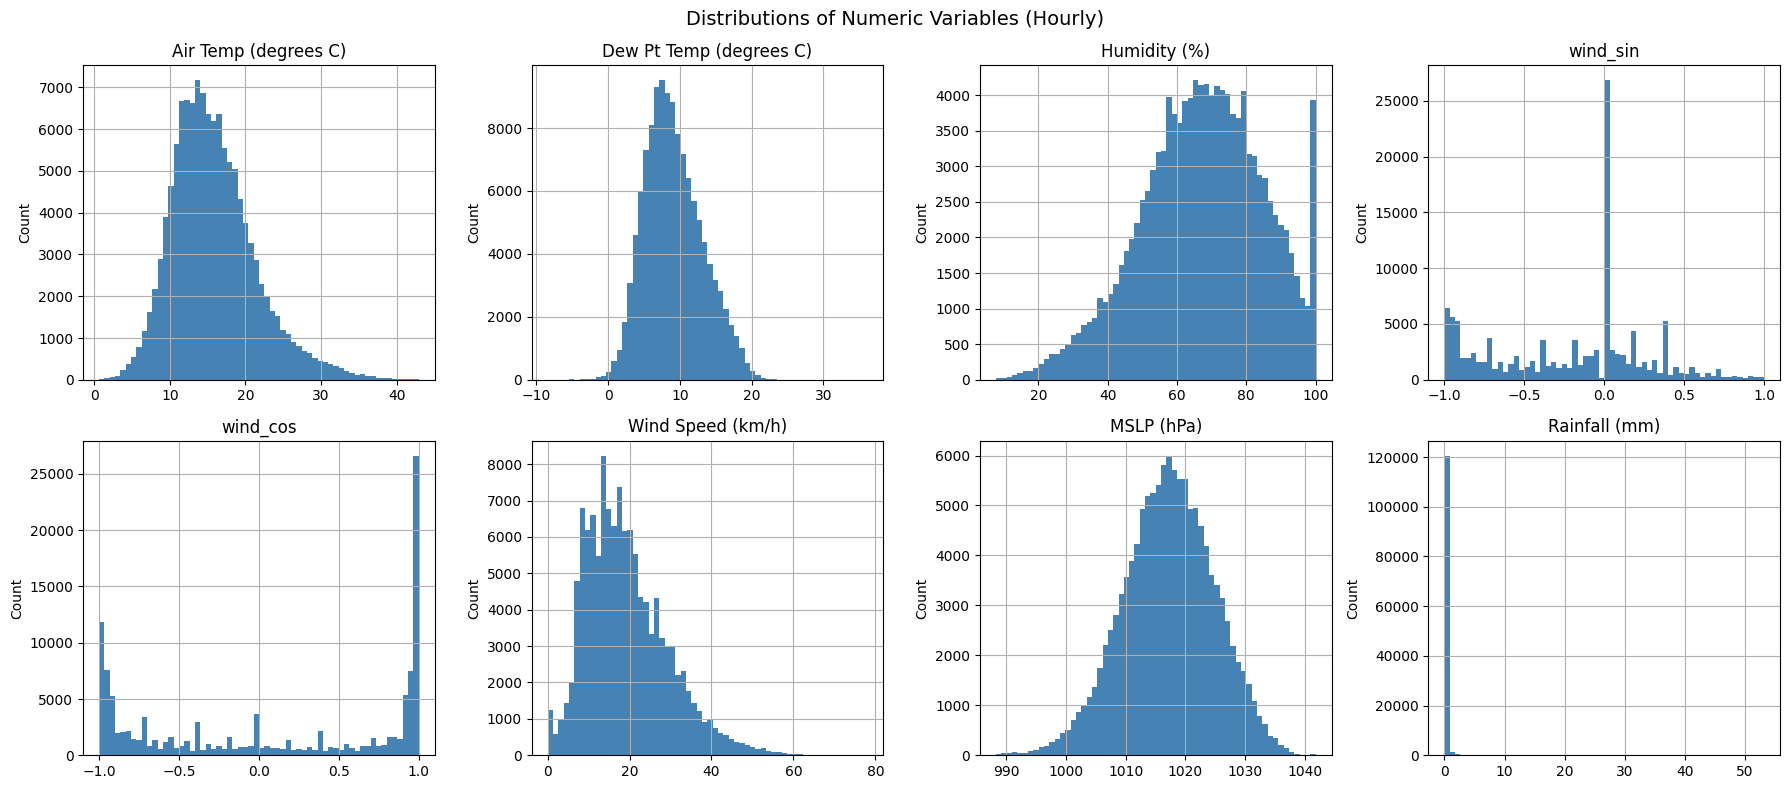

In [42]:
numeric_cols = ['Air Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
                'wind_sin', 'wind_cos', 'Wind Speed (km/h)', 'MSLP (hPa)', 'Rainfall (mm)']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distributions of Numeric Variables (Hourly)', fontsize=14)

for ax, col in zip(axes.flatten(), numeric_cols):
    all_df[col].hist(bins=60, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_01_variable_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


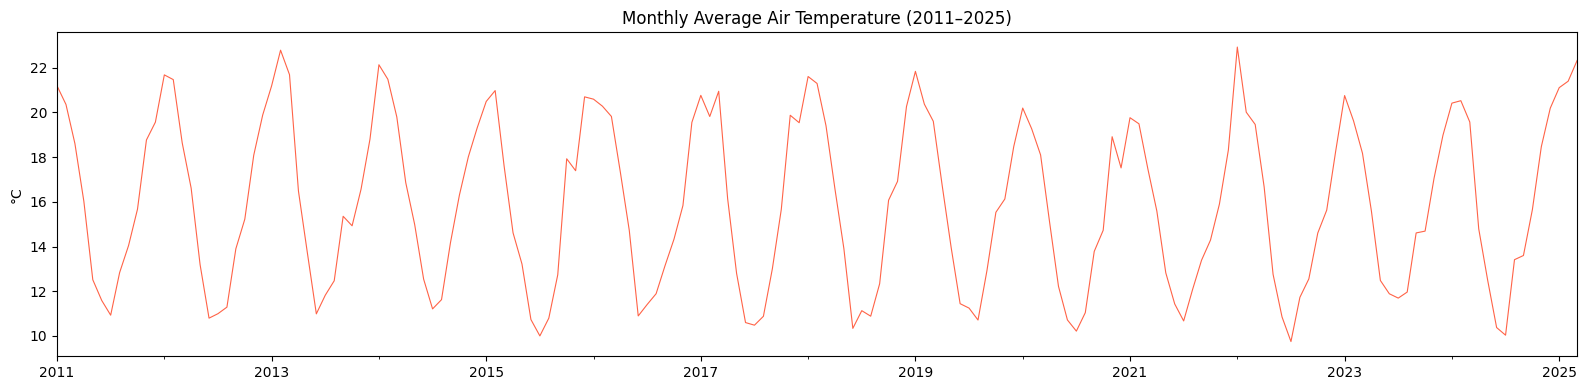

In [43]:
# Monthly average temperature — seasonal pattern
monthly_avg = all_df['Air Temp (degrees C)'].resample('ME').mean()

fig, ax = plt.subplots(figsize=(16, 4))
monthly_avg.plot(ax=ax, color='tomato', linewidth=0.8)
ax.set_title('Monthly Average Air Temperature (2011–2025)')
ax.set_ylabel('°C')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_02_monthly_avg_temperature.png', dpi=300, bbox_inches='tight')
plt.show()


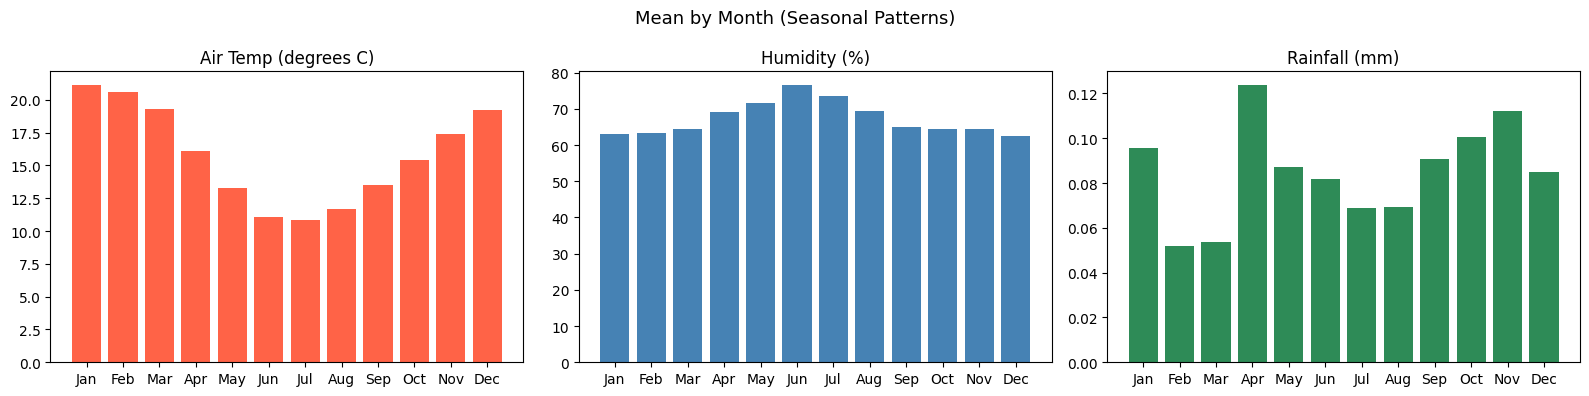

In [44]:
# Average by month-of-year to show seasonality
all_df['month'] = all_df.index.month
seasonal = all_df.groupby('month')[['Air Temp (degrees C)', 'Humidity (%)', 'Rainfall (mm)']].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Mean by Month (Seasonal Patterns)', fontsize=13)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for ax, col, color in zip(axes, seasonal.columns, ['tomato', 'steelblue', 'seagreen']):
    ax.bar(seasonal.index, seasonal[col], color=color)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_title(col)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_03_seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

all_df.drop(columns=['month'], inplace=True)


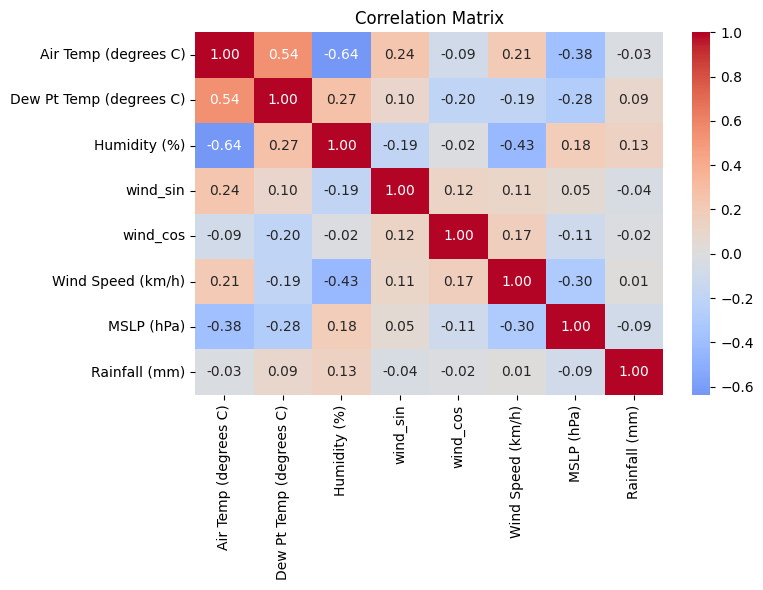

In [45]:
# Correlation heatmap (numeric columns only)
corr = all_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_04_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


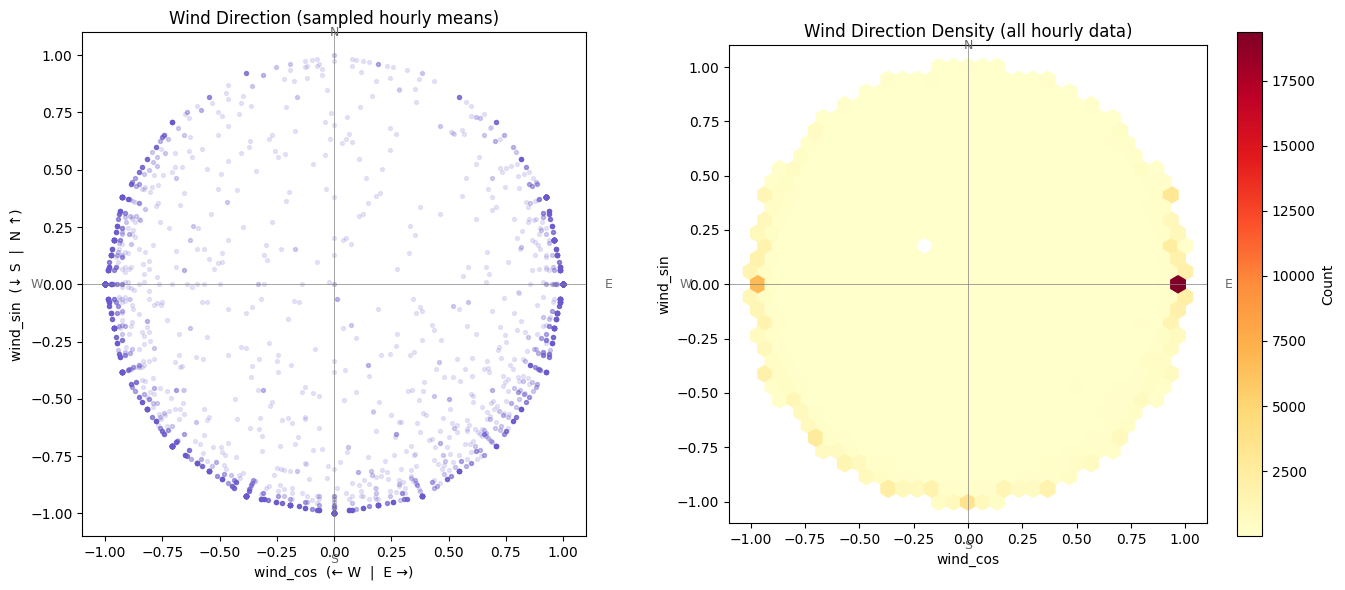

In [46]:
# Wind direction: scatter of hourly-mean sin/cos components on the unit circle
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample = all_df[['wind_sin', 'wind_cos']].dropna().sample(5000, random_state=42)
axes[0].scatter(sample['wind_cos'], sample['wind_sin'], alpha=0.15, s=8, color='slateblue')
axes[0].set_xlabel('wind_cos  (← W  |  E →)')
axes[0].set_ylabel('wind_sin  (↓ S  |  N ↑)')
axes[0].set_title('Wind Direction (sampled hourly means)')
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].axvline(0, color='grey', linewidth=0.5)
axes[0].set_aspect('equal')

hb = axes[1].hexbin(all_df['wind_cos'], all_df['wind_sin'],
                    gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('wind_cos')
axes[1].set_ylabel('wind_sin')
axes[1].set_title('Wind Direction Density (all hourly data)')
axes[1].axhline(0, color='grey', linewidth=0.5)
axes[1].axvline(0, color='grey', linewidth=0.5)
axes[1].set_aspect('equal')
fig.colorbar(hb, ax=axes[1], label='Count')

for label, (cx, cy) in [('N',(0,1.1)),('S',(0,-1.2)),('E',(1.2,0)),('W',(-1.3,0))]:
    for ax in axes:
        ax.text(cx, cy, label, ha='center', va='center', fontsize=9, color='dimgrey')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_05_wind_direction.png', dpi=300, bbox_inches='tight')
plt.show()


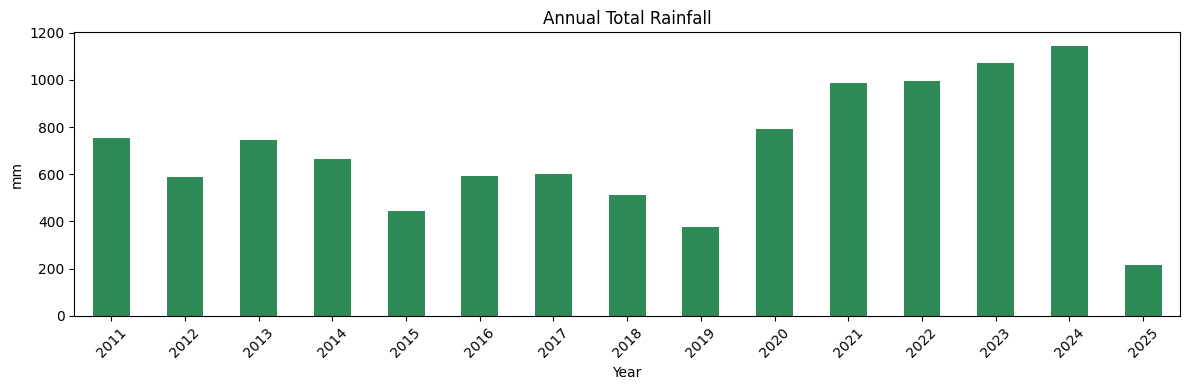

In [47]:
# Rainfall: annual total (summing hourly increments gives true annual rainfall)
all_df['year'] = all_df.index.year
annual_rain = all_df.groupby('year')['Rainfall (mm)'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
annual_rain.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Annual Total Rainfall')
ax.set_ylabel('mm')
ax.set_xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_06_annual_rainfall.png', dpi=300, bbox_inches='tight')
plt.show()

all_df.drop(columns=['year'], inplace=True)


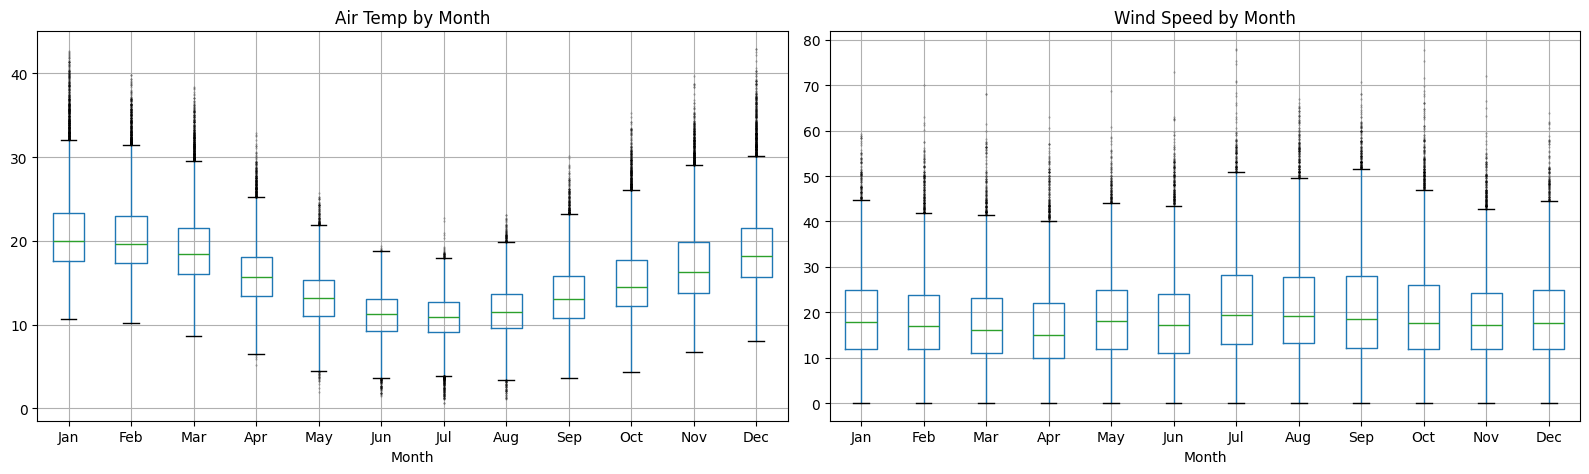

In [48]:
# Boxplots by month to visualise spread and outliers
all_df['month'] = all_df.index.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

all_df.boxplot(column='Air Temp (degrees C)', by='month', ax=axes[0],
               flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[0].set_title('Air Temp by Month')
axes[0].set_xlabel('Month')
axes[0].set_xticklabels(month_labels)

all_df.boxplot(column='Wind Speed (km/h)', by='month', ax=axes[1],
               flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[1].set_title('Wind Speed by Month')
axes[1].set_xlabel('Month')
axes[1].set_xticklabels(month_labels)

fig.suptitle('')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_07_boxplots_by_month.png', dpi=300, bbox_inches='tight')
plt.show()

all_df.drop(columns=['month'], inplace=True)


## Feature Engineering


In [49]:
# Aggregate hourly -> daily
daily_df = all_df.resample('D').agg({
    'Air Temp (degrees C)':     ['mean', 'min', 'max'],
    'Dew Pt Temp (degrees C)':  'mean',
    'Humidity (%)':             'mean',
    'wind_sin':                 'mean',
    'wind_cos':                 'mean',
    'Wind Speed (km/h)':        ['mean', 'max'],
    'MSLP (hPa)':               'mean',
    'Rainfall (mm)':            'sum',
})
daily_df.columns = ['_'.join(c).strip() for c in daily_df.columns]
daily_df = daily_df.rename(columns={
    'Air Temp (degrees C)_mean': 'temp_mean',
    'Air Temp (degrees C)_min':  'temp_min',
    'Air Temp (degrees C)_max':  'temp_max',
    'Dew Pt Temp (degrees C)_mean': 'dewpt_mean',
    'Humidity (%)_mean':         'humidity_mean',
    'wind_sin_mean':             'wind_sin',
    'wind_cos_mean':             'wind_cos',
    'Wind Speed (km/h)_mean':    'wind_speed_mean',
    'Wind Speed (km/h)_max':     'wind_speed_max',
    'MSLP (hPa)_mean':          'mslp_mean',
    'Rainfall (mm)_sum':        'rainfall_total',
})
daily_df = daily_df.dropna(subset=['temp_mean'])
print(daily_df.shape)
daily_df.head()


(5185, 11)


,temp_mean,temp_min,temp_max,dewpt_mean,humidity_mean,wind_sin,wind_cos,wind_speed_mean,wind_speed_max,mslp_mean,rainfall_total
Timestamp,,,,,,,,,,,
2011-01-01,19.730208,16.916667,24.600000,12.075764,61.636806,-0.050928,-0.683023,14.066667,26.400000,1011.634514,0.0
2011-01-02,18.020833,15.366667,20.683333,8.277000,53.436667,0.151935,-0.955823,21.467500,31.000000,1016.155083,0.0
2011-01-03,16.548750,14.266667,19.800000,5.489583,48.026389,0.253060,-0.919275,24.220833,30.800000,1016.906111,0.0
2011-01-04,16.827014,13.150000,20.716667,8.933403,60.091667,-0.025413,-0.861826,15.691667,25.333333,1012.337292,0.0
2011-01-05,18.089514,14.700000,21.183333,11.718333,66.663194,-0.327862,-0.665911,19.762500,29.500000,1010.039444,0.0


In [50]:
# Cyclical time features: day-of-year encodes the annual cycle
doy = daily_df.index.day_of_year
daily_df['doy_sin'] = np.sin(2 * np.pi * doy / 365)
daily_df['doy_cos'] = np.cos(2 * np.pi * doy / 365)

# Month as integer (useful for tree models)
daily_df['month'] = daily_df.index.month

daily_df[['doy_sin', 'doy_cos', 'month']].head()


,doy_sin,doy_cos,month
Timestamp,,,
2011-01-01,0.017213,0.999852,1
2011-01-02,0.034422,0.999407,1
2011-01-03,0.051620,0.998667,1
2011-01-04,0.068802,0.997630,1
2011-01-05,0.085965,0.996298,1


In [51]:
# Lag features: weather from 1, 2, 3, and 7 days ago
lag_cols = ['temp_mean', 'temp_max', 'humidity_mean', 'mslp_mean',
            'wind_speed_mean', 'rainfall_total', 'wind_sin', 'wind_cos']

for lag in [1, 2, 3, 7]:
    for col in lag_cols:
        daily_df[f'{col}_lag{lag}'] = daily_df[col].shift(lag)

print(f'Features after lag engineering: {daily_df.shape[1]}')
daily_df.head()


Features after lag engineering: 46


,temp_mean,temp_min,temp_max,dewpt_mean,humidity_mean,wind_sin,wind_cos,wind_speed_mean,wind_speed_max,mslp_mean,...,wind_sin_lag3,wind_cos_lag3,temp_mean_lag7,temp_max_lag7,humidity_mean_lag7,mslp_mean_lag7,wind_speed_mean_lag7,rainfall_total_lag7,wind_sin_lag7,wind_cos_lag7
Timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01,19.730208,16.916667,24.600000,12.075764,61.636806,-0.050928,-0.683023,14.066667,26.400000,1011.634514,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,18.020833,15.366667,20.683333,8.277000,53.436667,0.151935,-0.955823,21.467500,31.000000,1016.155083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-03,16.548750,14.266667,19.800000,5.489583,48.026389,0.253060,-0.919275,24.220833,30.800000,1016.906111,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-04,16.827014,13.150000,20.716667,8.933403,60.091667,-0.025413,-0.861826,15.691667,25.333333,1012.337292,...,-0.050928,-0.683023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-05,18.089514,14.700000,21.183333,11.718333,66.663194,-0.327862,-0.665911,19.762500,29.500000,1010.039444,...,0.151935,-0.955823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
# Target: did it rain the NEXT day? (total > 0.2mm to exclude trace rain)
RAIN_THRESHOLD = 0.2
daily_df['rain_tomorrow'] = (daily_df['rainfall_total'].shift(-1) > RAIN_THRESHOLD).astype(int)

# Drop last row (no known next-day label) and rows with NaN lags (first 7 days)
daily_df = daily_df.dropna()

print(daily_df['rain_tomorrow'].value_counts())
print(f'Rain days: {daily_df["rain_tomorrow"].mean()*100:.1f}%')
print(f'Total rows: {len(daily_df)}')
daily_df.head()


rain_tomorrow
0    3294
1    1884
Name: count, dtype: int64
Rain days: 36.4%
Total rows: 5178


,temp_mean,temp_min,temp_max,dewpt_mean,humidity_mean,wind_sin,wind_cos,wind_speed_mean,wind_speed_max,mslp_mean,...,wind_cos_lag3,temp_mean_lag7,temp_max_lag7,humidity_mean_lag7,mslp_mean_lag7,wind_speed_mean_lag7,rainfall_total_lag7,wind_sin_lag7,wind_cos_lag7,rain_tomorrow
Timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-08,26.264889,19.580000,33.150000,14.711111,50.841111,-0.126407,0.433755,29.122222,39.000000,1008.669667,...,-0.665911,19.730208,24.600000,61.636806,1011.634514,14.066667,0.0,-0.050928,-0.683023,0
2011-01-09,20.359583,18.300000,22.183333,15.054306,71.713194,-0.057215,-0.921049,20.401389,26.200000,1017.192500,...,-0.201278,18.020833,20.683333,53.436667,1016.155083,21.467500,0.0,0.151935,-0.955823,1
2011-01-10,21.468125,19.840000,24.560000,18.820417,85.048611,-0.333711,-0.358277,8.389583,12.333333,1013.887986,...,0.986679,16.548750,19.800000,48.026389,1016.906111,24.220833,0.0,0.253060,-0.919275,1
2011-01-11,22.491111,20.816667,25.550000,20.264028,87.625694,0.316587,-0.129764,9.508333,23.800000,1009.369444,...,0.433755,16.827014,20.716667,60.091667,1012.337292,15.691667,0.0,-0.025413,-0.861826,1
2011-01-12,24.061528,21.333333,26.733333,21.028333,83.511111,0.381167,0.488885,18.058333,37.400000,1003.878889,...,-0.921049,18.089514,21.183333,66.663194,1010.039444,19.762500,0.0,-0.327862,-0.665911,1


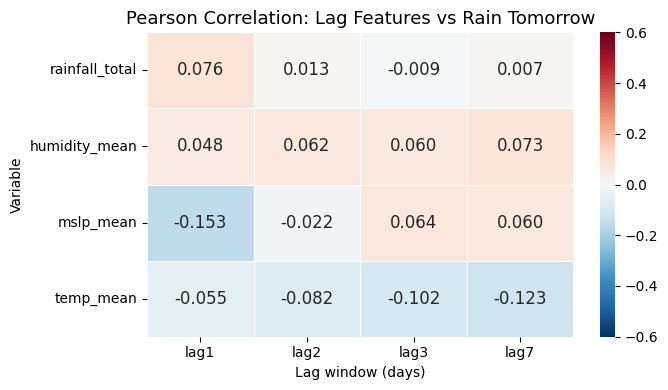

Saved: dc1_extra_lag_target_correlation_heatmap.png


In [53]:
# Correlation heatmap: lag features vs Rain target (rain_tomorrow)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

lag_vars = ['rainfall_total', 'humidity_mean', 'mslp_mean', 'temp_mean']
lag_days = [1, 2, 3, 7]

pivot = pd.DataFrame(index=lag_vars,
                     columns=[f'lag{d}' for d in lag_days],
                     dtype=float)
for var in lag_vars:
    for d in lag_days:
        col = f'{var}_lag{d}'
        if col in daily_df.columns:
            pivot.loc[var, f'lag{d}'] = daily_df[col].corr(daily_df['rain_tomorrow'])

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot.astype(float), annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6,
            linewidths=0.5, annot_kws={'size': 12}, ax=ax)
ax.set_title('Pearson Correlation: Lag Features vs Rain Tomorrow', fontsize=13)
ax.set_xlabel('Lag window (days)')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_extra_lag_target_correlation_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: dc1_extra_lag_target_correlation_heatmap.png')


## PCA


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Temporal split: last 2 years as test
split_date = '2023-01-01'
train = daily_df[daily_df.index < split_date]
test  = daily_df[daily_df.index >= split_date]

X_train = train.drop(columns=['rain_tomorrow'])
y_train = train['rain_tomorrow']
X_test  = test.drop(columns=['rain_tomorrow'])
y_test  = test['rain_tomorrow']

print(f'Train: {len(X_train)} days  ({X_train.index.min().date()} to {X_train.index.max().date()})')
print(f'Test:  {len(X_test)} days  ({X_test.index.min().date()} to {X_test.index.max().date()})')
print(f'Train rain rate: {y_train.mean()*100:.1f}%  |  Test rain rate: {y_test.mean()*100:.1f}%')


Train: 4376 days  (2011-01-08 to 2022-12-31)
Test:  802 days  (2023-01-01 to 2025-03-12)
Train rain rate: 35.2%  |  Test rain rate: 43.0%


In [55]:
# Scale: fit on train only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [56]:
# Fit PCA on training set only
pca = PCA()
pca.fit(X_train_scaled)

explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

# How many components reach 95%?
n_95 = (cumulative < 0.95).sum() + 1
print(f'Components to explain 95% of variance: {n_95} (out of {X_train_scaled.shape[1]})')


Components to explain 95% of variance: 27 (out of 46)


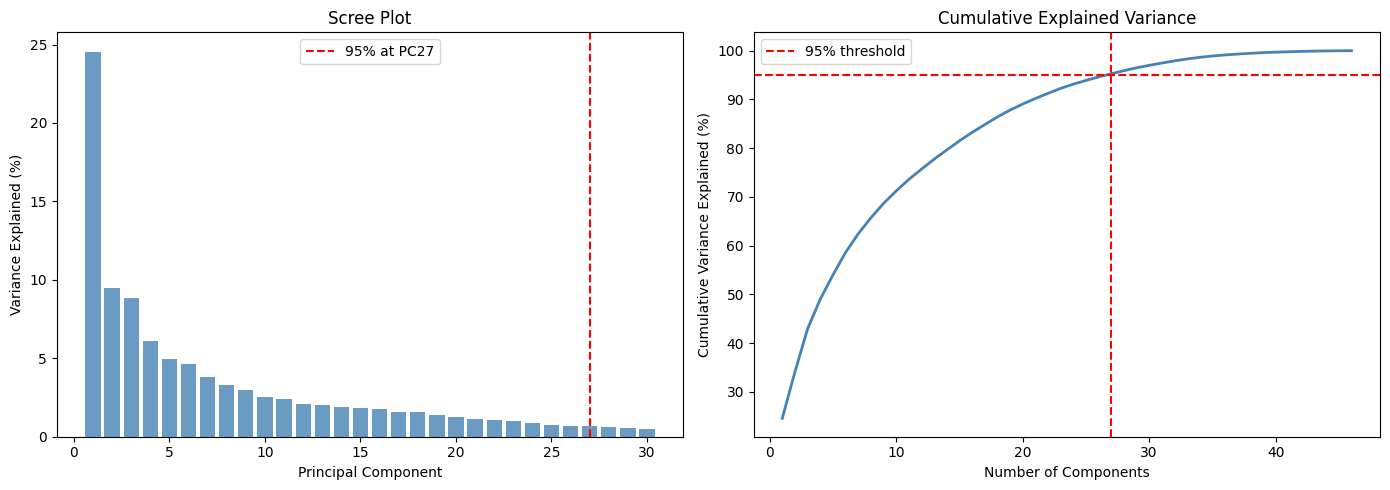

In [57]:
# Scree plot + cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), explained[:30] * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
axes[0].axvline(n_95, color='red', linestyle='--', label=f'95% at PC{n_95}')
axes[0].legend()

axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, color='steelblue', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(n_95, color='red', linestyle='--')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_08_pca_scree_cumulative.png', dpi=300, bbox_inches='tight')
plt.show()


In [58]:
# Transform train and test to n_95 components
pca_final = PCA(n_components=n_95)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

print(f'X_train_pca shape: {X_train_pca.shape}')
print(f'X_test_pca shape:  {X_test_pca.shape}')


X_train_pca shape: (4376, 27)
X_test_pca shape:  (802, 27)


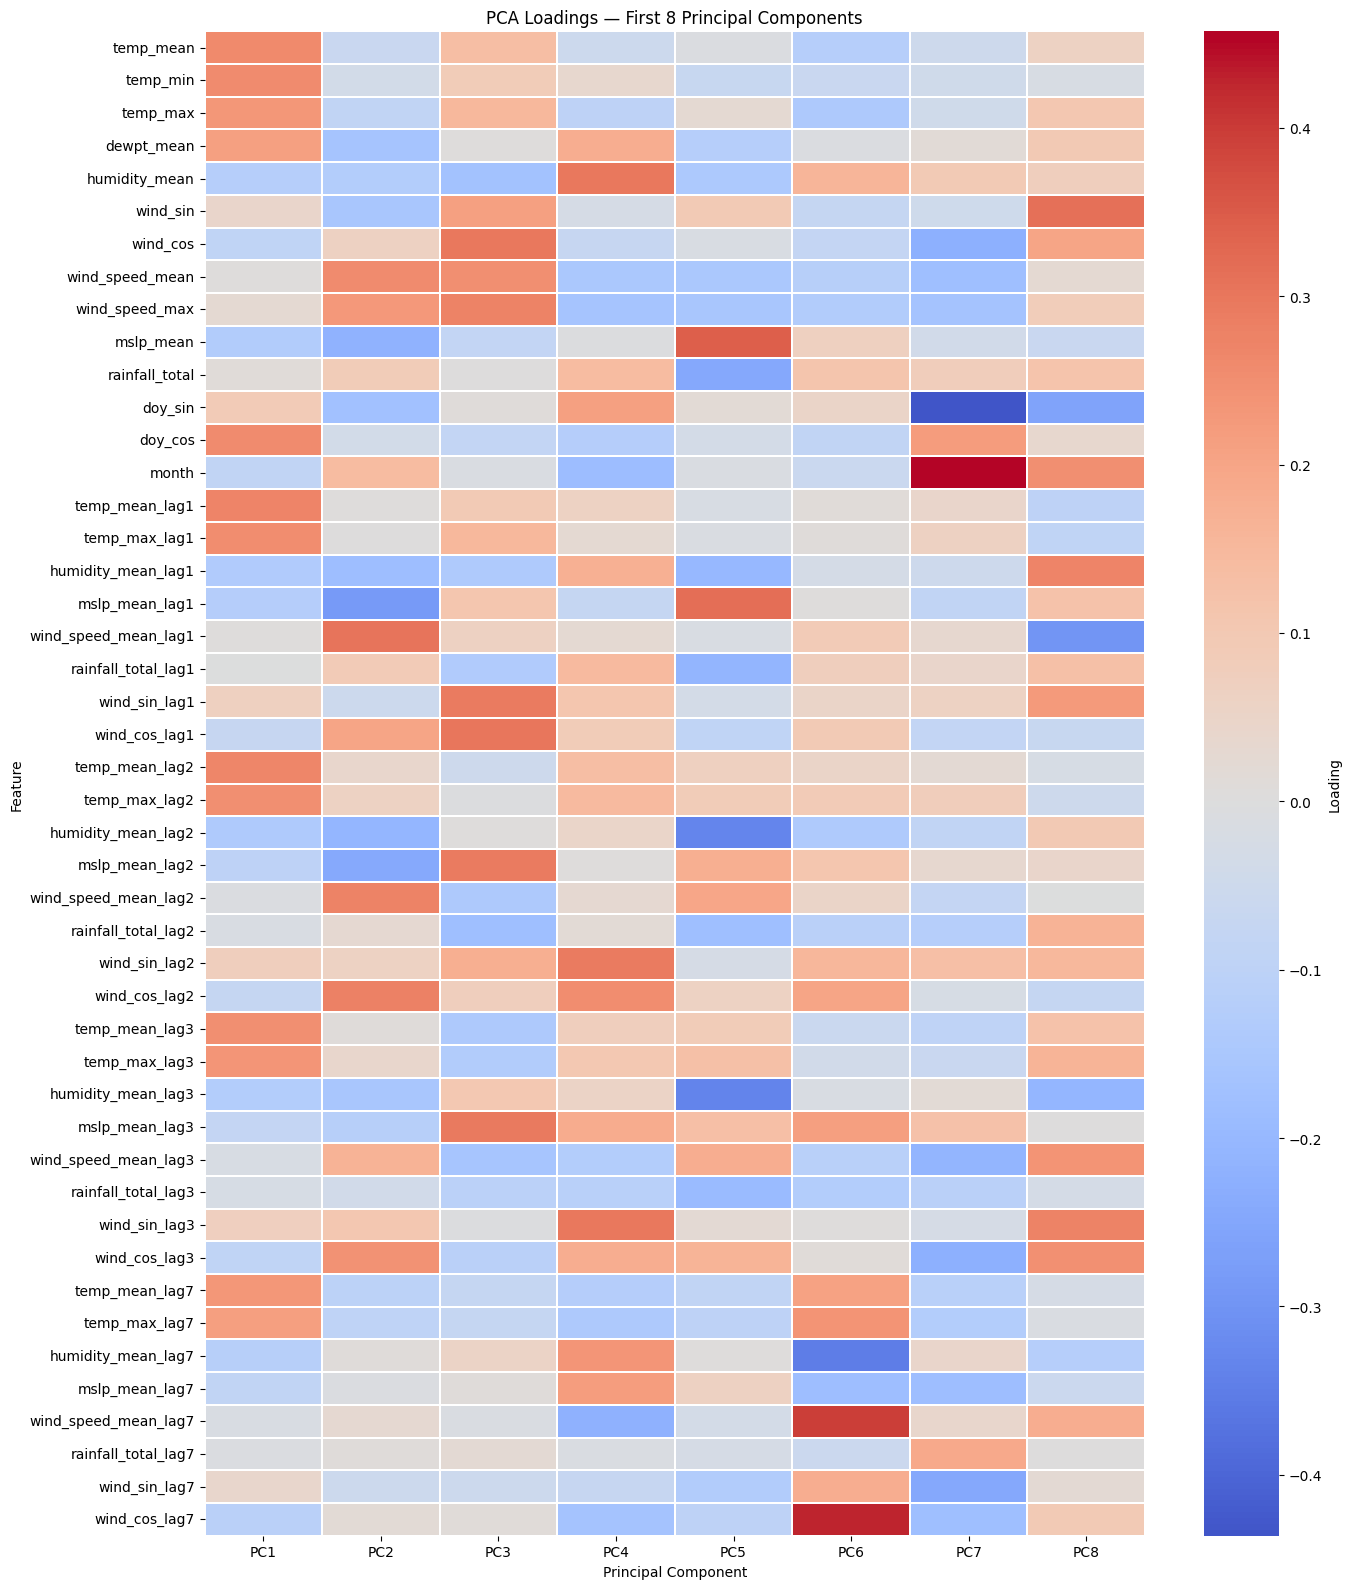

In [59]:
# Loadings heatmap: which original features drive each of the first 8 PCs
import seaborn as sns

n_show = 8
loadings = pd.DataFrame(
    pca_final.components_[:n_show].T,
    index=X_train.columns,
    columns=[f'PC{i+1}' for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(14, 16))
sns.heatmap(loadings, cmap='coolwarm', center=0, ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Loading'})
ax.set_title('PCA Loadings — First 8 Principal Components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_09_pca_loadings_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## Logistic Regression


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Train on PCA-transformed data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_pca, y_train)

y_pred  = lr.predict(X_test_pca)
y_proba = lr.predict_proba(X_test_pca)[:, 1]

print('Classification Report')
print('=' * 45)
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')


Classification Report
              precision    recall  f1-score   support

     No Rain       0.70      0.91      0.79       457
        Rain       0.80      0.48      0.60       345

    accuracy                           0.72       802
   macro avg       0.75      0.69      0.69       802
weighted avg       0.74      0.72      0.71       802

ROC-AUC: 0.7948


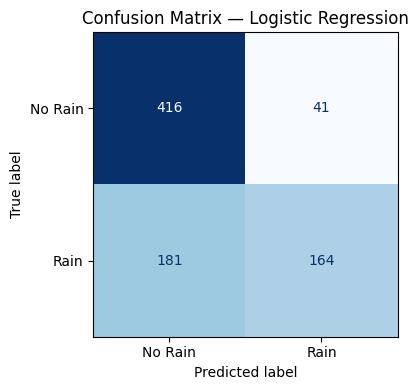

In [61]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['No Rain', 'Rain']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_10_lr_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Logistic Regression — No Lag, No Cyclical Features

Re-runs the full PCA + Logistic Regression pipeline using only the **base daily features**,
dropping all lag columns and all sin/cos cyclical encodings (`wind_sin`, `wind_cos`, `doy_sin`, `doy_cos`).

This lets us compare directly whether the lag features and cyclical encodings add predictive value.


In [62]:
# Feature set: base daily weather only — no lags, no sin/cos cyclical columns
exclude_cols = (
    ['rain_tomorrow']
    + [c for c in daily_df.columns if '_lag' in c]
    + [c for c in daily_df.columns if c in ['doy_sin', 'doy_cos', 'wind_sin', 'wind_cos']]
)
feature_cols_base = [c for c in daily_df.columns if c not in exclude_cols]
print(f'Features used ({len(feature_cols_base)}):')
print(feature_cols_base)

split_date = '2023-01-01'
train2 = daily_df[daily_df.index < split_date]
test2  = daily_df[daily_df.index >= split_date]

X_train2 = train2[feature_cols_base]
y_train2 = train2['rain_tomorrow']
X_test2  = test2[feature_cols_base]
y_test2  = test2['rain_tomorrow']

print(f'\nTrain: {len(X_train2)} days | Test: {len(X_test2)} days')
print(f'Train rain rate: {y_train2.mean()*100:.1f}%  |  Test rain rate: {y_test2.mean()*100:.1f}%')


Features used (10):
['temp_mean', 'temp_min', 'temp_max', 'dewpt_mean', 'humidity_mean', 'wind_speed_mean', 'wind_speed_max', 'mslp_mean', 'rainfall_total', 'month']

Train: 4376 days | Test: 802 days
Train rain rate: 35.2%  |  Test rain rate: 43.0%


In [63]:
# Scale and PCA — fit on train2 only
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled  = scaler2.transform(X_test2)

pca2 = PCA()
pca2.fit(X_train2_scaled)
cumulative2 = pca2.explained_variance_ratio_.cumsum()
n_95_2 = int((cumulative2 < 0.95).sum()) + 1
print(f'Components for 95% variance: {n_95_2} (out of {X_train2_scaled.shape[1]} features)')

pca2_final = PCA(n_components=n_95_2)
X_train2_pca = pca2_final.fit_transform(X_train2_scaled)
X_test2_pca  = pca2_final.transform(X_test2_scaled)
print(f'X_train2_pca shape: {X_train2_pca.shape}')


Components for 95% variance: 6 (out of 10 features)
X_train2_pca shape: (4376, 6)


In [64]:
# Logistic Regression on base features (no lag, no cyclical)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train2_pca, y_train2)

y_pred2  = lr2.predict(X_test2_pca)
y_proba2 = lr2.predict_proba(X_test2_pca)[:, 1]

print('Classification Report — No Lag / No Cyclical')
print('=' * 50)
print(classification_report(y_test2, y_pred2, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test2, y_proba2):.4f}')


Classification Report — No Lag / No Cyclical
              precision    recall  f1-score   support

     No Rain       0.67      0.94      0.78       457
        Rain       0.83      0.39      0.53       345

    accuracy                           0.70       802
   macro avg       0.75      0.67      0.66       802
weighted avg       0.74      0.70      0.68       802

ROC-AUC: 0.7732


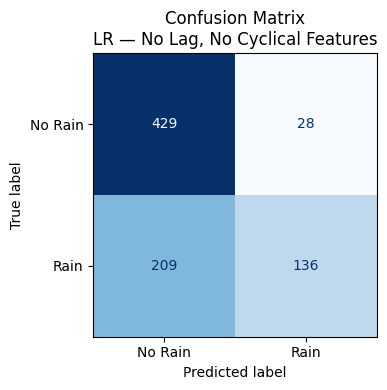

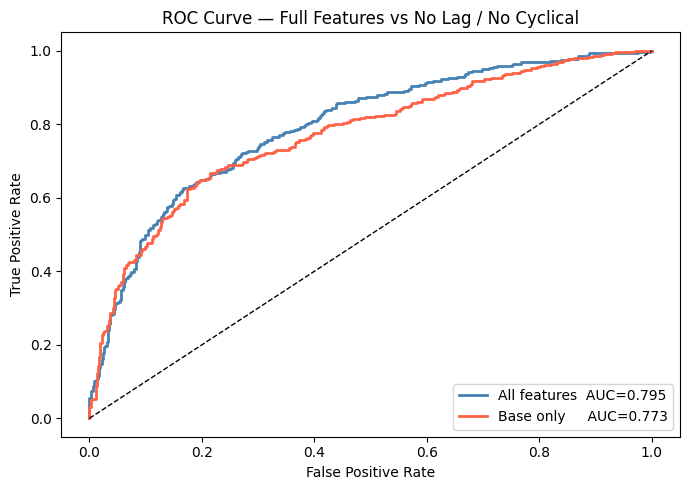

In [65]:
import matplotlib.pyplot as plt

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test2, y_pred2),
                       display_labels=['No Rain', 'Rain']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix\nLR — No Lag, No Cyclical Features')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_11_lr_no_lag_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC curve comparison
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(7, 5))
for y_prob, label, colour in [
    (y_proba,  f'All features  AUC={roc_auc_score(y_test,  y_proba):.3f}',  'steelblue'),
    (y_proba2, f'Base only     AUC={roc_auc_score(y_test2, y_proba2):.3f}', 'tomato'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=colour, label=label)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Full Features vs No Lag / No Cyclical')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_12_lr_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Logistic Regression — Class Balanced (`class_weight='balanced'`)

Reuses the PCA-transformed features from both the full model and the no-lag model,
but fits with `class_weight='balanced'` to penalise misclassifying the minority class more heavily.
Compare precision/recall/F1 and ROC-AUC against the unweighted baselines above.


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

# Full features — balanced
lr_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_bal.fit(X_train_pca, y_train)
y_pred_bal  = lr_bal.predict(X_test_pca)
y_proba_bal = lr_bal.predict_proba(X_test_pca)[:, 1]

print('Full features — class_weight=balanced')
print('=' * 45)
print(classification_report(y_test, y_pred_bal, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_bal):.4f}')


Full features — class_weight=balanced
              precision    recall  f1-score   support

     No Rain       0.76      0.75      0.76       457
        Rain       0.68      0.68      0.68       345

    accuracy                           0.72       802
   macro avg       0.72      0.72      0.72       802
weighted avg       0.72      0.72      0.72       802

ROC-AUC: 0.7969


In [67]:
# No-lag / no-cyclical features — balanced
lr2_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr2_bal.fit(X_train2_pca, y_train2)
y_pred2_bal  = lr2_bal.predict(X_test2_pca)
y_proba2_bal = lr2_bal.predict_proba(X_test2_pca)[:, 1]

print('No-lag / no-cyclical — class_weight=balanced')
print('=' * 45)
print(classification_report(y_test2, y_pred2_bal, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test2, y_proba2_bal):.4f}')


No-lag / no-cyclical — class_weight=balanced
              precision    recall  f1-score   support

     No Rain       0.75      0.79      0.77       457
        Rain       0.70      0.65      0.68       345

    accuracy                           0.73       802
   macro avg       0.73      0.72      0.72       802
weighted avg       0.73      0.73      0.73       802

ROC-AUC: 0.7735


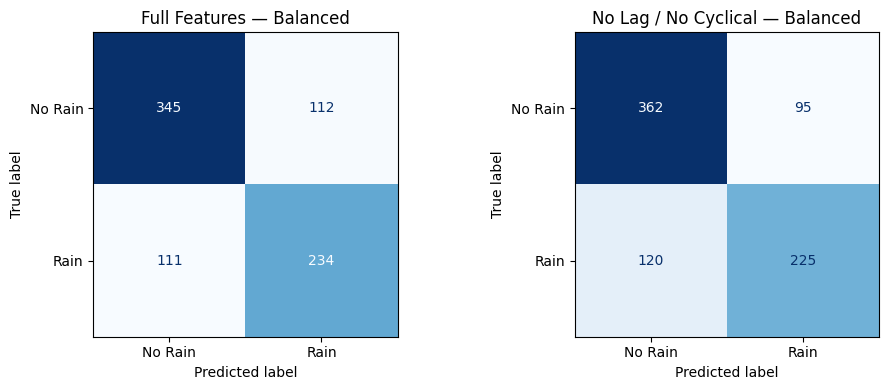

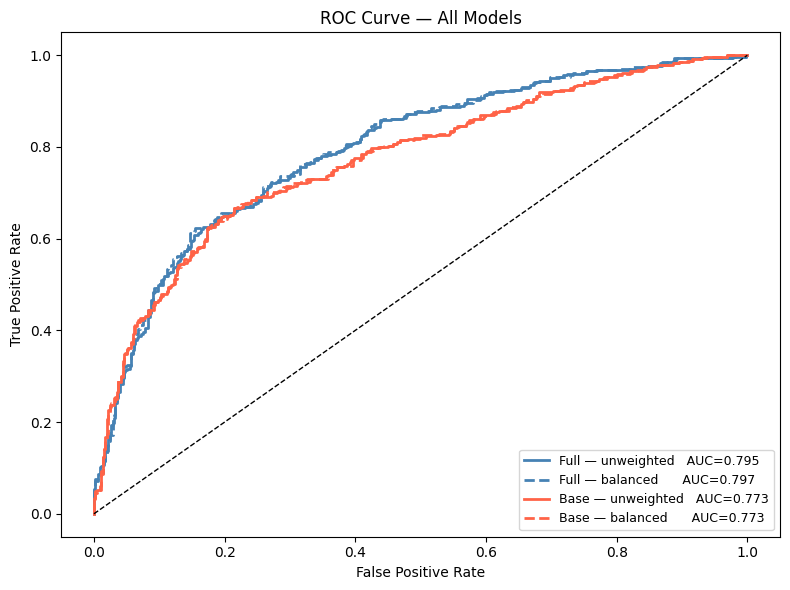

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_p, title in [
    (axes[0], y_pred_bal,  'Full Features — Balanced'),
    (axes[1], y_pred2_bal, 'No Lag / No Cyclical — Balanced'),
]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_p),
                          display_labels=['No Rain', 'Rain']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_13_balanced_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC: all 4 models on one axes
fig, ax = plt.subplots(figsize=(8, 6))
for y_prob, label, colour, ls in [
    (y_proba,     f'Full — unweighted   AUC={roc_auc_score(y_test,  y_proba):.3f}',     'steelblue', '-'),
    (y_proba_bal, f'Full — balanced      AUC={roc_auc_score(y_test,  y_proba_bal):.3f}', 'steelblue', '--'),
    (y_proba2,    f'Base — unweighted   AUC={roc_auc_score(y_test2, y_proba2):.3f}',    'tomato',    '-'),
    (y_proba2_bal,f'Base — balanced      AUC={roc_auc_score(y_test2, y_proba2_bal):.3f}','tomato',    '--'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=colour, linestyle=ls, label=label)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — All Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_14_all_models_roc.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Feature Importance Tables

Logistic Regression coefficients live in PCA space, not the original feature space.
To recover per-feature importance we project back:

```
effective_importance = PCA_loadings @ LR_coefficients
```

Positive values push the model toward predicting Rain; negative toward No Rain.
Absolute value gives overall importance regardless of direction.
Tables are shown for all four models.


In [69]:
import pandas as pd
import numpy as np

def feature_importance_table(lr_model, pca_model, feature_names, top_n=None):
    """Project LR coefficients back through PCA loadings."""
    loadings   = pca_model.components_.T          # shape (n_features, n_components)
    coef       = lr_model.coef_[0]                # shape (n_components,)
    importance = loadings @ coef                  # shape (n_features,)
    df = pd.DataFrame({
        'Feature':    feature_names,
        'Importance': importance,
        'Abs':        np.abs(importance),
        'Direction':  ['→ Rain' if v > 0 else '→ No Rain' for v in importance],
    }).sort_values('Abs', ascending=False).reset_index(drop=True)
    df.index += 1
    if top_n:
        df = df.head(top_n)
    return df.drop(columns='Abs')

# ── Full features (unweighted) ──
print('=' * 60)
print('Model 1 — Full Features, Unweighted LR')
print('=' * 60)
t1 = feature_importance_table(lr, pca_final, X_train.columns.tolist())
print(t1.to_string())

# ── Full features (balanced) ──
print('\n' + '=' * 60)
print('Model 2 — Full Features, Balanced LR')
print('=' * 60)
t2 = feature_importance_table(lr_bal, pca_final, X_train.columns.tolist())
print(t2.to_string())

# ── No-lag / no-cyclical (unweighted) ──
print('\n' + '=' * 60)
print('Model 3 — No Lag / No Cyclical, Unweighted LR')
print('=' * 60)
t3 = feature_importance_table(lr2, pca2_final, X_train2.columns.tolist())
print(t3.to_string())

# ── No-lag / no-cyclical (balanced) ──
print('\n' + '=' * 60)
print('Model 4 — No Lag / No Cyclical, Balanced LR')
print('=' * 60)
t4 = feature_importance_table(lr2_bal, pca2_final, X_train2.columns.tolist())
print(t4.to_string())


Model 1 — Full Features, Unweighted LR
                 Feature  Importance  Direction
1              mslp_mean   -0.604898  → No Rain
2               wind_cos    0.453661     → Rain
3         rainfall_total    0.368271     → Rain
4         mslp_mean_lag1   -0.237992  → No Rain
5         mslp_mean_lag3    0.235445     → Rain
6          humidity_mean    0.178586     → Rain
7             dewpt_mean    0.108571     → Rain
8          wind_cos_lag7    0.106809     → Rain
9     humidity_mean_lag3   -0.106401  → No Rain
10         wind_cos_lag1    0.103800     → Rain
11    humidity_mean_lag1    0.103133     → Rain
12         temp_max_lag1   -0.098555  → No Rain
13         wind_sin_lag2   -0.091623  → No Rain
14        wind_speed_max    0.087791     → Rain
15         wind_sin_lag7   -0.087717  → No Rain
16         wind_sin_lag3    0.080927     → Rain
17        mslp_mean_lag7    0.079339     → Rain
18                 month    0.075477     → Rain
19  wind_speed_mean_lag3   -0.073537  → No Rain
2

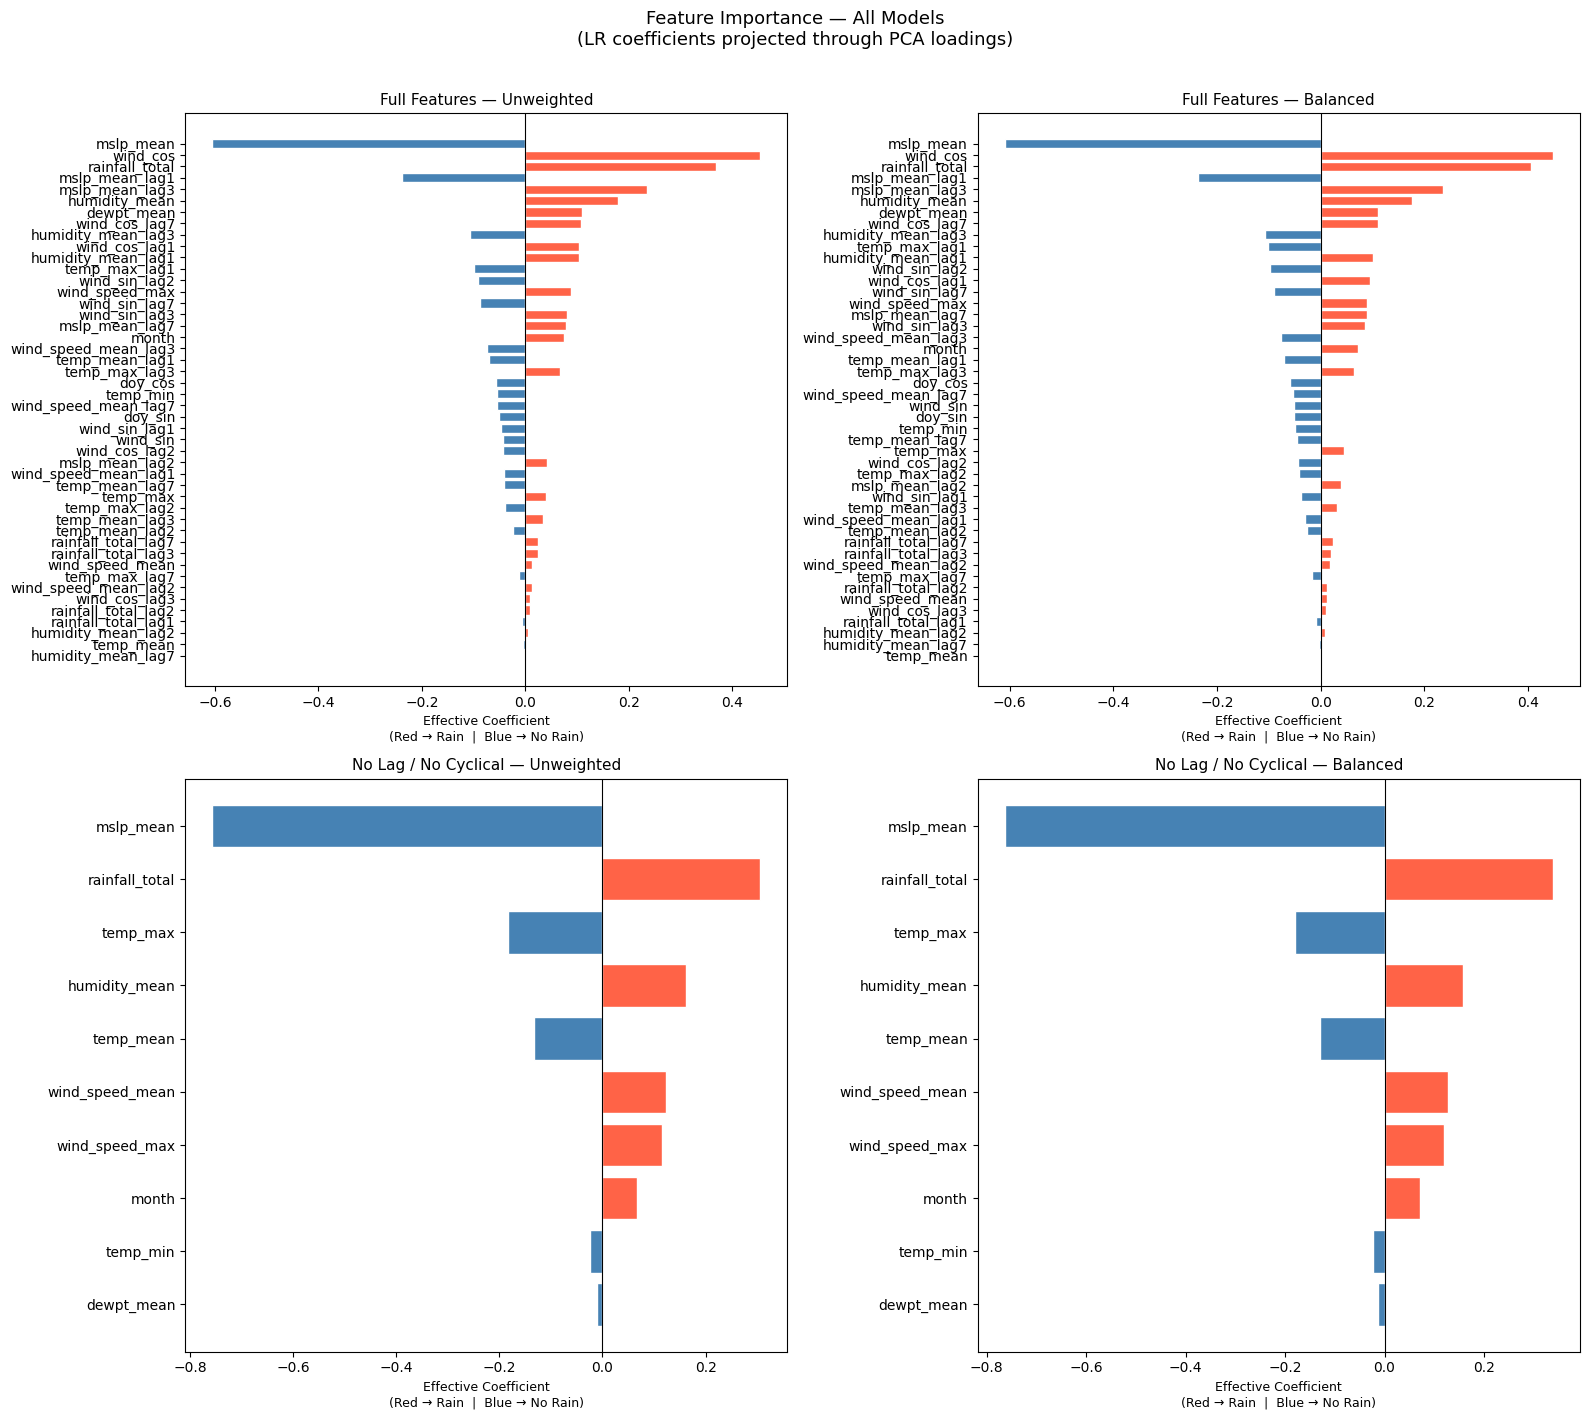

In [70]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
titles = [
    'Full Features — Unweighted',
    'Full Features — Balanced',
    'No Lag / No Cyclical — Unweighted',
    'No Lag / No Cyclical — Balanced',
]
tables = [t1, t2, t3, t4]

for ax, df, title in zip(axes.flatten(), tables, titles):
    colours = ['tomato' if d == '→ Rain' else 'steelblue' for d in df['Direction']]
    ax.barh(df['Feature'][::-1], df['Importance'][::-1], color=colours[::-1], edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Effective Coefficient\n(Red → Rain  |  Blue → No Rain)', fontsize=9)

plt.suptitle('Feature Importance — All Models\n(LR coefficients projected through PCA loadings)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_15_feature_importance_all_models.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Class-Balanced LR — Pruned Features (drop < 0.2% relative importance)

Uses the balanced model's effective feature importances to remove any feature
whose absolute contribution is less than **0.2%** of the total absolute importance sum.
The pruned feature set is then re-run through the full pipeline: scale → PCA → LR (balanced).


In [71]:
import numpy as np
import pandas as pd

# Compute effective importance from the full-feature balanced model
loadings_bal  = pca_final.components_.T       # (n_features, n_components)
importance_bal = loadings_bal @ lr_bal.coef_[0]  # (n_features,)
abs_imp       = np.abs(importance_bal)
rel_imp_pct   = 100 * abs_imp / abs_imp.sum()  # relative % of total

imp_df = pd.DataFrame({
    'Feature':       X_train.columns.tolist(),
    'Importance':    importance_bal,
    'Abs':           abs_imp,
    'Relative (%)':  rel_imp_pct,
    'Direction':     ['→ Rain' if v > 0 else '→ No Rain' for v in importance_bal],
}).sort_values('Abs', ascending=False).reset_index(drop=True)
imp_df.index += 1

THRESHOLD = 0.2  # drop features below this % of total importance
keep_mask    = imp_df['Relative (%)'] >= THRESHOLD
drop_mask    = ~keep_mask

print(f'Importance threshold : {THRESHOLD}% of total')
print(f'Features kept        : {keep_mask.sum()} / {len(imp_df)}')
print(f'Features dropped     : {drop_mask.sum()}')
print()
print(imp_df[['Feature','Relative (%)','Direction']].to_string())

kept_features    = imp_df.loc[keep_mask,  'Feature'].tolist()
dropped_features = imp_df.loc[drop_mask, 'Feature'].tolist()
print(f'\nDropped: {dropped_features}')


Importance threshold : 0.2% of total
Features kept        : 43 / 46
Features dropped     : 3

                 Feature  Relative (%)  Direction
1              mslp_mean     14.441727  → No Rain
2               wind_cos     10.607093     → Rain
3         rainfall_total      9.622981     → Rain
4         mslp_mean_lag1      5.627752  → No Rain
5         mslp_mean_lag3      5.611964     → Rain
6          humidity_mean      4.174428     → Rain
7             dewpt_mean      2.639422     → Rain
8          wind_cos_lag7      2.620160     → Rain
9     humidity_mean_lag3      2.568648  → No Rain
10         temp_max_lag1      2.431292  → No Rain
11    humidity_mean_lag1      2.395864     → Rain
12         wind_sin_lag2      2.321219  → No Rain
13         wind_cos_lag1      2.244176     → Rain
14         wind_sin_lag7      2.147992  → No Rain
15        wind_speed_max      2.122551     → Rain
16        mslp_mean_lag7      2.099020     → Rain
17         wind_sin_lag3      2.027658     → Rain
18  wi

In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)

# Subset to kept features
X_train_pr = X_train[kept_features]
X_test_pr  = X_test[kept_features]

# Scale
scaler_pr = StandardScaler()
X_train_pr_scaled = scaler_pr.fit_transform(X_train_pr)
X_test_pr_scaled  = scaler_pr.transform(X_test_pr)

# PCA
pca_pr = PCA()
pca_pr.fit(X_train_pr_scaled)
cum_pr = pca_pr.explained_variance_ratio_.cumsum()
n_95_pr = int((cum_pr < 0.95).sum()) + 1
print(f'PCA components for 95% variance: {n_95_pr} (from {len(kept_features)} features)')

pca_pr_final = PCA(n_components=n_95_pr)
X_train_pr_pca = pca_pr_final.fit_transform(X_train_pr_scaled)
X_test_pr_pca  = pca_pr_final.transform(X_test_pr_scaled)

# Logistic Regression — balanced
lr_pr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_pr.fit(X_train_pr_pca, y_train)

y_pred_pr  = lr_pr.predict(X_test_pr_pca)
y_proba_pr = lr_pr.predict_proba(X_test_pr_pca)[:, 1]

print('\nClassification Report — Pruned Features, Balanced LR')
print('=' * 52)
print(classification_report(y_test, y_pred_pr, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_pr):.4f}')


PCA components for 95% variance: 26 (from 43 features)

Classification Report — Pruned Features, Balanced LR
              precision    recall  f1-score   support

     No Rain       0.76      0.75      0.75       457
        Rain       0.67      0.68      0.68       345

    accuracy                           0.72       802
   macro avg       0.71      0.71      0.71       802
weighted avg       0.72      0.72      0.72       802

ROC-AUC: 0.7965


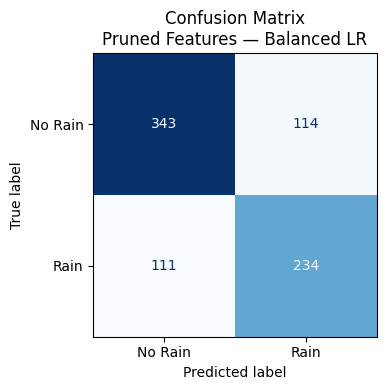

Feature Importance — Pruned Balanced Model
                 Feature  Importance  Relative (%)  Direction
1              mslp_mean     -0.6141       14.5285  → No Rain
2               wind_cos      0.4331       10.2469     → Rain
3         rainfall_total      0.4213        9.9673     → Rain
4         mslp_mean_lag3      0.2423        5.7313     → Rain
5         mslp_mean_lag1     -0.2401        5.6797  → No Rain
6          humidity_mean      0.1618        3.8290     → Rain
7          wind_cos_lag7      0.1327        3.1392     → Rain
8     humidity_mean_lag3     -0.1253        2.9649  → No Rain
9             dewpt_mean      0.1067        2.5234     → Rain
10         wind_sin_lag2     -0.1020        2.4136  → No Rain
11         temp_max_lag1     -0.1016        2.4029  → No Rain
12    humidity_mean_lag1      0.1010        2.3899     → Rain
13        wind_speed_max      0.0872        2.0632     → Rain
14         wind_sin_lag3      0.0854        2.0201     → Rain
15         wind_sin_lag7   

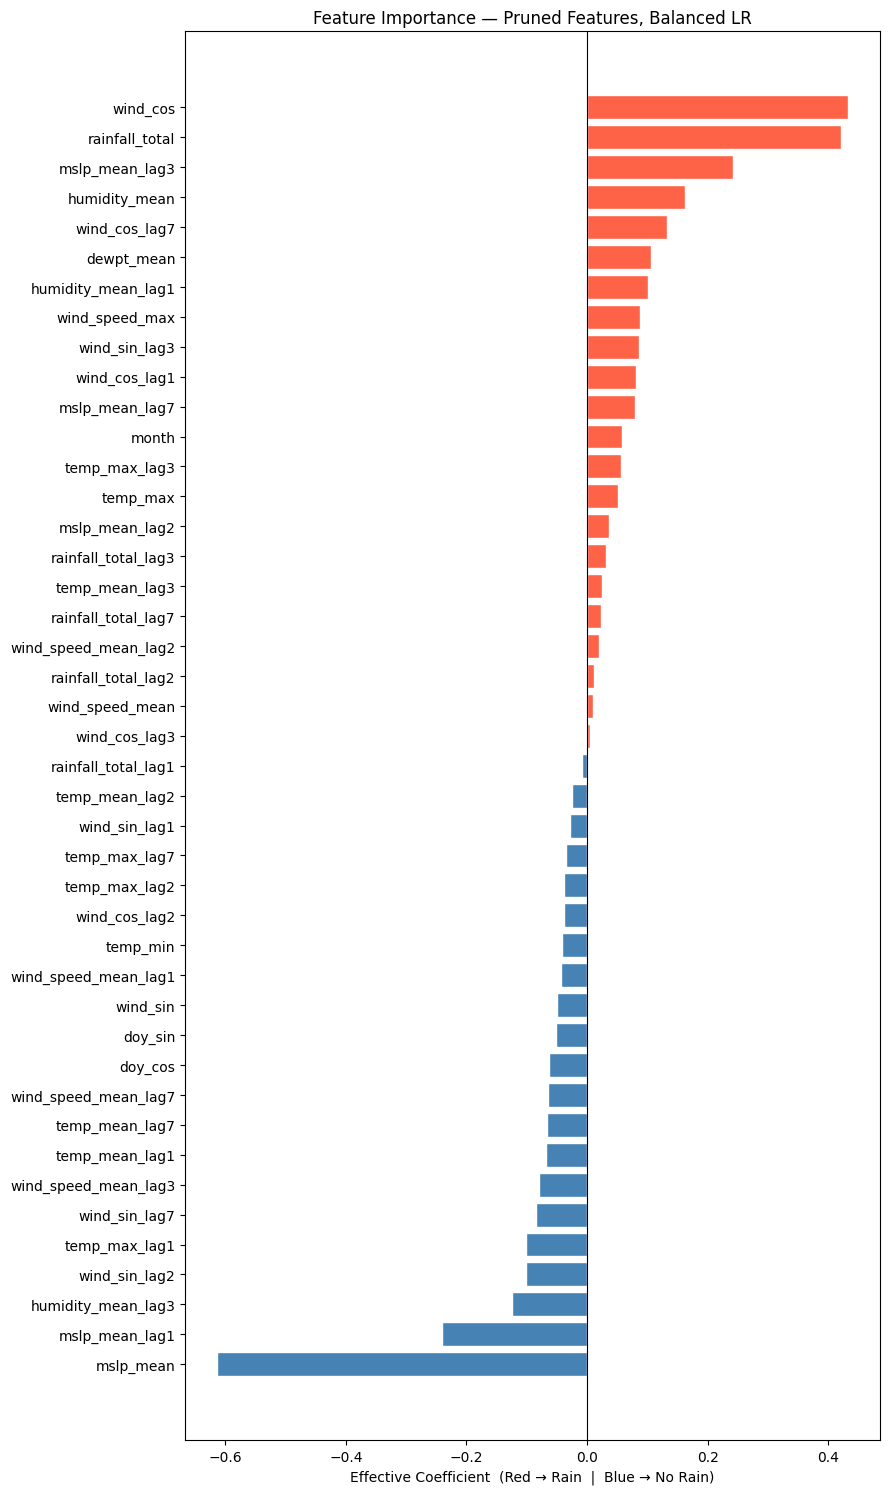

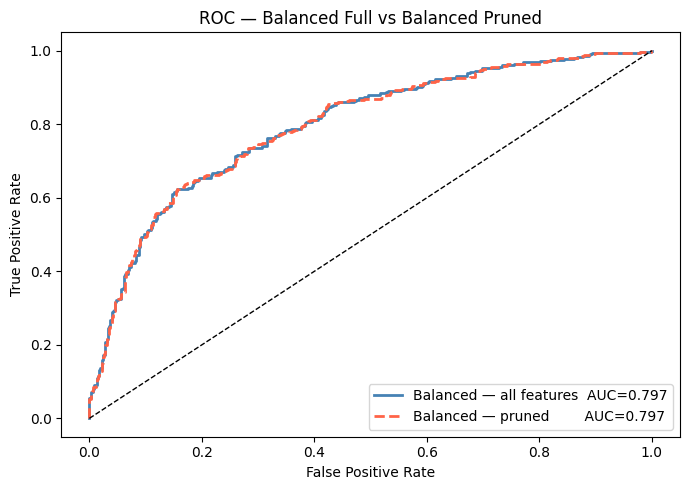

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_pr),
                       display_labels=['No Rain', 'Rain']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix\nPruned Features — Balanced LR')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_16_pruned_balanced_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature importance table for pruned model
loadings_pr   = pca_pr_final.components_.T
imp_pr        = loadings_pr @ lr_pr.coef_[0]
imp_pr_df = pd.DataFrame({
    'Feature':      kept_features,
    'Importance':   imp_pr,
    'Relative (%)': 100 * np.abs(imp_pr) / np.abs(imp_pr).sum(),
    'Direction':    ['→ Rain' if v > 0 else '→ No Rain' for v in imp_pr],
}).sort_values('Relative (%)', ascending=False).reset_index(drop=True)
imp_pr_df.index += 1
print('Feature Importance — Pruned Balanced Model')
print('=' * 52)
print(imp_pr_df[['Feature','Importance','Relative (%)','Direction']].round(4).to_string())

# Bar chart
imp_sorted = imp_pr_df.sort_values('Importance')
colours = ['tomato' if v > 0 else 'steelblue' for v in imp_sorted['Importance']]
fig, ax = plt.subplots(figsize=(9, max(4, len(kept_features) * 0.35)))
ax.barh(imp_sorted['Feature'], imp_sorted['Importance'], color=colours, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Effective Coefficient  (Red → Rain  |  Blue → No Rain)')
ax.set_title('Feature Importance — Pruned Features, Balanced LR')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_17_pruned_balanced_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC comparison: balanced full vs balanced pruned
fig, ax = plt.subplots(figsize=(7, 5))
for y_prob, label, colour, ls in [
    (y_proba_bal, f'Balanced — all features  AUC={roc_auc_score(y_test, y_proba_bal):.3f}', 'steelblue', '-'),
    (y_proba_pr,  f'Balanced — pruned        AUC={roc_auc_score(y_test, y_proba_pr):.3f}',  'tomato',    '--'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=colour, linestyle=ls, label=label)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Balanced Full vs Balanced Pruned')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_18_pruned_vs_full_roc.png', dpi=300, bbox_inches='tight')
plt.show()


---
## SMOTE — Synthetic Minority Over-sampling

SMOTE generates synthetic Rain-day samples by interpolating between existing minority-class
neighbours in feature space. Applied **after scaling, before PCA** to avoid contaminating
the test set or the PCA fit.

Pipeline: Scale (train only) → SMOTE (train only) → PCA (on resampled train) → LR


In [74]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import numpy as np

# --- Scale (fit on original train only) ---
scaler_sm = StandardScaler()
X_train_sm_scaled = scaler_sm.fit_transform(X_train)
X_test_sm_scaled  = scaler_sm.transform(X_test)

print('Before SMOTE:')
print(f'  Rain: {y_train.sum()}  |  No Rain: {(y_train==0).sum()}')

# --- SMOTE (applied to scaled train only) ---
sm = SMOTE(random_state=42)
X_train_sm_res, y_train_sm_res = sm.fit_resample(X_train_sm_scaled, y_train)

print('After SMOTE:')
print(f'  Rain: {y_train_sm_res.sum()}  |  No Rain: {(y_train_sm_res==0).sum()}')
print(f'  Total training samples: {len(y_train_sm_res)}')

# --- PCA (fit on resampled train) ---
pca_sm = PCA()
pca_sm.fit(X_train_sm_res)
cum_sm = pca_sm.explained_variance_ratio_.cumsum()
n_95_sm = int((cum_sm < 0.95).sum()) + 1
print(f'\nPCA components for 95% variance: {n_95_sm}')

pca_sm_final = PCA(n_components=n_95_sm)
X_train_sm_pca = pca_sm_final.fit_transform(X_train_sm_res)
X_test_sm_pca  = pca_sm_final.transform(X_test_sm_scaled)

# --- Logistic Regression ---
lr_sm = LogisticRegression(max_iter=1000, random_state=42)
lr_sm.fit(X_train_sm_pca, y_train_sm_res)

y_pred_sm  = lr_sm.predict(X_test_sm_pca)
y_proba_sm = lr_sm.predict_proba(X_test_sm_pca)[:, 1]

print('\nClassification Report — SMOTE')
print('=' * 45)
print(classification_report(y_test, y_pred_sm, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_sm):.4f}')


Before SMOTE:
  Rain: 1539  |  No Rain: 2837
After SMOTE:
  Rain: 2837  |  No Rain: 2837
  Total training samples: 5674

PCA components for 95% variance: 27

Classification Report — SMOTE
              precision    recall  f1-score   support

     No Rain       0.76      0.76      0.76       457
        Rain       0.68      0.68      0.68       345

    accuracy                           0.72       802
   macro avg       0.72      0.72      0.72       802
weighted avg       0.72      0.72      0.72       802

ROC-AUC: 0.7938


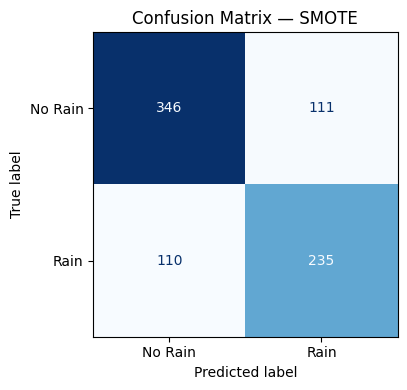

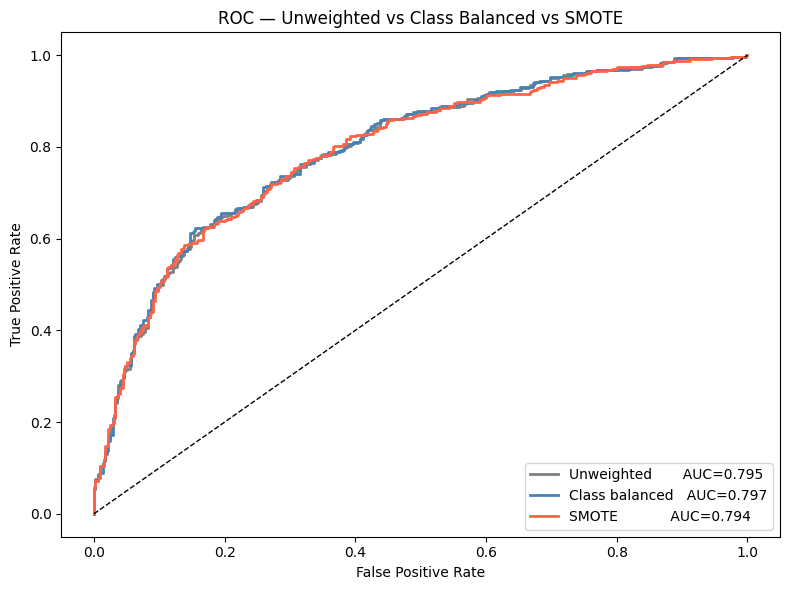

Model Comparison Summary
         Model  ROC-AUC  Rain Recall  Rain Precision
    Unweighted   0.7948       0.4754          0.8000
Class Balanced   0.7969       0.6783          0.6763
         SMOTE   0.7938       0.6812          0.6792


In [75]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, recall_score, precision_score

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_sm),
                       display_labels=['No Rain', 'Rain']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — SMOTE')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_19_smote_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC: unweighted vs balanced vs SMOTE
fig, ax = plt.subplots(figsize=(8, 6))
for y_prob, label, colour, ls in [
    (y_proba,     f'Unweighted       AUC={roc_auc_score(y_test, y_proba):.3f}',     'grey',      '-'),
    (y_proba_bal, f'Class balanced   AUC={roc_auc_score(y_test, y_proba_bal):.3f}', 'steelblue', '-'),
    (y_proba_sm,  f'SMOTE            AUC={roc_auc_score(y_test, y_proba_sm):.3f}',  'tomato',    '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=colour, linestyle=ls, label=label)
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Unweighted vs Class Balanced vs SMOTE')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/dc1_20_smote_roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary comparison table
summary = pd.DataFrame({
    'Model':          ['Unweighted', 'Class Balanced', 'SMOTE'],
    'ROC-AUC':        [
        round(roc_auc_score(y_test, y_proba),     4),
        round(roc_auc_score(y_test, y_proba_bal), 4),
        round(roc_auc_score(y_test, y_proba_sm),  4),
    ],
    'Rain Recall':    [
        round(recall_score(y_test, y_pred,     pos_label=1), 4),
        round(recall_score(y_test, y_pred_bal, pos_label=1), 4),
        round(recall_score(y_test, y_pred_sm,  pos_label=1), 4),
    ],
    'Rain Precision': [
        round(precision_score(y_test, y_pred,     pos_label=1, zero_division=0), 4),
        round(precision_score(y_test, y_pred_bal, pos_label=1, zero_division=0), 4),
        round(precision_score(y_test, y_pred_sm,  pos_label=1, zero_division=0), 4),
    ],
})
print('Model Comparison Summary')
print('=' * 50)
print(summary.to_string(index=False))


---
## ADASYN — Adaptive Synthetic Sampling

ADASYN is similar to SMOTE but focuses synthetic generation on harder-to-learn
minority instances (those surrounded by many majority-class neighbours).
Applied **after scaling, before PCA** — same pipeline order as SMOTE.

Pipeline: Scale (train only) → ADASYN (train only) → PCA (on resampled train) → LR


In [76]:
from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import numpy as np

# --- Scale (fit on original train only) ---
scaler_ad = StandardScaler()
X_train_ad_scaled = scaler_ad.fit_transform(X_train)
X_test_ad_scaled  = scaler_ad.transform(X_test)

print("Before ADASYN:")
print(f"  Rain: {y_train.sum()}  |  No Rain: {(y_train==0).sum()}")

# --- ADASYN (applied to scaled train only) ---
ad = ADASYN(random_state=42)
X_train_ad_res, y_train_ad_res = ad.fit_resample(X_train_ad_scaled, y_train)

print("After ADASYN:")
print(f"  Rain: {y_train_ad_res.sum()}  |  No Rain: {(y_train_ad_res==0).sum()}")
print(f"  Total training samples: {len(y_train_ad_res)}")

# --- PCA (fit on resampled train) ---
pca_ad = PCA()
pca_ad.fit(X_train_ad_res)
cum_ad = pca_ad.explained_variance_ratio_.cumsum()
n_95_ad = int((cum_ad < 0.95).sum()) + 1
print(f"PCA components for 95% variance: {n_95_ad}")

pca_ad_final = PCA(n_components=n_95_ad)
X_train_ad_pca = pca_ad_final.fit_transform(X_train_ad_res)
X_test_ad_pca  = pca_ad_final.transform(X_test_ad_scaled)

# --- Logistic Regression ---
lr_ad = LogisticRegression(max_iter=1000, random_state=42)
lr_ad.fit(X_train_ad_pca, y_train_ad_res)

y_pred_ad  = lr_ad.predict(X_test_ad_pca)
y_proba_ad = lr_ad.predict_proba(X_test_ad_pca)[:, 1]

print("Classification Report — ADASYN")
print("=" * 45)
print(classification_report(y_test, y_pred_ad, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_ad):.4f}")


Before ADASYN:
  Rain: 1539  |  No Rain: 2837
After ADASYN:
  Rain: 2821  |  No Rain: 2837
  Total training samples: 5658
PCA components for 95% variance: 27
Classification Report — ADASYN
              precision    recall  f1-score   support

     No Rain       0.76      0.75      0.75       457
        Rain       0.67      0.68      0.68       345

    accuracy                           0.72       802
   macro avg       0.72      0.72      0.72       802
weighted avg       0.72      0.72      0.72       802

ROC-AUC: 0.7935


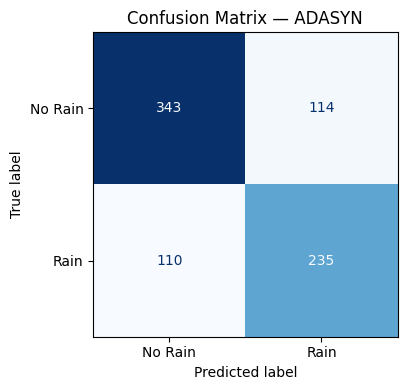

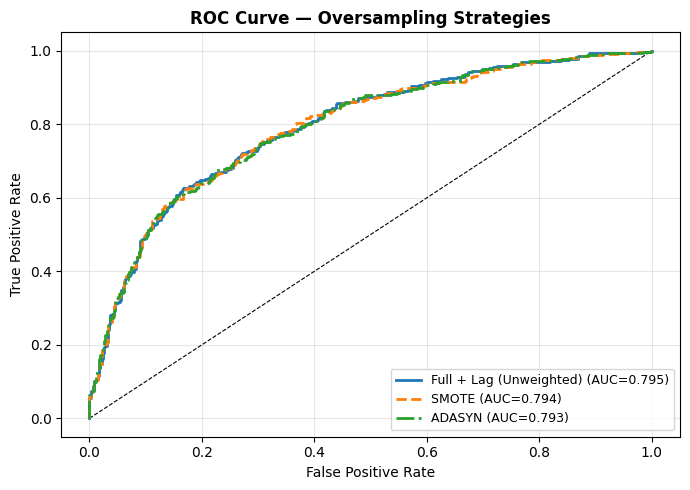

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, recall_score, precision_score

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_ad),
                       display_labels=["No Rain", "Rain"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — ADASYN")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_21_adasyn_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC — ADASYN vs SMOTE vs Unweighted
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
for label, y_true, yp, ls in [
    ("Full + Lag (Unweighted)", y_test,  y_proba,    "-"),
    ("SMOTE",                   y_test,  y_proba_sm, "--"),
    ("ADASYN",                  y_test,  y_proba_ad, "-."),
]:
    fpr, tpr, _ = roc_curve(y_true, yp)
    auc = roc_auc_score(y_true, yp)
    ax.plot(fpr, tpr, ls=ls, lw=2, label=f"{label} (AUC={auc:.3f})")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Oversampling Strategies", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_22_adasyn_roc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Overfitting Checks

**Train vs Test AUC gap** — a large gap (> 0.05) signals the model memorised training data.
Logistic Regression is low-variance by design, so gaps should be small.

**Learning curves** — plot training score and cross-validated score as the training set grows.
A healthy model has both curves converging; a persistent gap = overfitting.
We use *TimeSeriesSplit* (no shuffling) to respect the temporal order of the data.


                          Model  Train AUC  Test AUC     Gap Status
        Full + Lag (Unweighted)     0.7739    0.7948 -0.0209     OK
          Full + Lag (Balanced)     0.7745    0.7969 -0.0224     OK
No-Lag / No-Cyclic (Unweighted)     0.7434    0.7732 -0.0298     OK
  No-Lag / No-Cyclic (Balanced)     0.7438    0.7735 -0.0297     OK
     Pruned Features (Balanced)     0.7747    0.7965 -0.0218     OK
             SMOTE (Unweighted)     0.7742    0.7938 -0.0197     OK
            ADASYN (Unweighted)     0.7735    0.7935 -0.0200     OK


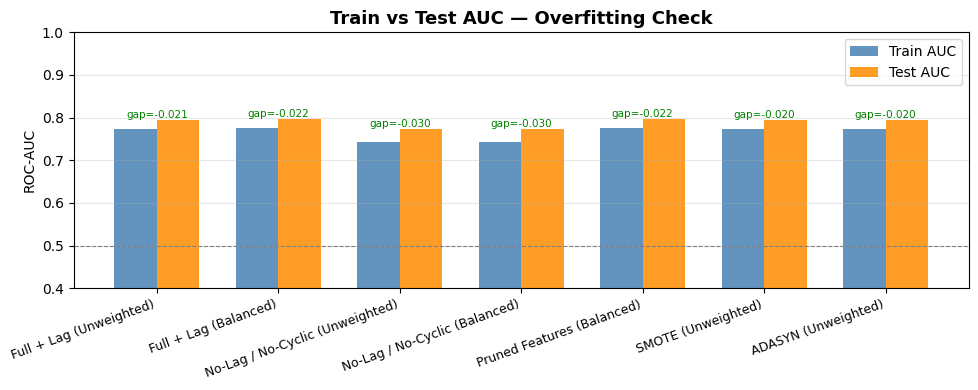

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# For SMOTE/ADASYN: evaluate train AUC on the original (non-synthetic) training data
X_train_sm_orig_pca = pca_sm_final.transform(X_train_sm_scaled)
X_train_ad_orig_pca = pca_ad_final.transform(X_train_ad_scaled)

specs = [
    ("Full + Lag (Unweighted)",        lr,      X_train_pca,         y_train,  X_test_pca,    y_test),
    ("Full + Lag (Balanced)",           lr_bal,  X_train_pca,         y_train,  X_test_pca,    y_test),
    ("No-Lag / No-Cyclic (Unweighted)", lr2,     X_train2_pca,        y_train2, X_test2_pca,   y_test2),
    ("No-Lag / No-Cyclic (Balanced)",   lr2_bal, X_train2_pca,        y_train2, X_test2_pca,   y_test2),
    ("Pruned Features (Balanced)",      lr_pr,   X_train_pr_pca,      y_train,  X_test_pr_pca, y_test),
    ("SMOTE (Unweighted)",              lr_sm,   X_train_sm_orig_pca, y_train,  X_test_sm_pca, y_test),
    ("ADASYN (Unweighted)",             lr_ad,   X_train_ad_orig_pca, y_train,  X_test_ad_pca, y_test),
]

rows = []
for name, model, X_tr, y_tr, X_te, y_te in specs:
    tr  = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    te  = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    gap = tr - te
    rows.append({"Model": name, "Train AUC": tr, "Test AUC": te,
                 "Gap": gap, "Status": "OVERFIT" if gap > 0.05 else "OK"})

gap_df = pd.DataFrame(rows)
print(gap_df.to_string(index=False, float_format="{:.4f}".format))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(gap_df))
ax.bar(x, gap_df["Train AUC"], 0.35, label="Train AUC",
       color="steelblue", alpha=0.85)
ax.bar([i + 0.35 for i in x], gap_df["Test AUC"], 0.35, label="Test AUC",
       color="darkorange", alpha=0.85)
ax.axhline(0.5, color="grey", lw=0.8, ls="--")
ax.set_xticks([i + 0.175 for i in x])
ax.set_xticklabels(gap_df["Model"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.4, 1.0)
ax.set_title("Train vs Test AUC — Overfitting Check", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

# Annotate gap on each pair
for i, row in gap_df.iterrows():
    ax.text(i + 0.175, max(row["Train AUC"], row["Test AUC"]) + 0.005,
            f"gap={row['Gap']:.3f}", ha="center", fontsize=7.5,
            color="red" if row["Status"] == "OVERFIT" else "green")

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_24_train_test_auc_gap.png", dpi=300, bbox_inches="tight")
plt.show()


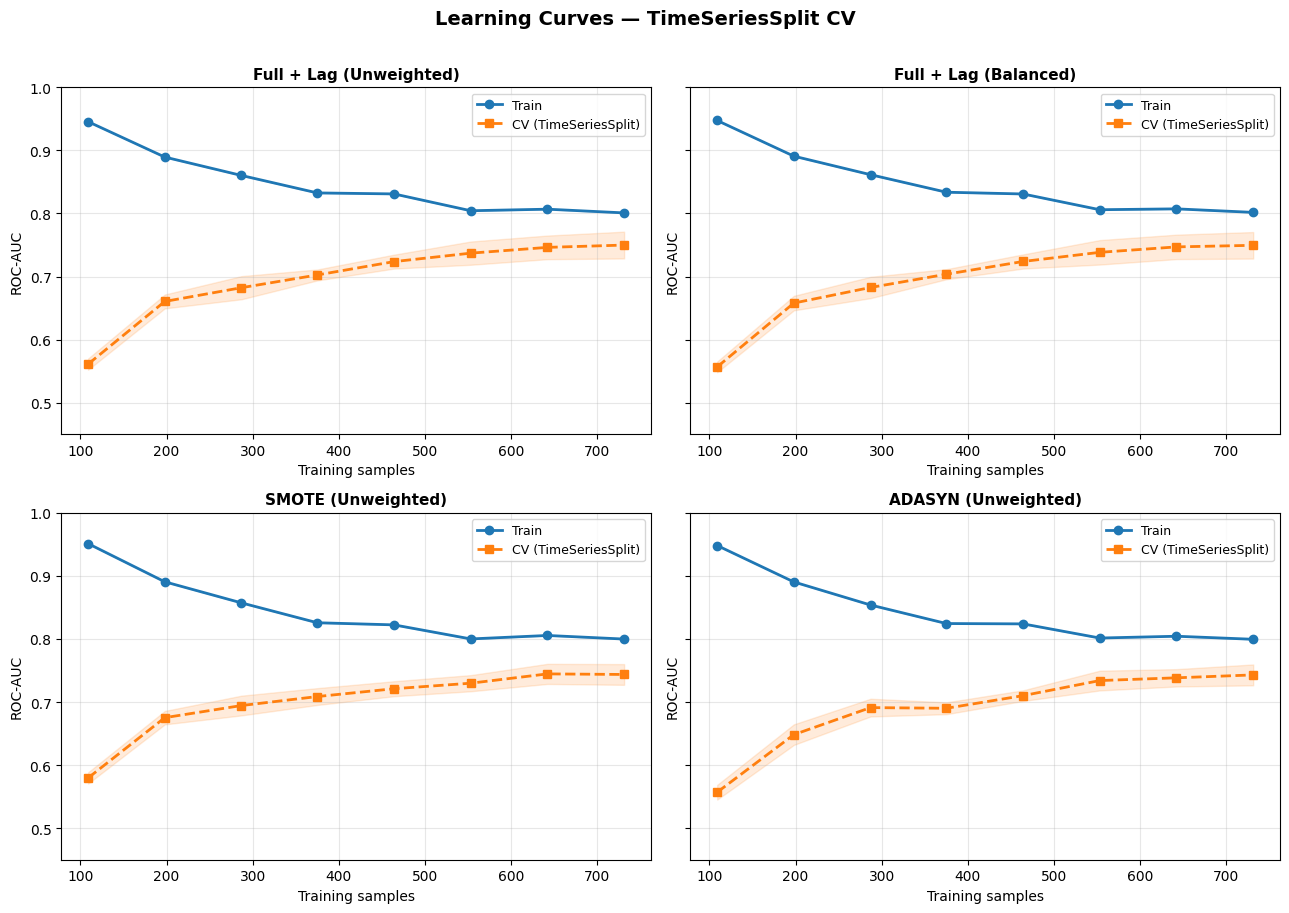

Interpretation:
  • Both curves close together → low overfitting
  • Train >> CV → overfitting
  • Both curves low and flat → underfitting


In [79]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

tscv = TimeSeriesSplit(n_splits=5)
train_sizes = np.linspace(0.15, 1.0, 8)

pipe_configs = [
    ("Full + Lag (Unweighted)",
     Pipeline([("sc", StandardScaler()),
               ("pca", PCA(n_components=0.95)),
               ("lr", LogisticRegression(max_iter=1000, random_state=42))]),
     X_train, y_train),
    ("Full + Lag (Balanced)",
     Pipeline([("sc", StandardScaler()),
               ("pca", PCA(n_components=0.95)),
               ("lr", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))]),
     X_train, y_train),
    ("SMOTE (Unweighted)",
     ImbPipeline([("sc", StandardScaler()),
                  ("sm", SMOTE(random_state=42)),
                  ("pca", PCA(n_components=0.95)),
                  ("lr", LogisticRegression(max_iter=1000, random_state=42))]),
     X_train, y_train),
    ("ADASYN (Unweighted)",
     ImbPipeline([("sc", StandardScaler()),
                  ("ad", ADASYN(random_state=42)),
                  ("pca", PCA(n_components=0.95)),
                  ("lr", LogisticRegression(max_iter=1000, random_state=42))]),
     X_train, y_train),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
palette_tr = "#1f77b4"
palette_cv = "#ff7f0e"

for ax, (label, pipe, X, y) in zip(axes.flat, pipe_configs):
    sizes, tr_scores, cv_scores = learning_curve(
        pipe, X, y,
        train_sizes=train_sizes,
        cv=tscv,
        scoring="roc_auc",
        n_jobs=-1,
    )
    tr_mean = tr_scores.mean(axis=1)
    tr_std  = tr_scores.std(axis=1)
    cv_mean = cv_scores.mean(axis=1)
    cv_std  = cv_scores.std(axis=1)

    ax.plot(sizes, tr_mean, "o-", color=palette_tr, lw=2, label="Train")
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color=palette_tr)
    ax.plot(sizes, cv_mean, "s--", color=palette_cv, lw=2, label="CV (TimeSeriesSplit)")
    ax.fill_between(sizes, cv_mean - cv_std, cv_mean + cv_std,
                    alpha=0.15, color=palette_cv)
    ax.set_title(label.replace(" ", " "), fontsize=11, fontweight="bold")
    ax.set_xlabel("Training samples")
    ax.set_ylabel("ROC-AUC")
    ax.set_ylim(0.45, 1.0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Learning Curves — TimeSeriesSplit CV",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_25_learning_curves.png", dpi=300, bbox_inches="tight")
plt.show()

print("Interpretation:")
print("  • Both curves close together → low overfitting")
print("  • Train >> CV → overfitting")
print("  • Both curves low and flat → underfitting")


                                                          Model  TN  FP  FN  TP   Acc  Rain Recall  Rain Precision
                 F u l l   +   L a g   ( U n w e i g h t e d )  416  41 181 164 0.723        0.475           0.800
                     F u l l   +   L a g   ( B a l a n c e d )  345 112 111 234 0.722        0.678           0.676
 N o - L a g   /   N o - C y c l i c   ( U n w e i g h t e d )  429  28 209 136 0.704        0.394           0.829
     N o - L a g   /   N o - C y c l i c   ( B a l a n c e d )  362  95 120 225 0.732        0.652           0.703
           P r u n e d   F e a t u r e s   ( B a l a n c e d )  343 114 111 234 0.719        0.678           0.672
                           S M O T E   ( U n w e i g h t e d )  346 111 110 235 0.724        0.681           0.679
                         A D A S Y N   ( U n w e i g h t e d )  343 114 110 235 0.721        0.681           0.673


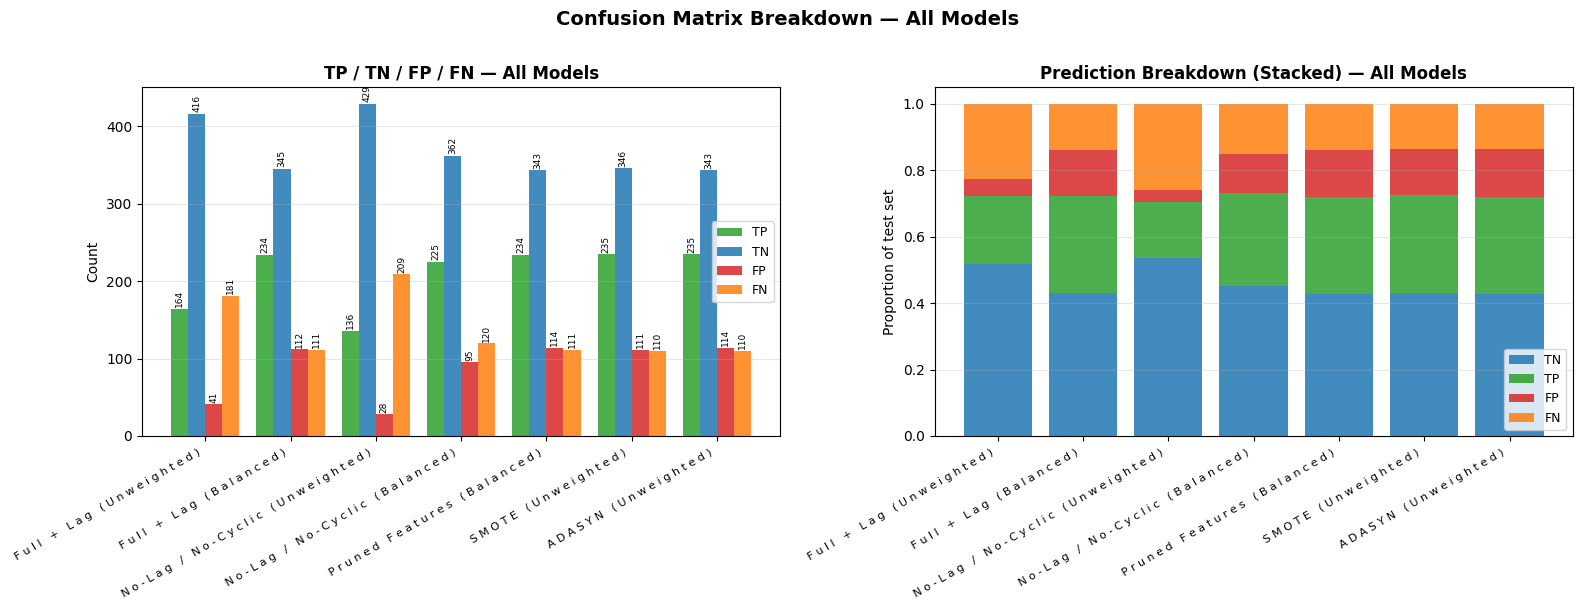

In [80]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

cm_specs = [
    ("Full + Lag (Unweighted)",        y_test,  y_pred),
    ("Full + Lag (Balanced)",          y_test,  y_pred_bal),
    ("No-Lag / No-Cyclic (Unweighted)", y_test2, y_pred2),
    ("No-Lag / No-Cyclic (Balanced)",   y_test2, y_pred2_bal),
    ("Pruned Features (Balanced)",      y_test,  y_pred_pr),
    ("SMOTE (Unweighted)",             y_test,  y_pred_sm),
    ("ADASYN (Unweighted)",            y_test,  y_pred_ad),
]

rows = []
for label, y_true, y_pred_m in cm_specs:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_m).ravel()
    total = tn + fp + fn + tp
    rows.append({
        "Model":   label.replace("", " "),
        "TN":      tn, "FP": fp, "FN": fn, "TP": tp,
        "Total":   total,
        "Acc":     (tp + tn) / total,
        "Rain Recall":    tp / (tp + fn),
        "Rain Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
    })

cm_df = pd.DataFrame(rows)
print(cm_df[["Model", "TN", "FP", "FN", "TP", "Acc", "Rain Recall", "Rain Precision"]]
      .to_string(index=False, float_format="{:.3f}".format))

# ── Grouped bar chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels  = [r["Model"] for r in rows]
x       = np.arange(len(labels))
bar_w   = 0.2

# Panel 1: Raw counts (TP, TN, FP, FN)
ax = axes[0]
offsets = [-1.5, -0.5, 0.5, 1.5]
colors  = ["#2ca02c", "#1f77b4", "#d62728", "#ff7f0e"]
keys    = ["TP", "TN", "FP", "FN"]
for off, color, key in zip(offsets, colors, keys):
    vals = cm_df[key].values
    bars = ax.bar(x + off * bar_w, vals, bar_w, label=key, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(v), ha="center", va="bottom", fontsize=6.5, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Count")
ax.set_title("TP / TN / FP / FN — All Models", fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Panel 2: Stacked proportions
ax2 = axes[1]
totals = cm_df["Total"].values
tp_r = cm_df["TP"].values / totals
tn_r = cm_df["TN"].values / totals
fp_r = cm_df["FP"].values / totals
fn_r = cm_df["FN"].values / totals
ax2.bar(x, tn_r, label="TN", color="#1f77b4", alpha=0.85)
ax2.bar(x, tp_r, bottom=tn_r, label="TP", color="#2ca02c", alpha=0.85)
ax2.bar(x, fp_r, bottom=tn_r + tp_r, label="FP", color="#d62728", alpha=0.85)
ax2.bar(x, fn_r, bottom=tn_r + tp_r + fp_r, label="FN", color="#ff7f0e", alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("Proportion of test set")
ax2.set_title("Prediction Breakdown (Stacked) — All Models", fontweight="bold", fontsize=12)
ax2.legend(fontsize=9, loc="lower right")
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Confusion Matrix Breakdown — All Models",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_26_confusion_breakdown_all_models.png",
            dpi=300, bbox_inches="tight")
plt.show()


---
## Decision Threshold Tuning

All models above use the default 0.5 probability threshold. Lowering it means
predicting Rain whenever P(Rain) > threshold — catching more rain days at the
cost of more false alarms.

**F2-score** weights recall twice as heavily as precision, making it the right
metric when missing rain (false negative) is worse than a false alarm (false positive).
We scan thresholds 0.05–0.70 and pick the one that maximises F2 for each model.


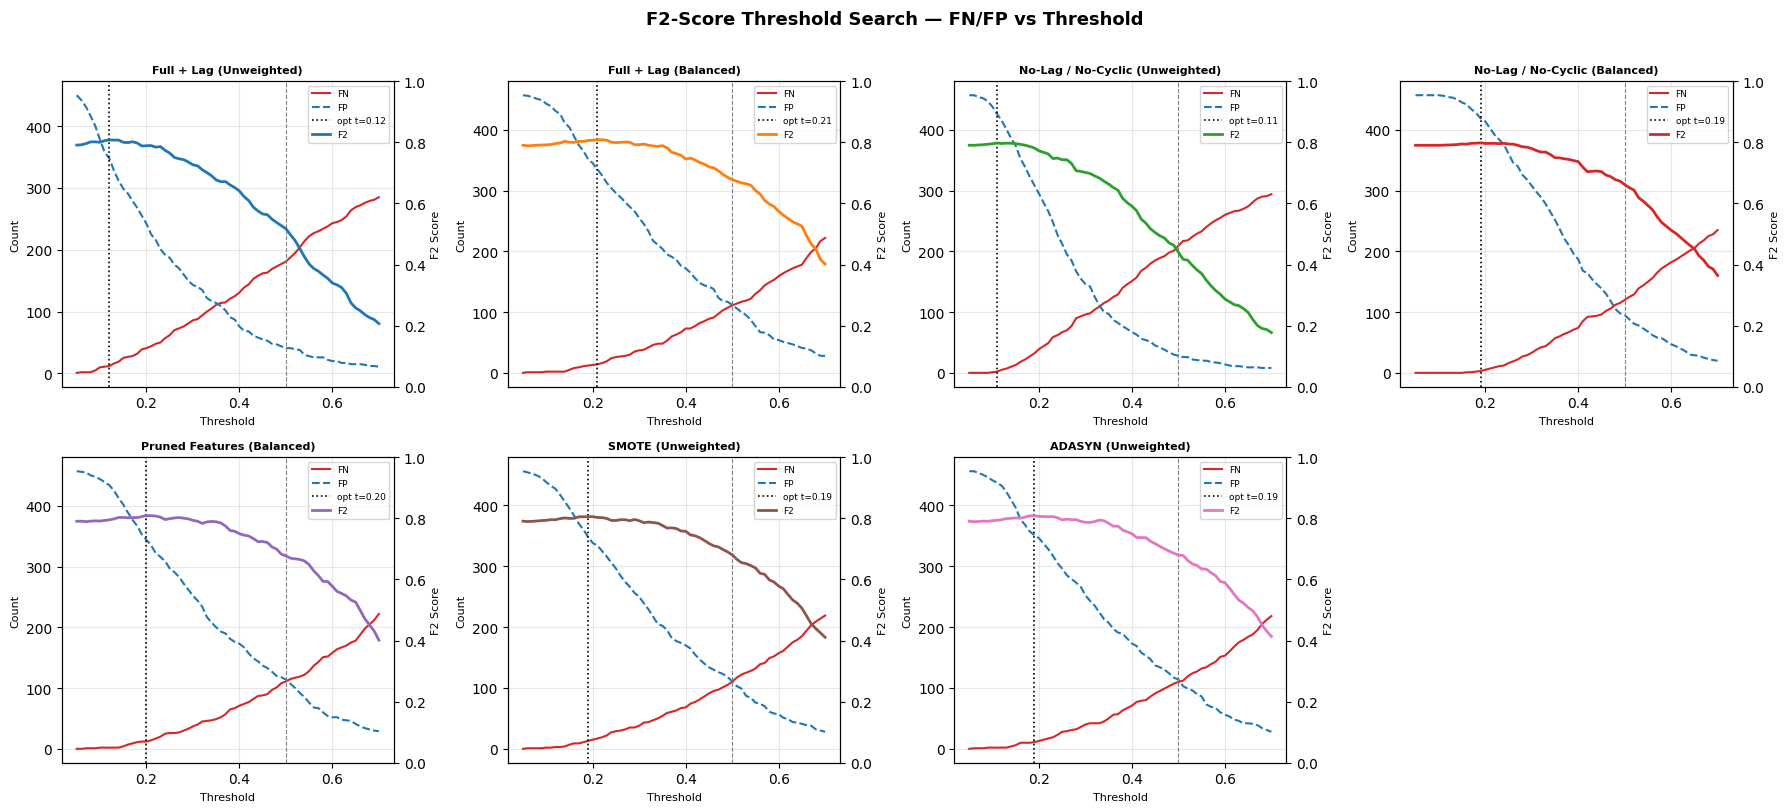

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import fbeta_score, confusion_matrix

thresholds = np.arange(0.05, 0.71, 0.01)

model_probas = [
    ("Full + Lag (Unweighted)",        y_test,  y_proba),
    ("Full + Lag (Balanced)",           y_test,  y_proba_bal),
    ("No-Lag / No-Cyclic (Unweighted)", y_test2, y_proba2),
    ("No-Lag / No-Cyclic (Balanced)",   y_test2, y_proba2_bal),
    ("Pruned Features (Balanced)",       y_test,  y_proba_pr),
    ("SMOTE (Unweighted)",               y_test,  y_proba_sm),
    ("ADASYN (Unweighted)",              y_test,  y_proba_ad),
]

palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
axes = axes.flat
summary_rows = []

for ax, (label, y_true, y_prob), color in zip(axes, model_probas, palette):
    f2s, fns, fps = [], [], []
    for t in thresholds:
        y_hat = (y_prob >= t).astype(int)
        f2s.append(fbeta_score(y_true, y_hat, beta=2, zero_division=0))
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
        fns.append(fn); fps.append(fp)

    best_t   = thresholds[np.argmax(f2s)]
    best_f2  = max(f2s)
    y_best   = (y_prob >= best_t).astype(int)
    tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_true, y_best).ravel()
    tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_true, (y_prob >= 0.5).astype(int)).ravel()

    ax2 = ax.twinx()
    ax.plot(thresholds, fns, color="#d62728", lw=1.5, label="FN")
    ax.plot(thresholds, fps, color="#1f77b4", lw=1.5, ls="--", label="FP")
    ax2.plot(thresholds, f2s, color=color, lw=2, label="F2")
    ax.axvline(best_t, color="black", lw=1.2, ls=":", label=f"opt t={best_t:.2f}")
    ax.axvline(0.5,    color="grey",  lw=0.8, ls="--")
    ax.set_title(label, fontsize=8, fontweight="bold")
    ax.set_xlabel("Threshold", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax2.set_ylabel("F2 Score", fontsize=8)
    ax2.set_ylim(0, 1)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=6.5, loc="upper right")
    ax.grid(alpha=0.3)

    summary_rows.append({
        "Model":             label,
        "Default FN (t=0.5)": fn_d,
        "Optimal Threshold":  round(best_t, 2),
        "Optimal FN":        fn_b,
        "FN Reduction":      fn_d - fn_b,
        "Optimal FP":        fp_b,
        "Default FP (t=0.5)": fp_d,
        "Best F2":           round(best_f2, 4),
    })

# Hide last (unused) subplot
axes[-1].set_visible(False)

plt.suptitle("F2-Score Threshold Search — FN/FP vs Threshold",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_27_threshold_sweep.png", dpi=300, bbox_inches="tight")
plt.show()


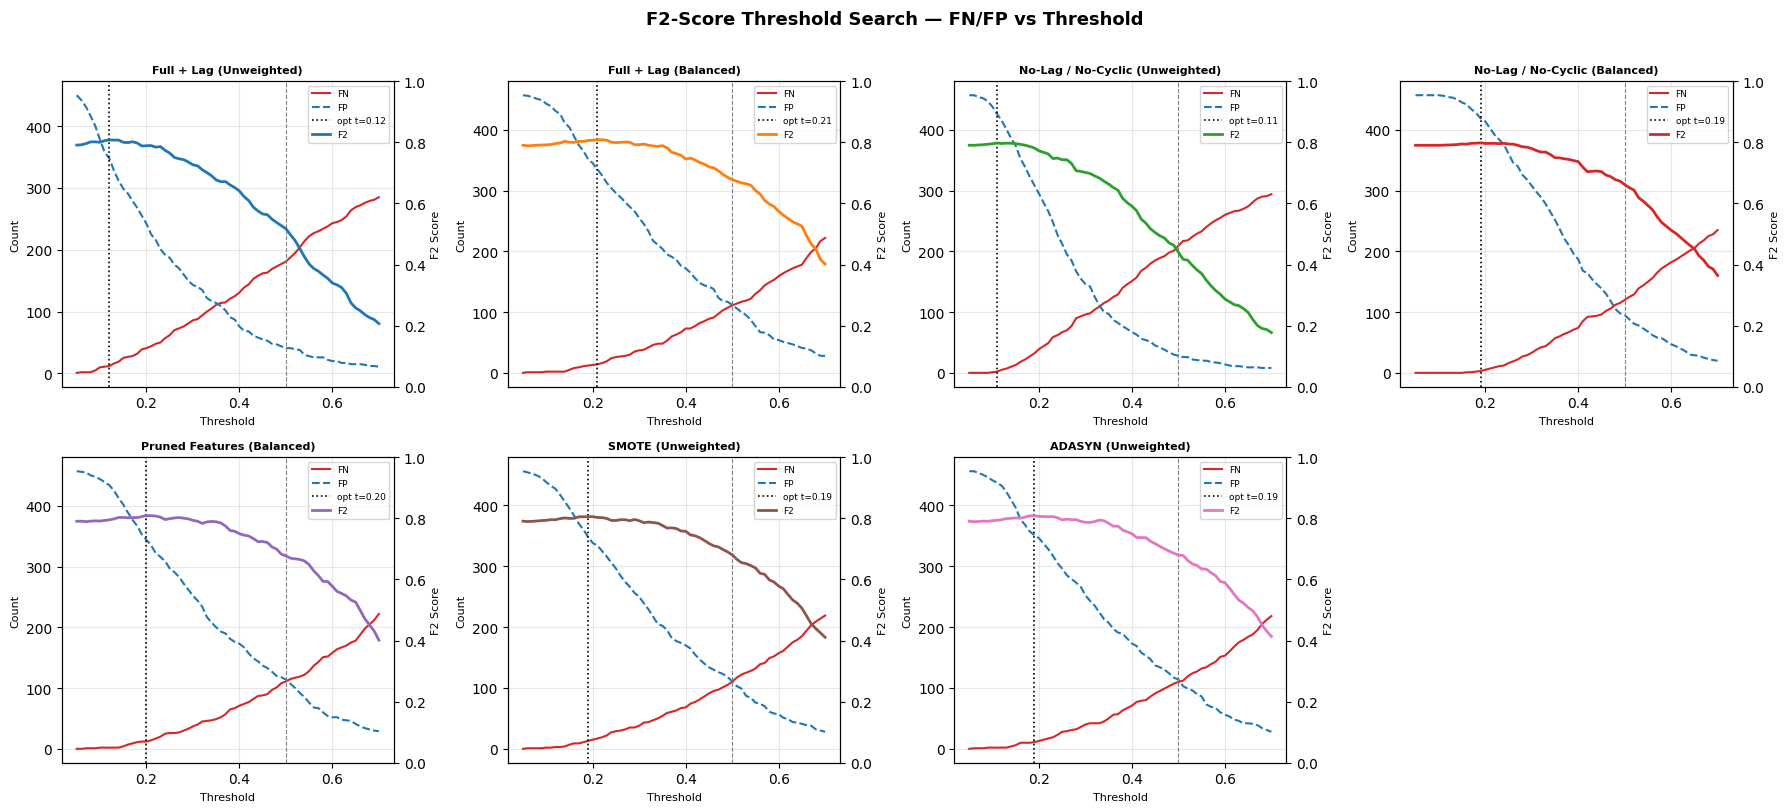

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import fbeta_score, confusion_matrix

thresholds = np.arange(0.05, 0.71, 0.01)

model_probas = [
    ("Full + Lag (Unweighted)",        y_test,  y_proba),
    ("Full + Lag (Balanced)",           y_test,  y_proba_bal),
    ("No-Lag / No-Cyclic (Unweighted)", y_test2, y_proba2),
    ("No-Lag / No-Cyclic (Balanced)",   y_test2, y_proba2_bal),
    ("Pruned Features (Balanced)",       y_test,  y_proba_pr),
    ("SMOTE (Unweighted)",               y_test,  y_proba_sm),
    ("ADASYN (Unweighted)",              y_test,  y_proba_ad),
]

palette = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
axes = axes.flat
summary_rows = []

for ax, (label, y_true, y_prob), color in zip(axes, model_probas, palette):
    f2s, fns, fps = [], [], []
    for t in thresholds:
        y_hat = (y_prob >= t).astype(int)
        f2s.append(fbeta_score(y_true, y_hat, beta=2, zero_division=0))
        tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
        fns.append(fn); fps.append(fp)

    best_t   = thresholds[np.argmax(f2s)]
    best_f2  = max(f2s)
    y_best   = (y_prob >= best_t).astype(int)
    tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_true, y_best).ravel()
    tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_true, (y_prob >= 0.5).astype(int)).ravel()

    ax2 = ax.twinx()
    ax.plot(thresholds, fns, color="#d62728", lw=1.5, label="FN")
    ax.plot(thresholds, fps, color="#1f77b4", lw=1.5, ls="--", label="FP")
    ax2.plot(thresholds, f2s, color=color, lw=2, label="F2")
    ax.axvline(best_t, color="black", lw=1.2, ls=":", label=f"opt t={best_t:.2f}")
    ax.axvline(0.5,    color="grey",  lw=0.8, ls="--")
    ax.set_title(label, fontsize=8, fontweight="bold")
    ax.set_xlabel("Threshold", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax2.set_ylabel("F2 Score", fontsize=8)
    ax2.set_ylim(0, 1)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=6.5, loc="upper right")
    ax.grid(alpha=0.3)

    summary_rows.append({
        "Model":             label,
        "Default FN (t=0.5)": fn_d,
        "Optimal Threshold":  round(best_t, 2),
        "Optimal FN":        fn_b,
        "FN Reduction":      fn_d - fn_b,
        "Optimal FP":        fp_b,
        "Default FP (t=0.5)": fp_d,
        "Best F2":           round(best_f2, 4),
    })

# Hide last (unused) subplot
axes[-1].set_visible(False)

plt.suptitle("F2-Score Threshold Search — FN/FP vs Threshold",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_27_threshold_sweep.png", dpi=300, bbox_inches="tight")
plt.show()


THRESHOLD TUNING SUMMARY — Default (0.5) vs F2-Optimal
                          Model  Default FN (t=0.5)  Optimal Threshold  Optimal FN  FN Reduction  Optimal FP  Default FP (t=0.5)  Best F2
        Full + Lag (Unweighted)                 181               0.12          12           169         348                  41   0.8079
          Full + Lag (Balanced)                 111               0.21          14            97         335                 112   0.8089
No-Lag / No-Cyclic (Unweighted)                 209               0.11           2           207         426                  28   0.7980
  No-Lag / No-Cyclic (Balanced)                 120               0.19           3           117         419                  95   0.7987
     Pruned Features (Balanced)                 111               0.20          12            99         344                 114   0.8094
             SMOTE (Unweighted)                 110               0.19          13            97         348         

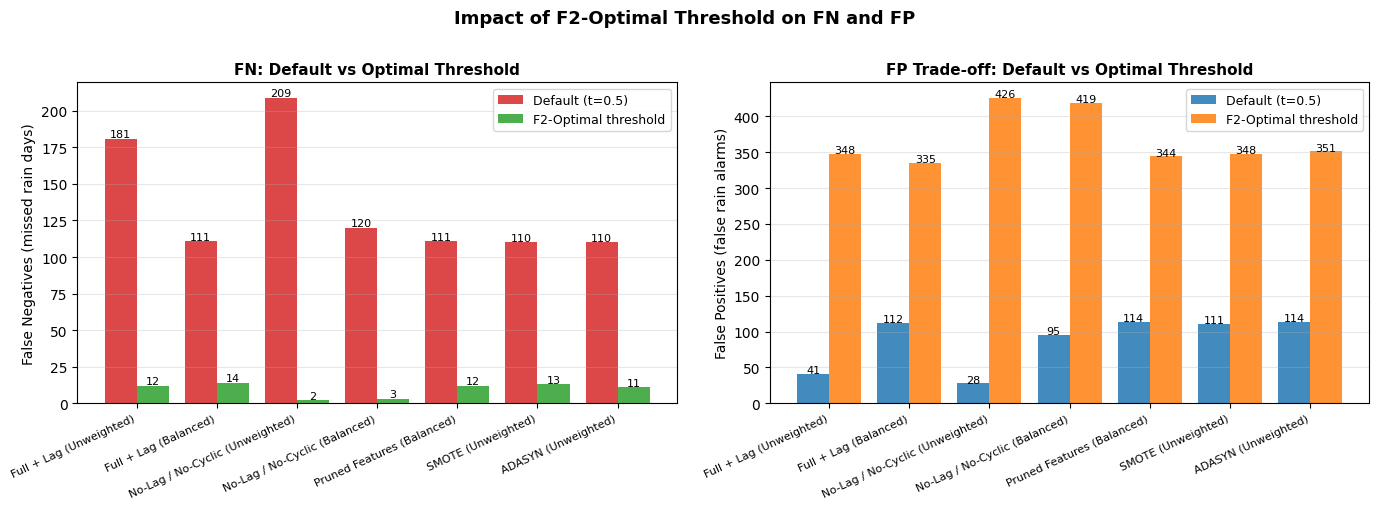

Optimal thresholds range: 0.11 – 0.21
Avg FN reduction: 126.4 fewer missed rain days per model


In [83]:
summary_df = pd.DataFrame(summary_rows)
print("=" * 90)
print("THRESHOLD TUNING SUMMARY — Default (0.5) vs F2-Optimal")
print("=" * 90)
print(summary_df.to_string(index=False))

# Side-by-side FN comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: FN before/after
ax = axes[0]
x = np.arange(len(summary_df))
ax.bar(x - 0.2, summary_df["Default FN (t=0.5)"], 0.4,
       label="Default (t=0.5)", color="#d62728", alpha=0.85)
ax.bar(x + 0.2, summary_df["Optimal FN"], 0.4,
       label="F2-Optimal threshold", color="#2ca02c", alpha=0.85)
for i, row in summary_df.iterrows():
    ax.text(i - 0.2, row["Default FN (t=0.5)"] + 1, str(int(row["Default FN (t=0.5)"])),
            ha="center", fontsize=8)
    ax.text(i + 0.2, row["Optimal FN"] + 1, str(int(row["Optimal FN"])),
            ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Model"], rotation=25, ha="right", fontsize=8)
ax.set_ylabel("False Negatives (missed rain days)")
ax.set_title("FN: Default vs Optimal Threshold", fontweight="bold", fontsize=11)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# Panel 2: FP before/after (cost of lowering threshold)
ax2 = axes[1]
ax2.bar(x - 0.2, summary_df["Default FP (t=0.5)"], 0.4,
        label="Default (t=0.5)", color="#1f77b4", alpha=0.85)
ax2.bar(x + 0.2, summary_df["Optimal FP"], 0.4,
        label="F2-Optimal threshold", color="#ff7f0e", alpha=0.85)
for i, row in summary_df.iterrows():
    ax2.text(i - 0.2, row["Default FP (t=0.5)"] + 1, str(int(row["Default FP (t=0.5)"])),
             ha="center", fontsize=8)
    ax2.text(i + 0.2, row["Optimal FP"] + 1, str(int(row["Optimal FP"])),
             ha="center", fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(summary_df["Model"], rotation=25, ha="right", fontsize=8)
ax2.set_ylabel("False Positives (false rain alarms)")
ax2.set_title("FP Trade-off: Default vs Optimal Threshold", fontweight="bold", fontsize=11)
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Impact of F2-Optimal Threshold on FN and FP",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_28_threshold_fn_fp_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Optimal thresholds range: {summary_df['Optimal Threshold'].min()} – {summary_df['Optimal Threshold'].max()}")
print(f"Avg FN reduction: {summary_df['FN Reduction'].mean():.1f} fewer missed rain days per model")


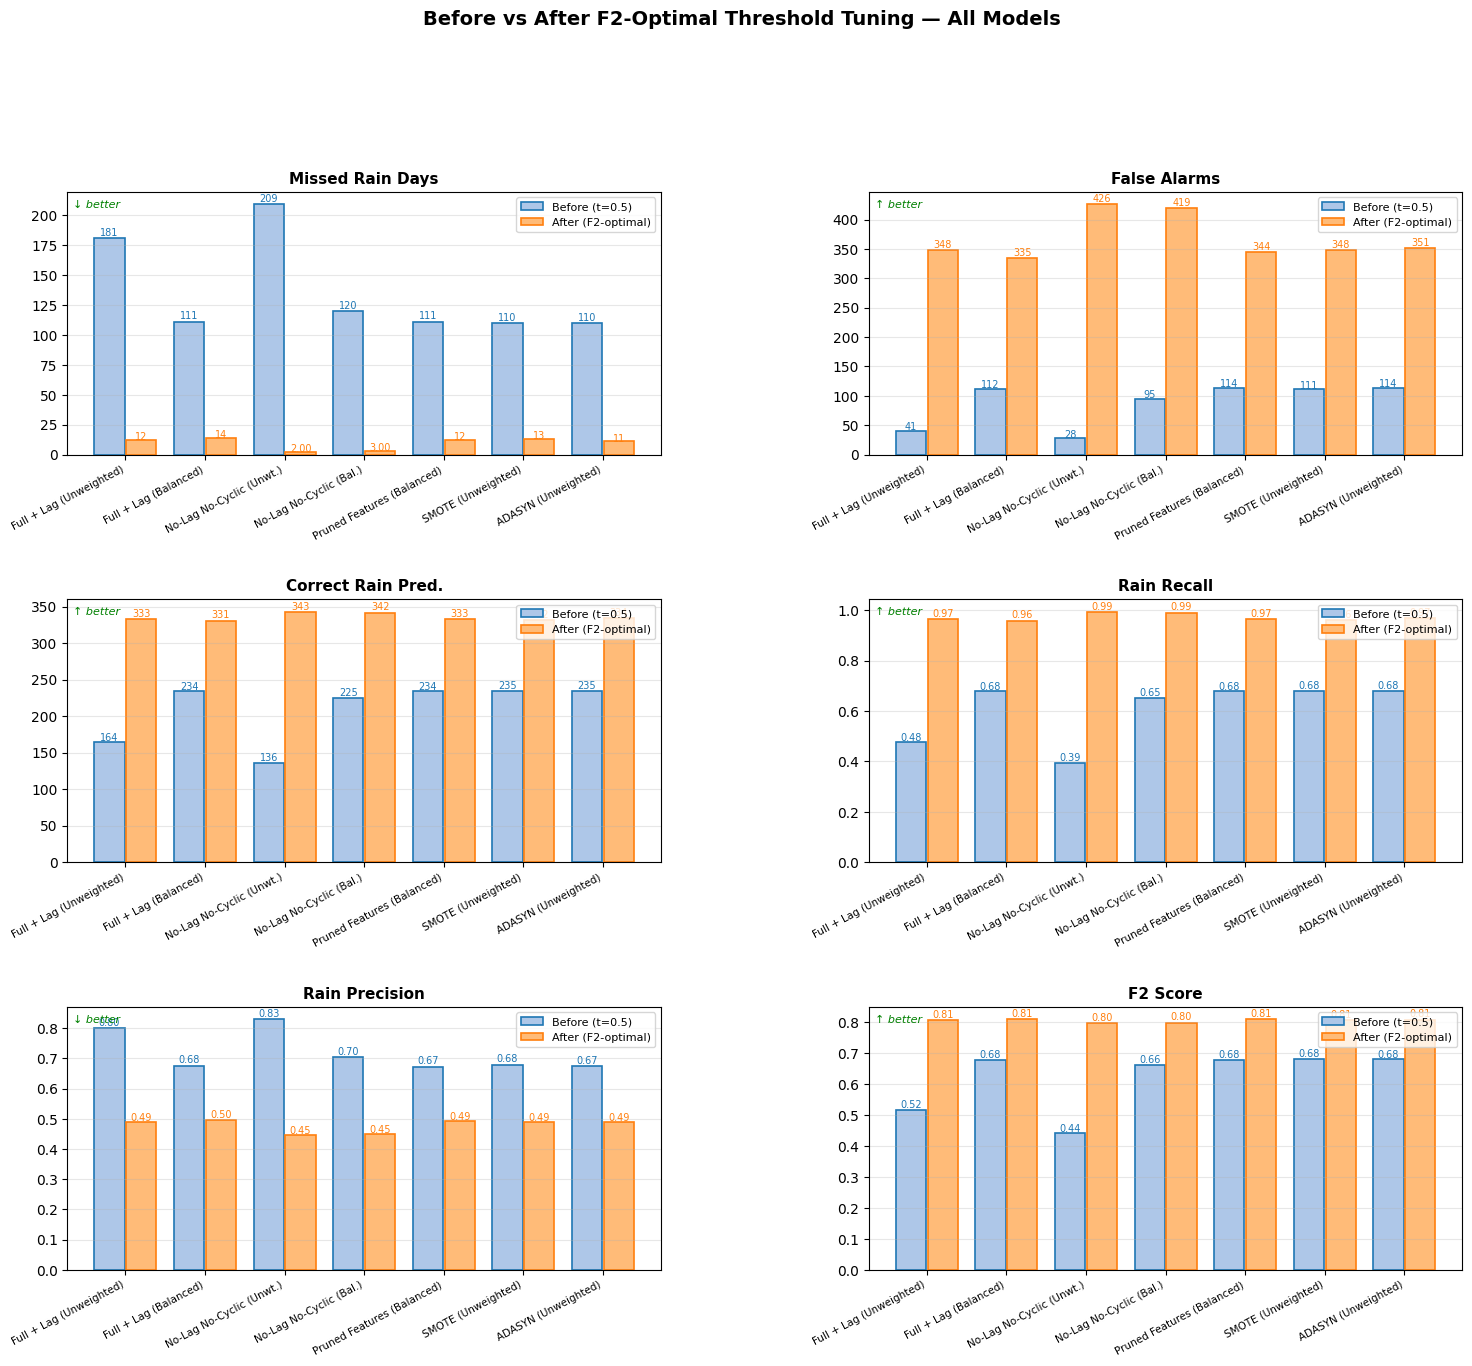

BEFORE vs AFTER THRESHOLD TUNING
                     Model  Opt t  FN (before)  FN (after)  FP (before)  FP (after)  Recall (before)  Recall (after)  F2 (before)  F2 (after)
   Full + Lag (Unweighted)  0.120          181          12           41         348            0.475           0.965        0.517       0.808
     Full + Lag (Balanced)  0.210          111          14          112         335            0.678           0.959        0.678       0.809
  No-Lag No-Cyclic (Unwt.)  0.110          209           2           28         426            0.394           0.994        0.440       0.798
   No-Lag No-Cyclic (Bal.)  0.190          120           3           95         419            0.652           0.991        0.662       0.799
Pruned Features (Balanced)  0.200          111          12          114         344            0.678           0.965        0.677       0.809
        SMOTE (Unweighted)  0.190          110          13          111         348            0.681           0.96

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, fbeta_score, f1_score,
    recall_score, precision_score, roc_auc_score
)

model_probas = [
    ("Full + Lag (Unweighted)",        y_test,  y_proba),
    ("Full + Lag (Balanced)",          y_test,  y_proba_bal),
    ("No-Lag No-Cyclic (Unwt.)",      y_test2, y_proba2),
    ("No-Lag No-Cyclic (Bal.)",       y_test2, y_proba2_bal),
    ("Pruned Features (Balanced)",     y_test,  y_proba_pr),
    ("SMOTE (Unweighted)",            y_test,  y_proba_sm),
    ("ADASYN (Unweighted)",           y_test,  y_proba_ad),
]
thresholds = np.arange(0.05, 0.71, 0.01)

def metrics_at(y_true, y_prob, t):
    y_hat = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    rec  = recall_score(y_true, y_hat, zero_division=0)
    pre  = precision_score(y_true, y_hat, zero_division=0)
    f1   = f1_score(y_true, y_hat, zero_division=0)
    f2   = fbeta_score(y_true, y_hat, beta=2, zero_division=0)
    return dict(TN=tn, FP=fp, FN=fn, TP=tp,
                Recall=rec, Precision=pre, F1=f1, F2=f2)

rows = []
for label, y_true, y_prob in model_probas:
    f2s = [fbeta_score(y_true, (y_prob >= t).astype(int), beta=2, zero_division=0)
           for t in thresholds]
    opt_t = thresholds[np.argmax(f2s)]
    before = metrics_at(y_true, y_prob, 0.5)
    after  = metrics_at(y_true, y_prob, opt_t)
    rows.append({"Model": label,
                 "Opt t": round(opt_t, 2), **{
                     f"{k} (before)": before[k] for k in before},
                 **{f"{k} (after)": after[k]  for k in after}})

df = pd.DataFrame(rows)

# ── Figure layout ────────────────────────────────────────────────────────────
short_labels = [r["Model"] for r in rows]
x = np.arange(len(short_labels))
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
           "#9467bd", "#8c564b", "#e377c2"]

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, hspace=0.55, wspace=0.35)

metric_panels = [
    ("FN",        "Missed Rain Days",   True,  fig.add_subplot(gs[0, 0])),
    ("FP",        "False Alarms",        False, fig.add_subplot(gs[0, 1])),
    ("TP",        "Correct Rain Pred.", False, fig.add_subplot(gs[1, 0])),
    ("Recall",    "Rain Recall",         False, fig.add_subplot(gs[1, 1])),
    ("Precision", "Rain Precision",      True,  fig.add_subplot(gs[2, 0])),
    ("F2",        "F2 Score",            False, fig.add_subplot(gs[2, 1])),
]

for metric, title, lower_is_better, ax in metric_panels:
    b_vals = df[f"{metric} (before)"].values.astype(float)
    a_vals = df[f"{metric} (after)"].values.astype(float)
    bars_b = ax.bar(x - 0.2, b_vals, 0.38,
                    label="Before (t=0.5)", color="#aec7e8", edgecolor="#1f77b4", lw=1.2)
    bars_a = ax.bar(x + 0.2, a_vals, 0.38,
                    label="After (F2-optimal)", color="#ffbb78", edgecolor="#ff7f0e", lw=1.2)
    for bar, v in zip(bars_b, b_vals):
        fmt = f"{v:.2f}" if isinstance(v, float) and v < 10 else str(int(v))
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(b_vals)*0.01,
                fmt, ha="center", fontsize=7, color="#1f77b4")
    for bar, v in zip(bars_a, a_vals):
        fmt = f"{v:.2f}" if isinstance(v, float) and v < 10 else str(int(v))
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(a_vals)*0.01,
                fmt, ha="center", fontsize=7, color="#ff7f0e")
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=28, ha="right", fontsize=7.5)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    # Arrow annotations showing direction of change
    arrow = "↓ better" if lower_is_better else "↑ better"
    ax.text(0.01, 0.97, arrow, transform=ax.transAxes,
            fontsize=8, va="top", color="green", style="italic")

plt.suptitle("Before vs After F2-Optimal Threshold Tuning — All Models",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{PLOTS_DIR}/dc1_29_before_after_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Clean summary table ───────────────────────────────────────────────────────
print("" + "="*95)
print("BEFORE vs AFTER THRESHOLD TUNING")
print("="*95)
cols = ["Model", "Opt t",
        "FN (before)", "FN (after)",
        "FP (before)", "FP (after)",
        "Recall (before)", "Recall (after)",
        "F2 (before)",    "F2 (after)"]
print(df[cols].to_string(index=False, float_format="{:.3f}".format))


/var/folders/7c/mz5k512d14v8zwhmbghmxxl80000gn/T/ipykernel_21040/2193322999.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


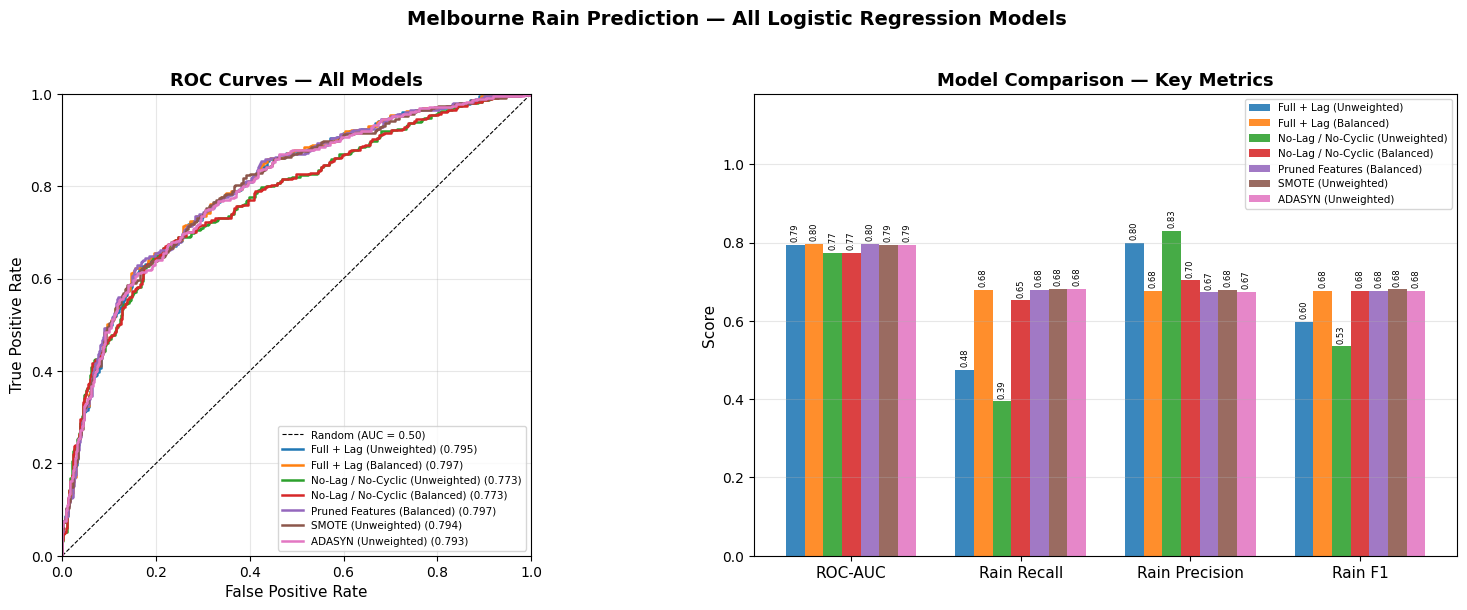

ALL MODEL SUMMARY
                          Model  ROC-AUC  Rain Recall  Rain Precision  Rain F1
        Full + Lag (Unweighted)   0.7948       0.4754          0.8000   0.5964
          Full + Lag (Balanced)   0.7969       0.6783          0.6763   0.6773
No-Lag / No-Cyclic (Unweighted)   0.7732       0.3942          0.8293   0.5344
  No-Lag / No-Cyclic (Balanced)   0.7735       0.6522          0.7031   0.6767
     Pruned Features (Balanced)   0.7965       0.6783          0.6724   0.6753
             SMOTE (Unweighted)   0.7938       0.6812          0.6792   0.6802
            ADASYN (Unweighted)   0.7935       0.6812          0.6734   0.6772


In [85]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score, recall_score, precision_score

# ── Model registry ──────────────────────────────────────────────────────────────
models = [
    {"label": "Full + Lag (Unweighted)",       "y_true": y_test,  "y_proba": y_proba,     "y_pred": y_pred},
    {"label": "Full + Lag (Balanced)",          "y_true": y_test,  "y_proba": y_proba_bal,  "y_pred": y_pred_bal},
    {"label": "No-Lag / No-Cyclic (Unweighted)","y_true": y_test2, "y_proba": y_proba2,    "y_pred": y_pred2},
    {"label": "No-Lag / No-Cyclic (Balanced)",  "y_true": y_test2, "y_proba": y_proba2_bal,"y_pred": y_pred2_bal},
    {"label": "Pruned Features (Balanced)",     "y_true": y_test,  "y_proba": y_proba_pr,   "y_pred": y_pred_pr},
    {"label": "SMOTE (Unweighted)",             "y_true": y_test,  "y_proba": y_proba_sm,   "y_pred": y_pred_sm},
    {"label": "ADASYN (Unweighted)",            "y_true": y_test,  "y_proba": y_proba_ad,   "y_pred": y_pred_ad},
]

palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

# ── Compute metrics ─────────────────────────────────────────────────────────────
metrics = []
for m in models:
    auc = roc_auc_score(m["y_true"], m["y_proba"])
    rec = recall_score(m["y_true"], m["y_pred"])
    pre = precision_score(m["y_true"], m["y_pred"])
    f1  = 2 * pre * rec / (pre + rec) if (pre + rec) > 0 else 0
    metrics.append({"Model": m["label"], "ROC-AUC": auc,
                    "Rain Recall": rec, "Rain Precision": pre, "Rain F1": f1})
metrics_df = pd.DataFrame(metrics)

# ── Layout: ROC curves (left) + metric bars (right) ─────────────────────────────
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5], wspace=0.38)

# — ROC curves —
ax_roc = fig.add_subplot(gs[0])
ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random (AUC = 0.50)")
for i, m in enumerate(models):
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_proba"])
    auc = metrics[i]["ROC-AUC"]
    ax_roc.plot(fpr, tpr, color=palette[i], lw=1.8,
                label=f"{m['label']} ({auc:.3f})")
ax_roc.set_xlabel("False Positive Rate", fontsize=11)
ax_roc.set_ylabel("True Positive Rate", fontsize=11)
ax_roc.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax_roc.legend(fontsize=7.5, loc="lower right")
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1)
ax_roc.grid(True, alpha=0.3)

# — Grouped bar chart —
ax_bar = fig.add_subplot(gs[1])
metric_cols = ["ROC-AUC", "Rain Recall", "Rain Precision", "Rain F1"]
x = np.arange(len(metric_cols))
n = len(models)
bar_w = 0.11
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * bar_w
for i, row in metrics_df.iterrows():
    vals = [row[c] for c in metric_cols]
    bars = ax_bar.bar(x + offsets[i], vals, bar_w,
                      label=row["Model"], color=palette[i], alpha=0.88)
    for bar, v in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=6, rotation=90)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_cols, fontsize=11)
ax_bar.set_ylabel("Score", fontsize=11)
ax_bar.set_title("Model Comparison — Key Metrics", fontsize=13, fontweight="bold")
ax_bar.set_ylim(0, 1.18)
ax_bar.legend(fontsize=7.5, loc="upper right", ncol=1)
ax_bar.grid(axis="y", alpha=0.3)

plt.suptitle("Melbourne Rain Prediction — All Logistic Regression Models",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_23_all_models_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Summary table ───────────────────────────────────────────────────────────────
print("" + "="*80)
print("ALL MODEL SUMMARY")
print("="*80)
print(metrics_df.to_string(index=False, float_format="{:.4f}".format))


---
## New Feature Engineering + Model Re-run

Five meteorologically motivated features added to `daily_df`:

| Feature | Formula | Why it helps |
|---|---|---|
| `mslp_tendency` | today − yesterday MSLP | Falling pressure = incoming front / rain |
| `dewpt_depression` | temp_mean − dewpt_mean | Near 0 → near saturation → high rain chance |
| `rainfall_7d_roll` | 7-day rolling mean rainfall | Captures wet/dry spells |
| `rain_streak` | consecutive wet(+) / dry(−) days | Persistence of current weather state |
| `temp_anomaly` | temp_mean − 30-day rolling mean | Anomalous warmth/cold vs seasonal baseline |

All models below use the **full feature set** (existing + new features) and a fresh
train/test split. Variable names use `_nf` suffix to avoid overwriting previous results.


In [86]:

import numpy as np

# 1. Pressure tendency (today minus yesterday)
daily_df["mslp_tendency"] = daily_df["mslp_mean"] - daily_df["mslp_mean"].shift(1)

# 2. Dew point depression (how far air is from saturation)
daily_df["dewpt_depression"] = daily_df["temp_mean"] - daily_df["dewpt_mean"]

# 3. 7-day rolling mean rainfall (wet/dry spell magnitude)
daily_df["rainfall_7d_roll"] = daily_df["rainfall_total"].rolling(7, min_periods=4).mean()

# 4. Consecutive wet(+) / dry(-) day streak
rain_bin = (daily_df["rainfall_total"] > 0.2).astype(int)
groups   = (rain_bin != rain_bin.shift()).cumsum()
streak   = rain_bin.groupby(groups).cumcount() + 1
daily_df["rain_streak"] = np.where(rain_bin == 1, streak, -streak)

# 5. Temperature anomaly vs 30-day rolling mean
daily_df["temp_anomaly"] = (
    daily_df["temp_mean"] - daily_df["temp_mean"].rolling(30, min_periods=15).mean()
)

# Drop any NaNs introduced by rolling/shift on cleaned df
daily_df = daily_df.dropna()

new_feats = ["mslp_tendency", "dewpt_depression", "rainfall_7d_roll",
             "rain_streak", "temp_anomaly"]
print(f"Added {len(new_feats)} new features: {new_feats}")
print(f"daily_df shape after new features: {daily_df.shape}")
print(f"Rain rate: {daily_df['rain_tomorrow'].mean()*100:.1f}%")
daily_df[new_feats].describe().round(3)


Added 5 new features: ['mslp_tendency', 'dewpt_depression', 'rainfall_7d_roll', 'rain_streak', 'temp_anomaly']
daily_df shape after new features: (5164, 52)
Rain rate: 36.4%


,mslp_tendency,dewpt_depression,rainfall_7d_roll,rain_streak,temp_anomaly
count,5164.000,5164.000,5164.000,5164.000,5164.000
mean,0.002,6.698,2.014,-1.736,0.001
std,5.097,3.149,2.647,4.334,2.912
min,-17.440,-0.023,0.000,-28.000,-8.399
25%,-3.398,4.574,0.343,-4.000,-1.969
50%,-0.224,6.291,1.114,-1.000,-0.431
75%,3.302,8.211,2.629,1.000,1.551
max,20.492,24.054,21.943,14.000,14.598


In [87]:
split_date = "2023-01-01"
train_nf = daily_df[daily_df.index < split_date]
test_nf  = daily_df[daily_df.index >= split_date]

X_train_nf = train_nf.drop(columns=["rain_tomorrow"])
y_train_nf = train_nf["rain_tomorrow"]
X_test_nf  = test_nf.drop(columns=["rain_tomorrow"])
y_test_nf  = test_nf["rain_tomorrow"]

print(f"Train: {len(X_train_nf)} days | Test: {len(X_test_nf)} days")
print(f"Features: {X_train_nf.shape[1]}")
print(f"Train rain rate: {y_train_nf.mean()*100:.1f}%  | Test rain rate: {y_test_nf.mean()*100:.1f}%")


Train: 4362 days | Test: 802 days
Features: 51
Train rain rate: 35.2%  | Test rain rate: 43.0%


In [88]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_nf = StandardScaler()
X_train_nf_scaled = scaler_nf.fit_transform(X_train_nf)
X_test_nf_scaled  = scaler_nf.transform(X_test_nf)

pca_nf = PCA()
pca_nf.fit(X_train_nf_scaled)
cum_nf   = pca_nf.explained_variance_ratio_.cumsum()
n_95_nf  = int((cum_nf < 0.95).sum()) + 1
print(f"PCA components for 95% variance: {n_95_nf} (from {X_train_nf.shape[1]} features)")

pca_nf_final = PCA(n_components=n_95_nf)
X_train_nf_pca = pca_nf_final.fit_transform(X_train_nf_scaled)
X_test_nf_pca  = pca_nf_final.transform(X_test_nf_scaled)


PCA components for 95% variance: 29 (from 51 features)


In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Unweighted
lr_nf = LogisticRegression(max_iter=1000, random_state=42)
lr_nf.fit(X_train_nf_pca, y_train_nf)
y_pred_nf   = lr_nf.predict(X_test_nf_pca)
y_proba_nf  = lr_nf.predict_proba(X_test_nf_pca)[:, 1]
print("New Features — Unweighted LR")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_nf):.4f}")

# Balanced
lr_nf_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_nf_bal.fit(X_train_nf_pca, y_train_nf)
y_pred_nf_bal  = lr_nf_bal.predict(X_test_nf_pca)
y_proba_nf_bal = lr_nf_bal.predict_proba(X_test_nf_pca)[:, 1]
print("\nNew Features — Balanced LR")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_nf_bal, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_nf_bal):.4f}")


New Features — Unweighted LR
              precision    recall  f1-score   support

     No Rain       0.70      0.92      0.79       457
        Rain       0.81      0.48      0.60       345

    accuracy                           0.73       802
   macro avg       0.76      0.70      0.70       802
weighted avg       0.75      0.73      0.71       802

ROC-AUC: 0.8070

New Features — Balanced LR
              precision    recall  f1-score   support

     No Rain       0.78      0.77      0.77       457
        Rain       0.70      0.71      0.70       345

    accuracy                           0.74       802
   macro avg       0.74      0.74      0.74       802
weighted avg       0.74      0.74      0.74       802

ROC-AUC: 0.8076


In [90]:
from imblearn.over_sampling import SMOTE

sm_nf = SMOTE(random_state=42)
X_train_sm_nf_res, y_train_sm_nf_res = sm_nf.fit_resample(X_train_nf_scaled, y_train_nf)

pca_sm_nf = PCA()
pca_sm_nf.fit(X_train_sm_nf_res)
cum_sm_nf  = pca_sm_nf.explained_variance_ratio_.cumsum()
n_95_sm_nf = int((cum_sm_nf < 0.95).sum()) + 1

pca_sm_nf_final = PCA(n_components=n_95_sm_nf)
X_train_sm_nf_pca = pca_sm_nf_final.fit_transform(X_train_sm_nf_res)
X_test_sm_nf_pca  = pca_sm_nf_final.transform(X_test_nf_scaled)

lr_sm_nf = LogisticRegression(max_iter=1000, random_state=42)
lr_sm_nf.fit(X_train_sm_nf_pca, y_train_sm_nf_res)
y_pred_sm_nf  = lr_sm_nf.predict(X_test_sm_nf_pca)
y_proba_sm_nf = lr_sm_nf.predict_proba(X_test_sm_nf_pca)[:, 1]
print("New Features — SMOTE")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_sm_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_sm_nf):.4f}")


New Features — SMOTE
              precision    recall  f1-score   support

     No Rain       0.77      0.77      0.77       457
        Rain       0.70      0.70      0.70       345

    accuracy                           0.74       802
   macro avg       0.74      0.74      0.74       802
weighted avg       0.74      0.74      0.74       802

ROC-AUC: 0.8072


In [91]:
from imblearn.over_sampling import ADASYN

ad_nf = ADASYN(random_state=42)
X_train_ad_nf_res, y_train_ad_nf_res = ad_nf.fit_resample(X_train_nf_scaled, y_train_nf)

pca_ad_nf = PCA()
pca_ad_nf.fit(X_train_ad_nf_res)
cum_ad_nf  = pca_ad_nf.explained_variance_ratio_.cumsum()
n_95_ad_nf = int((cum_ad_nf < 0.95).sum()) + 1

pca_ad_nf_final = PCA(n_components=n_95_ad_nf)
X_train_ad_nf_pca = pca_ad_nf_final.fit_transform(X_train_ad_nf_res)
X_test_ad_nf_pca  = pca_ad_nf_final.transform(X_test_nf_scaled)

lr_ad_nf = LogisticRegression(max_iter=1000, random_state=42)
lr_ad_nf.fit(X_train_ad_nf_pca, y_train_ad_nf_res)
y_pred_ad_nf  = lr_ad_nf.predict(X_test_ad_nf_pca)
y_proba_ad_nf = lr_ad_nf.predict_proba(X_test_ad_nf_pca)[:, 1]
print("New Features — ADASYN")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_ad_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_ad_nf):.4f}")


New Features — ADASYN
              precision    recall  f1-score   support

     No Rain       0.77      0.77      0.77       457
        Rain       0.69      0.69      0.69       345

    accuracy                           0.74       802
   macro avg       0.73      0.73      0.73       802
weighted avg       0.74      0.74      0.74       802

ROC-AUC: 0.8053


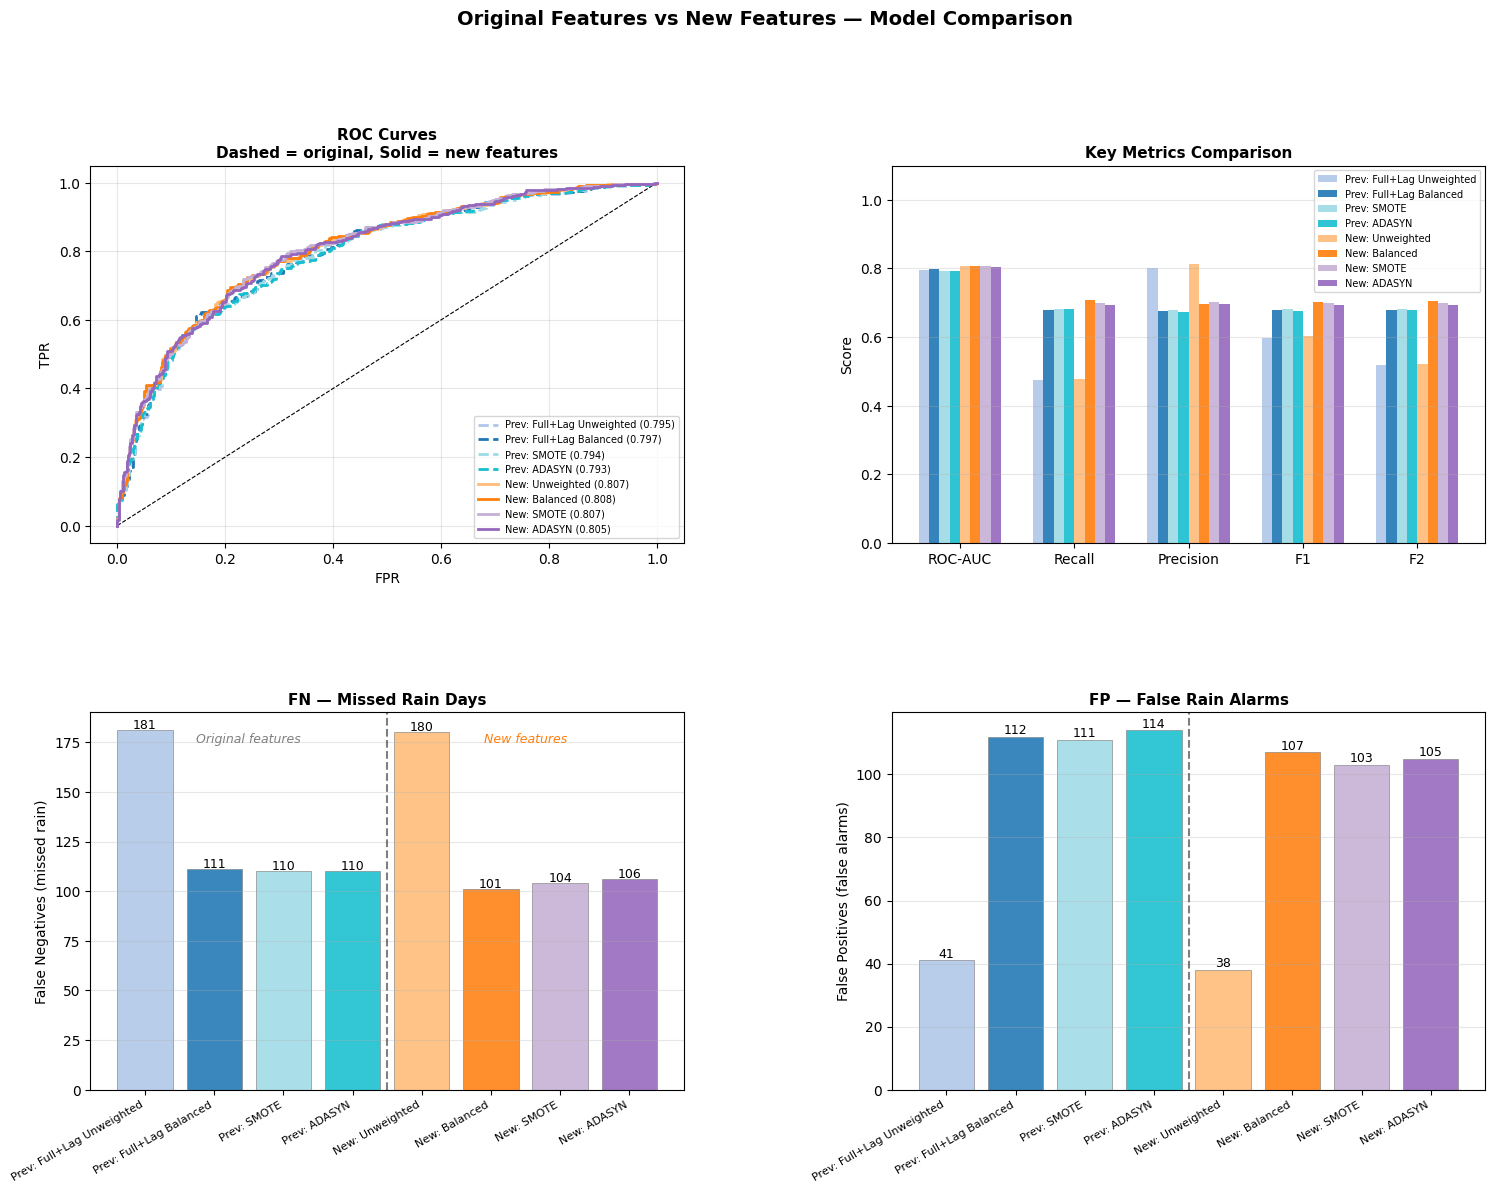


ORIGINAL vs NEW FEATURES — FULL COMPARISON
                    Model  ROC-AUC  Recall  Precision     F1     F2  FN  FP
Prev: Full+Lag Unweighted   0.7948  0.4754     0.8000 0.5964 0.5174 181  41
  Prev: Full+Lag Balanced   0.7969  0.6783     0.6763 0.6773 0.6779 111 112
              Prev: SMOTE   0.7938  0.6812     0.6792 0.6802 0.6808 110 111
             Prev: ADASYN   0.7935  0.6812     0.6734 0.6772 0.6796 110 114
          New: Unweighted   0.8070  0.4783     0.8128 0.6022 0.5212 180  38
            New: Balanced   0.8076  0.7072     0.6952 0.7011 0.7048 101 107
               New: SMOTE   0.8072  0.6986     0.7006 0.6996 0.6990 104 103
              New: ADASYN   0.8053  0.6928     0.6948 0.6938 0.6932 106 105


In [92]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    recall_score, precision_score, f1_score, fbeta_score
)

compare_models = [
    # ── Previous best models (original features) ──
    ("Prev: Full+Lag Unweighted",  y_test,    y_proba,       y_pred),
    ("Prev: Full+Lag Balanced",    y_test,    y_proba_bal,   y_pred_bal),
    ("Prev: SMOTE",                y_test,    y_proba_sm,    y_pred_sm),
    ("Prev: ADASYN",               y_test,    y_proba_ad,    y_pred_ad),
    # ── New feature models ──
    ("New: Unweighted",            y_test_nf, y_proba_nf,     y_pred_nf),
    ("New: Balanced",              y_test_nf, y_proba_nf_bal, y_pred_nf_bal),
    ("New: SMOTE",                 y_test_nf, y_proba_sm_nf,  y_pred_sm_nf),
    ("New: ADASYN",                y_test_nf, y_proba_ad_nf,  y_pred_ad_nf),
]
colors = ["#aec7e8","#1f77b4","#9edae5","#17becf",
          "#ffbb78","#ff7f0e","#c5b0d5","#9467bd"]
styles = ["--","--","--","--", "-","-","-","-"]

rows = []
for label, y_true, y_prob, y_p in compare_models:
    tn, fp, fn, tp = confusion_matrix(y_true, y_p).ravel()
    rows.append({
        "Model":     label,
        "ROC-AUC":   roc_auc_score(y_true, y_prob),
        "Recall":    recall_score(y_true, y_p, zero_division=0),
        "Precision": precision_score(y_true, y_p, zero_division=0),
        "F1":        f1_score(y_true, y_p, zero_division=0),
        "F2":        fbeta_score(y_true, y_p, beta=2, zero_division=0),
        "FN": fn, "FP": fp, "TP": tp, "TN": tn,
    })
res_df = pd.DataFrame(rows)

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# Panel 1: ROC curves
ax_roc = fig.add_subplot(gs[0, 0])
ax_roc.plot([0,1],[0,1],"k--",lw=0.8)
for (label, y_true, y_prob, _), c, ls in zip(compare_models, colors, styles):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax_roc.plot(fpr, tpr, color=c, lw=2, ls=ls, label=f"{label} ({auc:.3f})")
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC Curves\nDashed = original, Solid = new features",
                  fontweight="bold", fontsize=11)
ax_roc.legend(fontsize=7, loc="lower right"); ax_roc.grid(alpha=0.3)

# Panel 2: Key metrics grouped bar
ax_bar = fig.add_subplot(gs[0, 1])
metric_cols = ["ROC-AUC", "Recall", "Precision", "F1", "F2"]
x = np.arange(len(metric_cols))
n = len(res_df)
bar_w = 0.09
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * bar_w
for i, (row, c) in enumerate(zip(rows, colors)):
    vals = [row[m] for m in metric_cols]
    ax_bar.bar(x + offsets[i], vals, bar_w, label=row["Model"], color=c, alpha=0.9)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(metric_cols, fontsize=10)
ax_bar.set_ylim(0, 1.1); ax_bar.set_ylabel("Score")
ax_bar.set_title("Key Metrics Comparison", fontweight="bold", fontsize=11)
ax_bar.legend(fontsize=7, loc="upper right"); ax_bar.grid(axis="y", alpha=0.3)

# Panel 3: FN comparison
ax_fn = fig.add_subplot(gs[1, 0])
ax_fn.bar(range(n), res_df["FN"], color=colors, alpha=0.88, edgecolor="grey", lw=0.5)
for i, v in enumerate(res_df["FN"]):
    ax_fn.text(i, v + 1, str(int(v)), ha="center", fontsize=9)
ax_fn.set_xticks(range(n))
ax_fn.set_xticklabels(res_df["Model"], rotation=30, ha="right", fontsize=8)
ax_fn.set_ylabel("False Negatives (missed rain)")
ax_fn.set_title("FN — Missed Rain Days", fontweight="bold", fontsize=11)
ax_fn.axvline(3.5, color="black", lw=1.5, ls="--", alpha=0.5)
ax_fn.text(1.5, ax_fn.get_ylim()[1]*0.92, "Original features",
           ha="center", fontsize=9, style="italic", color="grey")
ax_fn.text(5.5, ax_fn.get_ylim()[1]*0.92, "New features",
           ha="center", fontsize=9, style="italic", color="#ff7f0e")
ax_fn.grid(axis="y", alpha=0.3)

# Panel 4: FP comparison
ax_fp = fig.add_subplot(gs[1, 1])
ax_fp.bar(range(n), res_df["FP"], color=colors, alpha=0.88, edgecolor="grey", lw=0.5)
for i, v in enumerate(res_df["FP"]):
    ax_fp.text(i, v + 1, str(int(v)), ha="center", fontsize=9)
ax_fp.set_xticks(range(n))
ax_fp.set_xticklabels(res_df["Model"], rotation=30, ha="right", fontsize=8)
ax_fp.set_ylabel("False Positives (false alarms)")
ax_fp.set_title("FP — False Rain Alarms", fontweight="bold", fontsize=11)
ax_fp.axvline(3.5, color="black", lw=1.5, ls="--", alpha=0.5)
ax_fp.grid(axis="y", alpha=0.3)

plt.suptitle("Original Features vs New Features — Model Comparison",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{PLOTS_DIR}/dc1_30_new_features_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*85)
print("ORIGINAL vs NEW FEATURES — FULL COMPARISON")
print("="*85)
print(res_df[["Model","ROC-AUC","Recall","Precision","F1","F2","FN","FP"]]
      .to_string(index=False, float_format="{:.4f}".format))


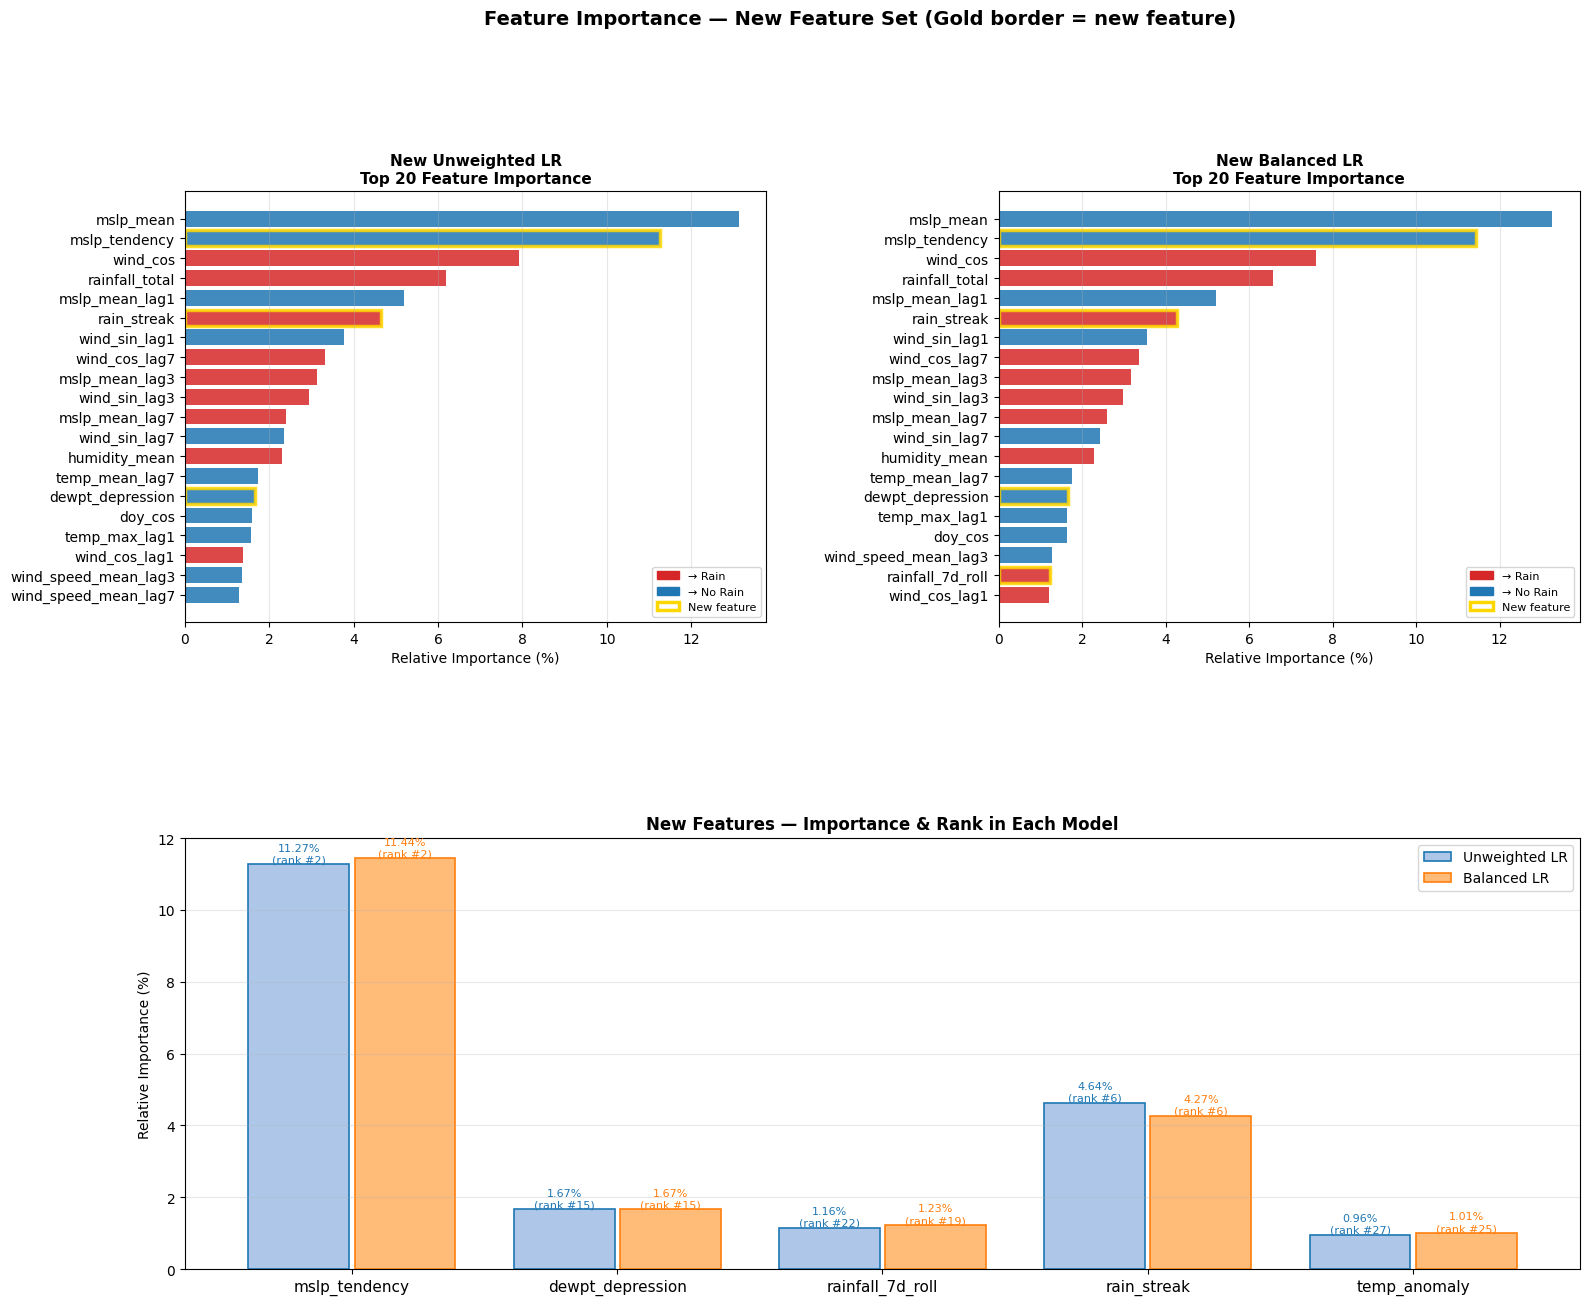

TOP 15 — New Unweighted LR
             Feature  Relative (%) Direction
0          mslp_mean        13.123   No Rain
1      mslp_tendency        11.272   No Rain
2           wind_cos         7.929      Rain
3     rainfall_total         6.199      Rain
4     mslp_mean_lag1         5.187   No Rain
5        rain_streak         4.637      Rain
6      wind_sin_lag1         3.782   No Rain
7      wind_cos_lag7         3.325      Rain
8     mslp_mean_lag3         3.119      Rain
9      wind_sin_lag3         2.938      Rain
10    mslp_mean_lag7         2.386      Rain
11     wind_sin_lag7         2.355   No Rain
12     humidity_mean         2.297      Rain
13    temp_mean_lag7         1.722   No Rain
14  dewpt_depression         1.671   No Rain

TOP 15 — New Balanced LR
             Feature  Relative (%) Direction
0          mslp_mean        13.265   No Rain
1      mslp_tendency        11.438   No Rain
2           wind_cos         7.614      Rain
3     rainfall_total         6.570      Rain
4 

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def feature_importance_df(lr_model, pca_model, feature_names):
    loadings   = pca_model.components_.T          # (n_features, n_components)
    importance = loadings @ lr_model.coef_[0]     # (n_features,)
    abs_imp    = np.abs(importance)
    rel_pct    = 100 * abs_imp / abs_imp.sum()
    return pd.DataFrame({
        "Feature":      feature_names,
        "Importance":   importance,
        "Abs":          abs_imp,
        "Relative (%)": rel_pct,
        "Direction":    ["Rain" if v > 0 else "No Rain" for v in importance],
    }).sort_values("Abs", ascending=False).reset_index(drop=True)

feature_names = X_train_nf.columns.tolist()
new_feats     = ["mslp_tendency", "dewpt_depression",
                  "rainfall_7d_roll", "rain_streak", "temp_anomaly"]

imp_unwt = feature_importance_df(lr_nf,     pca_nf_final, feature_names)
imp_bal  = feature_importance_df(lr_nf_bal, pca_nf_final, feature_names)

# ── Layout: 3 panels ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, hspace=0.5, wspace=0.4)

# Panel 1 — Unweighted top 20
ax1 = fig.add_subplot(gs[0, 0])
top_unwt = imp_unwt.head(20)
colors_unwt = ["#d62728" if d == "Rain" else "#1f77b4"
               for d in top_unwt["Direction"]]
bars = ax1.barh(top_unwt["Feature"][::-1], top_unwt["Relative (%)"][::-1],
                color=colors_unwt[::-1], alpha=0.85)
# Highlight new features
for bar, feat in zip(bars, top_unwt["Feature"][::-1]):
    if feat in new_feats:
        bar.set_edgecolor("gold"); bar.set_linewidth(2.5)
ax1.set_xlabel("Relative Importance (%)")
ax1.set_title("New Unweighted LR\nTop 20 Feature Importance",
              fontweight="bold", fontsize=11)
ax1.grid(axis="x", alpha=0.3)
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color="#d62728", label="→ Rain"),
    Patch(color="#1f77b4", label="→ No Rain"),
    Patch(facecolor="white", edgecolor="gold", lw=2.5, label="New feature"),
], fontsize=8, loc="lower right")

# Panel 2 — Balanced top 20
ax2 = fig.add_subplot(gs[0, 1])
top_bal = imp_bal.head(20)
colors_bal = ["#d62728" if d == "Rain" else "#1f77b4"
              for d in top_bal["Direction"]]
bars2 = ax2.barh(top_bal["Feature"][::-1], top_bal["Relative (%)"][::-1],
                 color=colors_bal[::-1], alpha=0.85)
for bar, feat in zip(bars2, top_bal["Feature"][::-1]):
    if feat in new_feats:
        bar.set_edgecolor("gold"); bar.set_linewidth(2.5)
ax2.set_xlabel("Relative Importance (%)")
ax2.set_title("New Balanced LR\nTop 20 Feature Importance",
              fontweight="bold", fontsize=11)
ax2.grid(axis="x", alpha=0.3)
ax2.legend(handles=[
    Patch(color="#d62728", label="→ Rain"),
    Patch(color="#1f77b4", label="→ No Rain"),
    Patch(facecolor="white", edgecolor="gold", lw=2.5, label="New feature"),
], fontsize=8, loc="lower right")

# Panel 3 — New features rank & importance in both models
ax3 = fig.add_subplot(gs[1, :])
nf_unwt = imp_unwt[imp_unwt["Feature"].isin(new_feats)].set_index("Feature")
nf_bal  = imp_bal[imp_bal["Feature"].isin(new_feats)].set_index("Feature")
nf_df   = pd.DataFrame({
    "Unweighted (%)": nf_unwt["Relative (%)"],
    "Balanced (%)":   nf_bal["Relative (%)"],
}).loc[new_feats]
x3 = np.arange(len(new_feats))
ax3.bar(x3 - 0.2, nf_df["Unweighted (%)"], 0.38,
        label="Unweighted LR", color="#aec7e8", edgecolor="#1f77b4", lw=1.2)
ax3.bar(x3 + 0.2, nf_df["Balanced (%)"],   0.38,
        label="Balanced LR",   color="#ffbb78", edgecolor="#ff7f0e", lw=1.2)
for i, feat in enumerate(new_feats):
    u = nf_df.loc[feat, "Unweighted (%)"]
    b = nf_df.loc[feat, "Balanced (%)"]
    rank_u = imp_unwt[imp_unwt["Feature"] == feat].index[0] + 1
    rank_b = imp_bal[imp_bal["Feature"]   == feat].index[0] + 1
    ax3.text(i - 0.2, u + 0.05, f"{u:.2f}%\n(rank #{rank_u})",
             ha="center", fontsize=8, color="#1f77b4")
    ax3.text(i + 0.2, b + 0.05, f"{b:.2f}%\n(rank #{rank_b})",
             ha="center", fontsize=8, color="#ff7f0e")
ax3.set_xticks(x3)
ax3.set_xticklabels(new_feats, fontsize=11)
ax3.set_ylabel("Relative Importance (%)")
ax3.set_title("New Features — Importance & Rank in Each Model",
              fontweight="bold", fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(axis="y", alpha=0.3)

plt.suptitle("Feature Importance — New Feature Set (Gold border = new feature)",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{PLOTS_DIR}/dc1_31_new_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Printed tables ────────────────────────────────────────────────────────────
print("TOP 15 — New Unweighted LR")
print(imp_unwt[["Feature","Relative (%)","Direction"]].head(15).to_string(index=True, float_format="{:.3f}".format))
print()
print("TOP 15 — New Balanced LR")
print(imp_bal[["Feature","Relative (%)","Direction"]].head(15).to_string(index=True, float_format="{:.3f}".format))
print()
print("NEW FEATURES SUMMARY")
print(nf_df.round(3).to_string())


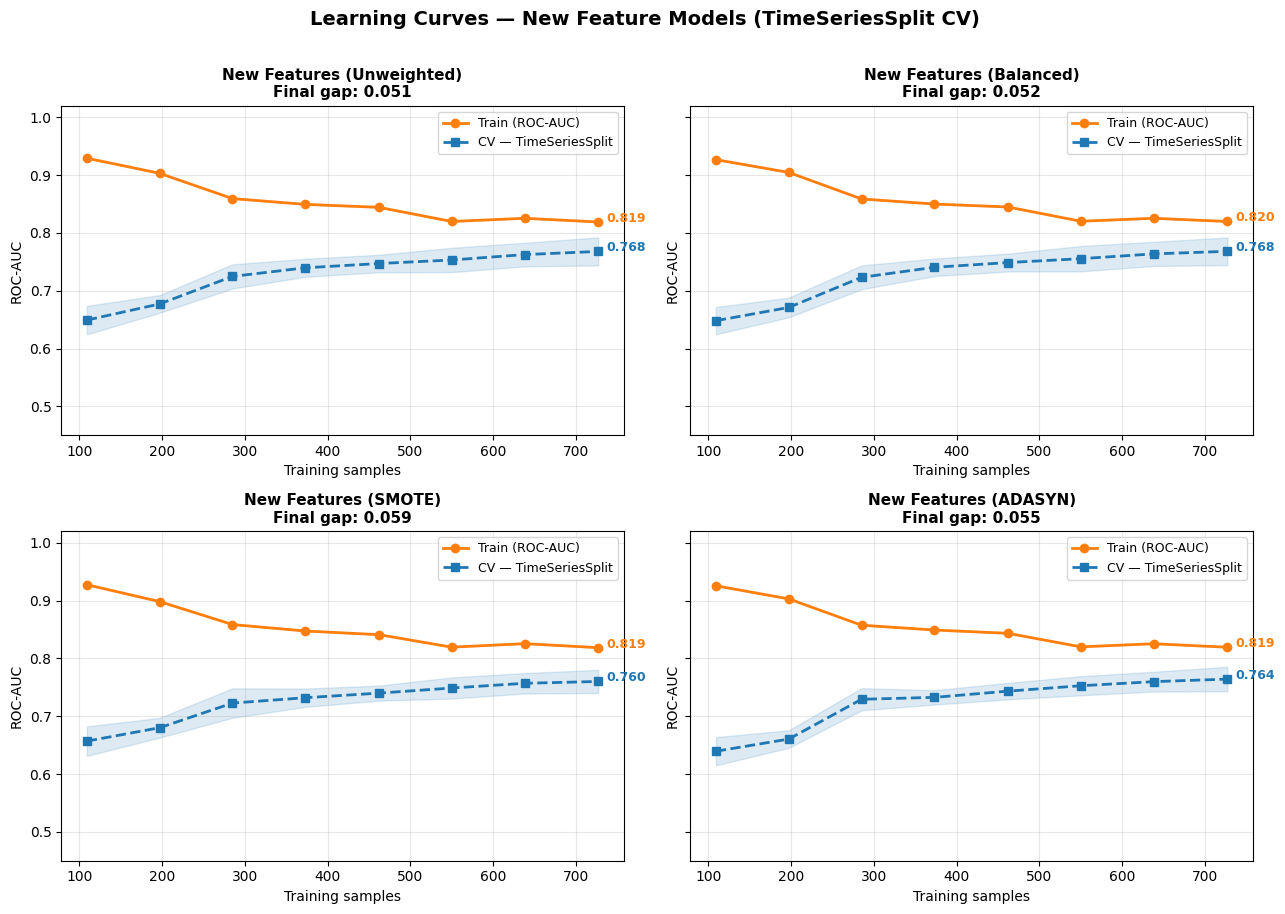

Train/CV gap summary (smaller = less overfitting):
  New Features (Unweighted)            train=0.8189  cv=0.7680  gap=0.0510
  New Features (Balanced)              train=0.8197  cv=0.7681  gap=0.0516
  New Features (SMOTE)                 train=0.8186  cv=0.7601  gap=0.0585
  New Features (ADASYN)                train=0.8193  cv=0.7642  gap=0.0551


In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

tscv       = TimeSeriesSplit(n_splits=5)
train_sizes = np.linspace(0.15, 1.0, 8)

pipe_configs = [
    ("New Features\n(Unweighted)",
     Pipeline([("sc",  StandardScaler()),
               ("pca", PCA(n_components=0.95)),
               ("lr",  LogisticRegression(max_iter=1000, random_state=42))]),
     X_train_nf, y_train_nf),
    ("New Features\n(Balanced)",
     Pipeline([("sc",  StandardScaler()),
               ("pca", PCA(n_components=0.95)),
               ("lr",  LogisticRegression(max_iter=1000, random_state=42,
                                          class_weight="balanced"))]),
     X_train_nf, y_train_nf),
    ("New Features\n(SMOTE)",
     ImbPipeline([("sc",  StandardScaler()),
                  ("sm",  SMOTE(random_state=42)),
                  ("pca", PCA(n_components=0.95)),
                  ("lr",  LogisticRegression(max_iter=1000, random_state=42))]),
     X_train_nf, y_train_nf),
    ("New Features\n(ADASYN)",
     ImbPipeline([("sc",  StandardScaler()),
                  ("ad",  ADASYN(random_state=42)),
                  ("pca", PCA(n_components=0.95)),
                  ("lr",  LogisticRegression(max_iter=1000, random_state=42))]),
     X_train_nf, y_train_nf),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
c_train, c_cv = "#ff7f0e", "#1f77b4"

for ax, (label, pipe, X, y) in zip(axes.flat, pipe_configs):
    sizes, tr_scores, cv_scores = learning_curve(
        pipe, X, y,
        train_sizes=train_sizes,
        cv=tscv,
        scoring="roc_auc",
        n_jobs=-1,
    )
    tr_mean = tr_scores.mean(axis=1); tr_std = tr_scores.std(axis=1)
    cv_mean = cv_scores.mean(axis=1); cv_std = cv_scores.std(axis=1)

    ax.plot(sizes, tr_mean, "o-",  color=c_train, lw=2, label="Train (ROC-AUC)")
    ax.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std,
                    alpha=0.15, color=c_train)
    ax.plot(sizes, cv_mean, "s--", color=c_cv,    lw=2, label="CV — TimeSeriesSplit")
    ax.fill_between(sizes, cv_mean - cv_std, cv_mean + cv_std,
                    alpha=0.15, color=c_cv)

    # Annotate final values
    ax.annotate(f"{tr_mean[-1]:.3f}", (sizes[-1], tr_mean[-1]),
                textcoords="offset points", xytext=(6, 0),
                fontsize=9, color=c_train, fontweight="bold")
    ax.annotate(f"{cv_mean[-1]:.3f}", (sizes[-1], cv_mean[-1]),
                textcoords="offset points", xytext=(6, 0),
                fontsize=9, color=c_cv, fontweight="bold")

    gap = tr_mean[-1] - cv_mean[-1]
    ax.set_title(f"{label.replace(chr(10), " ")}\nFinal gap: {gap:.3f}",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("Training samples")
    ax.set_ylabel("ROC-AUC")
    ax.set_ylim(0.45, 1.02)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Learning Curves — New Feature Models (TimeSeriesSplit CV)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/dc1_32_new_feat_learning_curves.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Train/CV gap summary (smaller = less overfitting):")
for label, pipe, X, y in pipe_configs:
    sizes, tr_s, cv_s = learning_curve(
        pipe, X, y, train_sizes=np.array([1.0]),
        cv=tscv, scoring="roc_auc", n_jobs=-1)
    print(f"  {label.replace(chr(10), " "):35s}  train={tr_s.mean():.4f}  cv={cv_s.mean():.4f}  gap={tr_s.mean()-cv_s.mean():.4f}")


---
## ARIMA Rainfall Forecast Baseline

ARIMA is a univariate time-series baseline, so this section forecasts `rainfall_total` directly from its own history. After forecasting rainfall amount, we convert the forecast into a rain/no-rain label using the same `RAIN_THRESHOLD = 0.2` rule used earlier for `rain_tomorrow`.

Because rainfall is spiky and has many zero values, this is best treated as a simple baseline rather than a final production model.


In [95]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Daily rainfall series for ARIMA-style modelling.
# asfreq('D') ensures the time index has a regular daily frequency for statsmodels.
rain_series = daily_df['rainfall_total'].asfreq('D').fillna(0)

split_date = '2023-01-01'
rain_train = rain_series[rain_series.index < split_date]
rain_test = rain_series[rain_series.index >= split_date]

y_test_rain = (rain_test > RAIN_THRESHOLD).astype(int)

print(f'Train days: {len(rain_train):,}  ({rain_train.index.min().date()} to {rain_train.index.max().date()})')
print(f'Test days:  {len(rain_test):,}  ({rain_test.index.min().date()} to {rain_test.index.max().date()})')
print(f'Test rain rate: {y_test_rain.mean()*100:.1f}%')


Train days: 4,362  (2011-01-22 to 2022-12-31)
Test days:  802  (2023-01-01 to 2025-03-12)
Test rain rate: 43.0%


In [96]:
def one_step_forecast(fitted_model, test_series):
    forecasts = []
    current_fit = fitted_model

    for timestamp, actual in test_series.items():
        pred = current_fit.forecast(steps=1).iloc[0]
        forecasts.append(pred)

        # Update the model state with the observed value, without refitting parameters.
        new_observation = pd.Series(
            [actual],
            index=pd.DatetimeIndex([timestamp]),
            name=test_series.name,
        )
        current_fit = current_fit.append(new_observation, refit=False)

    return pd.Series(forecasts, index=test_series.index).clip(lower=0)

# Plain ARIMA baseline. The small order keeps it fast and easy to interpret.
arima_model = ARIMA(rain_train, order=(1, 0, 1))
arima_fit = arima_model.fit()

arima_forecast = one_step_forecast(arima_fit, rain_test)

arima_mae = mean_absolute_error(rain_test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(rain_test, arima_forecast))
print(f'ARIMA(1,0,1) rolling one-step MAE:  {arima_mae:.3f} mm')
print(f'ARIMA(1,0,1) rolling one-step RMSE: {arima_rmse:.3f} mm')


ARIMA(1,0,1) rolling one-step MAE:  3.301 mm
ARIMA(1,0,1) rolling one-step RMSE: 7.155 mm


In [97]:
# Seasonal ARIMA with weekly seasonality as a slightly stronger time-series baseline.
# This is still univariate: only past rainfall is used.
sarima_model = SARIMAX(
    rain_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = one_step_forecast(sarima_fit, rain_test)

sarima_mae = mean_absolute_error(rain_test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(rain_test, sarima_forecast))
print(f'SARIMA(1,0,1)(1,0,1,7) rolling one-step MAE:  {sarima_mae:.3f} mm')
print(f'SARIMA(1,0,1)(1,0,1,7) rolling one-step RMSE: {sarima_rmse:.3f} mm')


SARIMA(1,0,1)(1,0,1,7) rolling one-step MAE:  3.501 mm
SARIMA(1,0,1)(1,0,1,7) rolling one-step RMSE: 7.130 mm


In [98]:
# Convert rainfall forecasts to rain/no-rain predictions with the same threshold.
arima_pred_rain = (arima_forecast > RAIN_THRESHOLD).astype(int)
sarima_pred_rain = (sarima_forecast > RAIN_THRESHOLD).astype(int)

print('ARIMA rain/no-rain classification')
print('=' * 48)
print(classification_report(y_test_rain, arima_pred_rain, target_names=['No Rain', 'Rain'], zero_division=0))

print('SARIMA rain/no-rain classification')
print('=' * 48)
print(classification_report(y_test_rain, sarima_pred_rain, target_names=['No Rain', 'Rain'], zero_division=0))


ARIMA rain/no-rain classification
              precision    recall  f1-score   support

     No Rain       0.00      0.00      0.00       457
        Rain       0.43      1.00      0.60       345

    accuracy                           0.43       802
   macro avg       0.22      0.50      0.30       802
weighted avg       0.19      0.43      0.26       802

SARIMA rain/no-rain classification
              precision    recall  f1-score   support

     No Rain       0.00      0.00      0.00       457
        Rain       0.43      1.00      0.60       345

    accuracy                           0.43       802
   macro avg       0.22      0.50      0.30       802
weighted avg       0.19      0.43      0.26       802



In [99]:
# Plotly ARIMA/SARIMA baseline forecast plot.
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'notebook_connected'
PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

arima_baseline_plot_df = pd.DataFrame({
    'Date': rain_test.index,
    'Actual rainfall': rain_test.to_numpy(),
    'ARIMA forecast': arima_forecast.to_numpy(),
    'SARIMA forecast': sarima_forecast.to_numpy(),
})
arima_baseline_long = arima_baseline_plot_df.melt(
    id_vars='Date',
    value_vars=['Actual rainfall', 'ARIMA forecast', 'SARIMA forecast'],
    var_name='Series',
    value_name='Rainfall mm',
)

fig_arima_baseline = px.line(
    arima_baseline_long,
    x='Date',
    y='Rainfall mm',
    color='Series',
    title='ARIMA/SARIMA Daily Rainfall Forecast Baseline',
    color_discrete_map={
        'Actual rainfall': '#222222',
        'ARIMA forecast': '#377eb8',
        'SARIMA forecast': '#f28e2b',
    },
)
fig_arima_baseline.add_hline(
    y=RAIN_THRESHOLD,
    line_dash='dash',
    line_color='#d62728',
    annotation_text=f'Rain threshold ({RAIN_THRESHOLD}mm)',
    annotation_position='top left',
)
fig_arima_baseline.update_layout(
    height=520,
    xaxis_title='Date',
    yaxis_title='Rainfall (mm)',
    legend_title='',
    hovermode='x unified',
)
fig_arima_baseline.write_html(f'{PLOTS_DIR}/plotly_arima_sarima_rainfall_forecast_baseline.html')
fig_arima_baseline.show(renderer='notebook_connected')

arima_summary = pd.DataFrame({
    'Model': ['ARIMA(1,0,1)', 'SARIMA(1,0,1)(1,0,1,7)'],
    'MAE_mm': [arima_mae, sarima_mae],
    'RMSE_mm': [arima_rmse, sarima_rmse],
    'Predicted rain days': [int(arima_pred_rain.sum()), int(sarima_pred_rain.sum())],
    'Actual rain days': [int(y_test_rain.sum()), int(y_test_rain.sum())],
})
arima_summary.round(3)


,Model,MAE_mm,RMSE_mm,Predicted rain days,Actual rain days
0,"ARIMA(1,0,1)",3.301,7.155,802,345
1,"SARIMA(1,0,1)(1,0,1,7)",3.501,7.130,802,345


---
## ARIMAX / SARIMAX Optimization for Rain Tomorrow

The first ARIMA section is a simple univariate baseline. This section improves it in three ways:

1. Predicts **tomorrow's rainfall amount** from information available today.
2. Adds exogenous weather features, turning ARIMA into **ARIMAX/SARIMAX**.
3. Uses expanding-window time-series validation to tune model order without random shuffling.

The target is still rainfall amount in mm. We then convert the amount forecast into rain/no-rain with the same `RAIN_THRESHOLD = 0.2` rule.


In [100]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

# Build ARIMAX-specific features using only information known by the end of the current day.
arimax_df = daily_df.copy().sort_index()

arimax_df['rainfall_tomorrow_amount'] = arimax_df['rainfall_total'].shift(-1)
arimax_df['rain_today_flag'] = (arimax_df['rainfall_total'] > RAIN_THRESHOLD).astype(int)
arimax_df['rainfall_3d_sum'] = arimax_df['rainfall_total'].rolling(3, min_periods=1).sum()
arimax_df['rainfall_7d_sum'] = arimax_df['rainfall_total'].rolling(7, min_periods=1).sum()
arimax_df['rainfall_14d_sum'] = arimax_df['rainfall_total'].rolling(14, min_periods=1).sum()
arimax_df['rainfall_7d_std'] = arimax_df['rainfall_total'].rolling(7, min_periods=3).std()
arimax_df['humidity_3d_mean'] = arimax_df['humidity_mean'].rolling(3, min_periods=1).mean()
arimax_df['mslp_3d_change'] = arimax_df['mslp_mean'] - arimax_df['mslp_mean'].shift(3)
arimax_df['temp_range'] = arimax_df['temp_max'] - arimax_df['temp_min']
arimax_df['dewpt_depression'] = arimax_df['temp_mean'] - arimax_df['dewpt_mean']
arimax_df['log_rainfall_today'] = np.log1p(arimax_df['rainfall_total'])

# These features are all known today and can be used to forecast tomorrow.
arimax_exog_cols = [
    'log_rainfall_today', 'rain_today_flag', 'rainfall_3d_sum', 'rainfall_7d_sum',
    'rainfall_14d_sum', 'rainfall_7d_std', 'rain_streak',
    'humidity_mean', 'humidity_3d_mean', 'dewpt_depression',
    'mslp_mean', 'mslp_tendency', 'mslp_3d_change',
    'temp_mean', 'temp_range', 'wind_speed_mean',
    'doy_sin', 'doy_cos', 'wind_sin', 'wind_cos',
]

arimax_df = arimax_df.dropna(subset=arimax_exog_cols + ['rainfall_tomorrow_amount'])
arimax_y = np.log1p(arimax_df['rainfall_tomorrow_amount'])
arimax_X = arimax_df[arimax_exog_cols]

print(f'ARIMAX rows: {len(arimax_df):,}')
print(f'Exogenous features: {len(arimax_exog_cols)}')
print(arimax_exog_cols)


ARIMAX rows: 5,160
Exogenous features: 20
['log_rainfall_today', 'rain_today_flag', 'rainfall_3d_sum', 'rainfall_7d_sum', 'rainfall_14d_sum', 'rainfall_7d_std', 'rain_streak', 'humidity_mean', 'humidity_3d_mean', 'dewpt_depression', 'mslp_mean', 'mslp_tendency', 'mslp_3d_change', 'temp_mean', 'temp_range', 'wind_speed_mean', 'doy_sin', 'doy_cos', 'wind_sin', 'wind_cos']


In [101]:
def make_expanding_folds(index, initial_train_end='2018-01-01', horizon_days=365, n_folds=5):
    folds = []
    cutoff = pd.Timestamp(initial_train_end)
    final_date = index.max()

    for _ in range(n_folds):
        test_end = cutoff + pd.Timedelta(days=horizon_days)
        train_idx = index < cutoff
        test_idx = (index >= cutoff) & (index < test_end)

        if test_idx.sum() == 0 or test_end > final_date + pd.Timedelta(days=1):
            break

        folds.append((train_idx, test_idx, cutoff, test_end - pd.Timedelta(days=1)))
        cutoff = test_end

    return folds

arimax_folds = make_expanding_folds(arimax_df.index, initial_train_end='2018-01-01', horizon_days=365, n_folds=5)
for fold_no, (_, test_idx, start, end) in enumerate(arimax_folds, start=1):
    print(f'Fold {fold_no}: test {start.date()} to {end.date()} ({test_idx.sum()} days)')


Fold 1: test 2018-01-01 to 2018-12-31 (365 days)
Fold 2: test 2019-01-01 to 2019-12-31 (365 days)
Fold 3: test 2020-01-01 to 2020-12-30 (365 days)
Fold 4: test 2020-12-31 to 2021-12-30 (365 days)
Fold 5: test 2021-12-31 to 2022-12-30 (365 days)


In [102]:
def evaluate_sarimax_cv(order, seasonal_order, y, X, folds):
    rows = []

    for fold_no, (train_idx, test_idx, start, end) in enumerate(folds, start=1):
        y_train, y_test = y.loc[train_idx], y.loc[test_idx]
        X_train, X_test = X.loc[train_idx], X.loc[test_idx]

        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns
        )
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test), index=X_test.index, columns=X_test.columns
        )

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            model = SARIMAX(
                y_train,
                exog=X_train_scaled,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fit = model.fit(disp=False, maxiter=100)

        pred_log = fit.forecast(steps=len(y_test), exog=X_test_scaled)
        pred_mm = np.expm1(pred_log).clip(lower=0)
        actual_mm = np.expm1(y_test)

        y_true_rain = (actual_mm > RAIN_THRESHOLD).astype(int)
        y_pred_rain = (pred_mm > RAIN_THRESHOLD).astype(int)

        rows.append({
            'fold': fold_no,
            'test_start': start.date(),
            'test_end': end.date(),
            'order': order,
            'seasonal_order': seasonal_order,
            'MAE_mm': mean_absolute_error(actual_mm, pred_mm),
            'RMSE_mm': np.sqrt(mean_squared_error(actual_mm, pred_mm)),
            'Rain_Precision': precision_score(y_true_rain, y_pred_rain, zero_division=0),
            'Rain_Recall': recall_score(y_true_rain, y_pred_rain, zero_division=0),
            'Rain_F1': f1_score(y_true_rain, y_pred_rain, zero_division=0),
            'AIC': fit.aic,
        })

    return pd.DataFrame(rows)


In [103]:
# Small SARIMAX order search. Keep this grid compact because each candidate runs across time-series folds.
orders = [(1, 0, 0), (1, 0, 1), (2, 0, 1), (1, 1, 1)]
seasonal_orders = [
    (0, 0, 0, 0),   # ARIMAX, no weekly seasonality
    (1, 0, 0, 7),   # weekly seasonal AR term
    (1, 0, 1, 7),   # weekly seasonal ARMA term
]

cv_results = []
for order in orders:
    for seasonal_order in seasonal_orders:
        print(f'Fitting order={order}, seasonal_order={seasonal_order}...')
        result = evaluate_sarimax_cv(order, seasonal_order, arimax_y, arimax_X, arimax_folds)
        cv_results.append(result)

cv_results_df = pd.concat(cv_results, ignore_index=True)
cv_summary = (
    cv_results_df
    .groupby(['order', 'seasonal_order'], as_index=False)
    .agg({
        'MAE_mm': 'mean',
        'RMSE_mm': 'mean',
        'Rain_Precision': 'mean',
        'Rain_Recall': 'mean',
        'Rain_F1': 'mean',
        'AIC': 'mean',
    })
    .sort_values(['Rain_F1', 'RMSE_mm'], ascending=[False, True])
)

cv_summary.round(4)


Fitting order=(1, 0, 0), seasonal_order=(0, 0, 0, 0)...
Fitting order=(1, 0, 0), seasonal_order=(1, 0, 0, 7)...
Fitting order=(1, 0, 0), seasonal_order=(1, 0, 1, 7)...
Fitting order=(1, 0, 1), seasonal_order=(0, 0, 0, 0)...
Fitting order=(1, 0, 1), seasonal_order=(1, 0, 0, 7)...
Fitting order=(1, 0, 1), seasonal_order=(1, 0, 1, 7)...
Fitting order=(2, 0, 1), seasonal_order=(0, 0, 0, 0)...
Fitting order=(2, 0, 1), seasonal_order=(1, 0, 0, 7)...
Fitting order=(2, 0, 1), seasonal_order=(1, 0, 1, 7)...
Fitting order=(1, 1, 1), seasonal_order=(0, 0, 0, 0)...
Fitting order=(1, 1, 1), seasonal_order=(1, 0, 0, 7)...
Fitting order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)...


,order,seasonal_order,MAE_mm,RMSE_mm,Rain_Precision,Rain_Recall,Rain_F1,AIC
5,"(1, 0, 1)","(1, 0, 1, 7)",1.9620,5.2181,0.5046,0.8896,0.6413,7205.7853
9,"(2, 0, 1)","(0, 0, 0, 0)",1.9602,5.1797,0.4934,0.9027,0.6361,7188.3660
3,"(1, 0, 1)","(0, 0, 0, 0)",1.9600,5.1808,0.4914,0.9057,0.6351,7183.2146
4,"(1, 0, 1)","(1, 0, 0, 7)",1.9596,5.1858,0.4909,0.9054,0.6345,7176.9917
10,"(2, 0, 1)","(1, 0, 0, 7)",1.9651,5.1947,0.4900,0.9027,0.6332,7182.6703
11,"(2, 0, 1)","(1, 0, 1, 7)",2.0017,5.2706,0.4832,0.8566,0.6152,7200.5006
2,"(1, 0, 0)","(1, 0, 1, 7)",2.0421,5.3288,0.4715,0.8325,0.5994,7191.1212
8,"(1, 1, 1)","(1, 0, 1, 7)",2.0774,5.3096,0.4556,0.8529,0.5912,7156.8694
6,"(1, 1, 1)","(0, 0, 0, 0)",2.0790,5.3117,0.4564,0.8498,0.5909,7165.7739
7,"(1, 1, 1)","(1, 0, 0, 7)",2.0782,5.3115,0.4555,0.8478,0.5897,7158.6913


In [104]:
best_row = cv_summary.iloc[0]
best_order = best_row['order']
best_seasonal_order = best_row['seasonal_order']

print(f'Best by CV Rain F1: order={best_order}, seasonal_order={best_seasonal_order}')

# Only round numeric metrics. The order columns are tuples, so best_row.round(4) will fail.
best_metrics = best_row.drop(labels=['order', 'seasonal_order']).astype(float).round(4)
print(best_metrics)


Best by CV Rain F1: order=(1, 0, 1), seasonal_order=(1, 0, 1, 7)
MAE_mm               1.9620
RMSE_mm              5.2181
Rain_Precision       0.5046
Rain_Recall          0.8896
Rain_F1              0.6413
AIC               7205.7853
Name: 5, dtype: float64


In [105]:
# Final holdout evaluation on the same 2023+ period used by the classifier models.
split_date = '2023-01-01'
train_idx = arimax_df.index < split_date
test_idx = arimax_df.index >= split_date

y_train_arimax, y_test_arimax = arimax_y.loc[train_idx], arimax_y.loc[test_idx]
X_train_arimax, X_test_arimax = arimax_X.loc[train_idx], arimax_X.loc[test_idx]

arimax_scaler = StandardScaler()
X_train_arimax_scaled = pd.DataFrame(
    arimax_scaler.fit_transform(X_train_arimax),
    index=X_train_arimax.index,
    columns=X_train_arimax.columns,
)
X_test_arimax_scaled = pd.DataFrame(
    arimax_scaler.transform(X_test_arimax),
    index=X_test_arimax.index,
    columns=X_test_arimax.columns,
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    final_arimax_model = SARIMAX(
        y_train_arimax,
        exog=X_train_arimax_scaled,
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    final_arimax_fit = final_arimax_model.fit(disp=False, maxiter=150)

arimax_pred_log = final_arimax_fit.forecast(steps=len(y_test_arimax), exog=X_test_arimax_scaled)
# statsmodels can return an integer index here, so force predictions back onto test dates.
arimax_pred_mm = pd.Series(
    np.expm1(arimax_pred_log).clip(lower=0).to_numpy(),
    index=y_test_arimax.index,
    name='arimax_pred_mm',
)
arimax_actual_mm = pd.Series(
    np.expm1(y_test_arimax).to_numpy(),
    index=y_test_arimax.index,
    name='actual_rainfall_mm',
)

y_test_arimax_rain = (arimax_actual_mm > RAIN_THRESHOLD).astype(int)
y_pred_arimax_rain = (arimax_pred_mm > RAIN_THRESHOLD).astype(int)

print('Final ARIMAX/SARIMAX holdout evaluation')
print('=' * 60)
print(f'MAE:  {mean_absolute_error(arimax_actual_mm, arimax_pred_mm):.3f} mm')
print(f'RMSE: {np.sqrt(mean_squared_error(arimax_actual_mm, arimax_pred_mm)):.3f} mm')
print(classification_report(y_test_arimax_rain, y_pred_arimax_rain, target_names=['No Rain', 'Rain'], zero_division=0))


Final ARIMAX/SARIMAX holdout evaluation
MAE:  2.851 mm
RMSE: 7.536 mm
              precision    recall  f1-score   support

     No Rain       0.74      0.23      0.35       413
        Rain       0.53      0.91      0.67       388

    accuracy                           0.56       801
   macro avg       0.63      0.57      0.51       801
weighted avg       0.64      0.56      0.51       801



In [106]:
# Threshold tuning for ARIMAX rainfall amount forecasts.
# This is a model-development diagnostic: it shows whether the default 0.2mm threshold
# is too aggressive or too conservative for the forecast distribution.
from sklearn.metrics import fbeta_score
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'notebook_connected'
PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

threshold_rows = []
for threshold in np.arange(0.0, 5.05, 0.05):
    y_pred_threshold = (arimax_pred_mm > threshold).astype(int)
    threshold_rows.append({
        'threshold_mm': threshold,
        'precision': precision_score(y_test_arimax_rain, y_pred_threshold, zero_division=0),
        'recall': recall_score(y_test_arimax_rain, y_pred_threshold, zero_division=0),
        'f1': f1_score(y_test_arimax_rain, y_pred_threshold, zero_division=0),
        'f2': fbeta_score(y_test_arimax_rain, y_pred_threshold, beta=2, zero_division=0),
        'predicted_rain_days': int(y_pred_threshold.sum()),
    })

arimax_thresholds = pd.DataFrame(threshold_rows)
best_f1_threshold = arimax_thresholds.loc[arimax_thresholds['f1'].idxmax()]
best_f2_threshold = arimax_thresholds.loc[arimax_thresholds['f2'].idxmax()]

print('Best ARIMAX threshold by F1')
print(best_f1_threshold.round(4))
print()
print('Best ARIMAX threshold by F2')
print(best_f2_threshold.round(4))

threshold_plot_long = arimax_thresholds.melt(
    id_vars='threshold_mm',
    value_vars=['precision', 'recall', 'f1', 'f2'],
    var_name='Metric',
    value_name='Score',
)
fig_arimax_thresholds = px.line(
    threshold_plot_long,
    x='threshold_mm',
    y='Score',
    color='Metric',
    title='SARIMAX Rain Threshold Tuning on 2023+ Holdout',
    labels={'threshold_mm': 'Rain threshold (mm)'},
    color_discrete_map={'precision': '#756bb1', 'recall': '#31a354', 'f1': '#3182bd', 'f2': '#fd8d3c'},
)
fig_arimax_thresholds.add_vline(x=float(best_f1_threshold['threshold_mm']), line_dash='dash', line_color='#3182bd', annotation_text='Best F1')
fig_arimax_thresholds.add_vline(x=float(best_f2_threshold['threshold_mm']), line_dash='dot', line_color='#fd8d3c', annotation_text='Best F2')
fig_arimax_thresholds.update_layout(height=520, hovermode='x unified', legend_title='')
fig_arimax_thresholds.write_html(f'{PLOTS_DIR}/plotly_sarimax_threshold_tuning.html')
fig_arimax_thresholds.show(renderer='notebook_connected')

arimax_thresholds.sort_values('f1', ascending=False).head(10).round(4)


Best ARIMAX threshold by F1
threshold_mm             0.6500
precision                0.7002
recall                   0.7526
f1                       0.7255
f2                       0.7415
predicted_rain_days    417.0000
Name: 13, dtype: float64

Best ARIMAX threshold by F2
threshold_mm             0.0000
precision                0.4967
recall                   0.9768
f1                       0.6586
f2                       0.8186
predicted_rain_days    763.0000
Name: 0, dtype: float64


,threshold_mm,precision,recall,f1,f2,predicted_rain_days
13,0.65,0.7002,0.7526,0.7255,0.7415,417
12,0.60,0.6811,0.7706,0.7231,0.7509,439
14,0.70,0.7143,0.7216,0.7179,0.7202,392
11,0.55,0.6573,0.7861,0.7160,0.7564,464
15,0.75,0.7285,0.6985,0.7132,0.7043,372
16,0.80,0.7536,0.6701,0.7094,0.6853,345
10,0.50,0.6341,0.8041,0.7091,0.7632,492
9,0.45,0.6149,0.8273,0.7055,0.7739,522
8,0.40,0.5960,0.8402,0.6973,0.7766,547
17,0.85,0.7647,0.6366,0.6948,0.6587,323


In [107]:
# Compare optimized ARIMAX/SARIMAX against the best logistic-regression variants.
# This uses the same 2023+ holdout period and rain/no-rain target.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'notebook_connected'
PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

common_idx = y_test_nf.index.intersection(y_test_arimax_rain.index)
y_true_compare = y_test_nf.loc[common_idx].astype(int)

arimax_pred_default = (arimax_pred_mm.loc[common_idx] > RAIN_THRESHOLD).astype(int)
arimax_pred_f1 = (arimax_pred_mm.loc[common_idx] > best_f1_threshold['threshold_mm']).astype(int)
arimax_pred_f2 = (arimax_pred_mm.loc[common_idx] > best_f2_threshold['threshold_mm']).astype(int)

comparison_specs = [
    ('LR Balanced', y_pred_nf_bal, y_proba_nf_bal),
    ('LR SMOTE', y_pred_sm_nf, y_proba_sm_nf),
    ('LR ADASYN', y_pred_ad_nf, y_proba_ad_nf),
    ('SARIMAX 0.2mm', arimax_pred_default, arimax_pred_mm.loc[common_idx]),
    (f'SARIMAX F1 t={best_f1_threshold["threshold_mm"]:.2f}mm', arimax_pred_f1, arimax_pred_mm.loc[common_idx]),
    (f'SARIMAX F2 t={best_f2_threshold["threshold_mm"]:.2f}mm', arimax_pred_f2, arimax_pred_mm.loc[common_idx]),
]

comparison_rows = []
for label, y_pred_model, y_score_model in comparison_specs:
    if isinstance(y_pred_model, pd.Series):
        y_pred_aligned = y_pred_model.loc[common_idx].astype(int)
    else:
        y_pred_aligned = pd.Series(y_pred_model, index=y_test_nf.index).loc[common_idx].astype(int)

    if isinstance(y_score_model, pd.Series):
        y_score_aligned = y_score_model.loc[common_idx]
    else:
        y_score_aligned = pd.Series(y_score_model, index=y_test_nf.index).loc[common_idx]

    tn, fp, fn, tp = confusion_matrix(y_true_compare, y_pred_aligned).ravel()
    try:
        auc = roc_auc_score(y_true_compare, y_score_aligned)
    except ValueError:
        auc = np.nan

    comparison_rows.append({
        'Model': label,
        'Accuracy': accuracy_score(y_true_compare, y_pred_aligned),
        'Rain Precision': precision_score(y_true_compare, y_pred_aligned, zero_division=0),
        'Rain Recall': recall_score(y_true_compare, y_pred_aligned, zero_division=0),
        'Rain F1': f1_score(y_true_compare, y_pred_aligned, zero_division=0),
        'Rain F2': fbeta_score(y_true_compare, y_pred_aligned, beta=2, zero_division=0),
        'ROC-AUC / Score-AUC': auc,
        'FN': fn,
        'FP': fp,
        'TP': tp,
        'TN': tn,
    })

model_comparison_df = pd.DataFrame(comparison_rows).sort_values('Rain F1', ascending=False)
print('=' * 90)
print('LOGISTIC REGRESSION vs OPTIMIZED ARIMAX/SARIMAX - 2023+ HOLDOUT')
print('=' * 90)
print(model_comparison_df.round(4).to_string(index=False))

comparison_plot_long = model_comparison_df.melt(
    id_vars='Model',
    value_vars=['Rain F1', 'Rain Recall', 'FN'],
    var_name='Metric',
    value_name='Value',
)
fig_lr_vs_sarimax = px.bar(
    comparison_plot_long,
    x='Value',
    y='Model',
    color='Metric',
    facet_col='Metric',
    facet_col_spacing=0.08,
    orientation='h',
    text='Value',
    title='2023+ Holdout: Logistic Regression vs Optimized SARIMAX',
    color_discrete_map={'Rain F1': '#3182bd', 'Rain Recall': '#31a354', 'FN': '#de2d26'},
)
fig_lr_vs_sarimax.update_traces(texttemplate='%{text:.3f}', textposition='outside', cliponaxis=False)
fig_lr_vs_sarimax.update_yaxes(matches=None, categoryorder='total ascending')
fig_lr_vs_sarimax.update_xaxes(matches=None)
fig_lr_vs_sarimax.update_layout(height=620, showlegend=False, xaxis_title='', yaxis_title='')
fig_lr_vs_sarimax.write_html(f'{PLOTS_DIR}/plotly_lr_vs_sarimax_comparison.html')
fig_lr_vs_sarimax.show(renderer='notebook_connected')


LOGISTIC REGRESSION vs OPTIMIZED ARIMAX/SARIMAX - 2023+ HOLDOUT
              Model  Accuracy  Rain Precision  Rain Recall  Rain F1  Rain F2  ROC-AUC / Score-AUC  FN  FP  TP  TN
SARIMAX F1 t=0.65mm    0.7179          0.6427       0.7768   0.7034   0.7457               0.7818  77 149 268 307
        LR Balanced    0.7403          0.6952       0.7072   0.7011   0.7048               0.8076 101 107 244 349
           LR SMOTE    0.7416          0.7006       0.6986   0.6996   0.6990               0.8072 104 103 241 353
          LR ADASYN    0.7366          0.6948       0.6928   0.6938   0.6932               0.8052 106 105 239 351
      SARIMAX 0.2mm    0.5306          0.4770       0.9304   0.6306   0.7818               0.7818  24 352 321 104
SARIMAX F2 t=0.00mm    0.4657          0.4456       0.9855   0.6137   0.7933               0.7818   5 423 340  33


In [108]:
# Compare baseline ARIMA/SARIMA models against the optimized ARIMAX/SARIMAX model.
# Baseline ARIMA/SARIMA use rainfall history only; optimized ARIMAX/SARIMAX also uses weather features.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, mean_absolute_error, mean_squared_error
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'notebook_connected'
PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

common_idx = rain_test.index.intersection(arimax_actual_mm.index)
actual_mm_compare = rain_test.loc[common_idx]
y_true_compare = (actual_mm_compare > RAIN_THRESHOLD).astype(int)

arima_baseline_compare = arima_forecast.loc[common_idx]
sarima_baseline_compare = sarima_forecast.loc[common_idx]
arimax_optimized_compare = arimax_pred_mm.loc[common_idx]

baseline_vs_optimized_specs = [
    ('Baseline ARIMA', arima_baseline_compare, RAIN_THRESHOLD),
    ('Baseline SARIMA', sarima_baseline_compare, RAIN_THRESHOLD),
    ('Optimized SARIMAX 0.2mm', arimax_optimized_compare, RAIN_THRESHOLD),
    ('Optimized SARIMAX F1 threshold', arimax_optimized_compare, best_f1_threshold['threshold_mm']),
    ('Optimized SARIMAX F2 threshold', arimax_optimized_compare, best_f2_threshold['threshold_mm']),
]

rows = []
for label, forecast_mm, threshold in baseline_vs_optimized_specs:
    y_pred_compare = (forecast_mm > threshold).astype(int)
    rows.append({
        'Model': label,
        'Threshold mm': threshold,
        'MAE mm': mean_absolute_error(actual_mm_compare, forecast_mm),
        'RMSE mm': np.sqrt(mean_squared_error(actual_mm_compare, forecast_mm)),
        'Accuracy': accuracy_score(y_true_compare, y_pred_compare),
        'Rain Precision': precision_score(y_true_compare, y_pred_compare, zero_division=0),
        'Rain Recall': recall_score(y_true_compare, y_pred_compare, zero_division=0),
        'Rain F1': f1_score(y_true_compare, y_pred_compare, zero_division=0),
        'Rain F2': fbeta_score(y_true_compare, y_pred_compare, beta=2, zero_division=0),
        'Predicted Rain Days': int(y_pred_compare.sum()),
    })

arima_optimization_comparison = pd.DataFrame(rows).sort_values('Rain F1', ascending=False)
print('=' * 95)
print('BASELINE ARIMA/SARIMA vs OPTIMIZED ARIMAX/SARIMAX - 2023+ HOLDOUT')
print('=' * 95)
print(arima_optimization_comparison.round(4).to_string(index=False))

forecast_long = pd.DataFrame({
    'Date': actual_mm_compare.index,
    'Actual rainfall': actual_mm_compare.to_numpy(),
    'Baseline ARIMA': arima_baseline_compare.to_numpy(),
    'Baseline SARIMA': sarima_baseline_compare.to_numpy(),
    'Optimized SARIMAX': arimax_optimized_compare.to_numpy(),
}).melt(id_vars='Date', var_name='Series', value_name='Rainfall mm')

fig_arima_vs_sarimax_ts = px.line(
    forecast_long,
    x='Date',
    y='Rainfall mm',
    color='Series',
    title='Baseline ARIMA/SARIMA vs Optimized SARIMAX: 2023+ Holdout Forecasts',
    color_discrete_map={
        'Actual rainfall': '#222222',
        'Baseline ARIMA': '#377eb8',
        'Baseline SARIMA': '#f28e2b',
        'Optimized SARIMAX': '#2ca25f',
    },
)
fig_arima_vs_sarimax_ts.add_hline(y=RAIN_THRESHOLD, line_dash='dash', line_color='#d62728', annotation_text=f'{RAIN_THRESHOLD}mm threshold')
fig_arima_vs_sarimax_ts.update_yaxes(range=[0, float(np.nanpercentile(actual_mm_compare, 98) * 1.15)])
fig_arima_vs_sarimax_ts.update_layout(height=560, hovermode='x unified', legend_title='', yaxis_title='Rainfall (mm)')
fig_arima_vs_sarimax_ts.write_html(f'{PLOTS_DIR}/plotly_baseline_arima_vs_optimized_sarimax_forecasts.html')
fig_arima_vs_sarimax_ts.show(renderer='notebook_connected')

metrics_long = arima_optimization_comparison.melt(
    id_vars='Model',
    value_vars=['Rain F1', 'Rain Recall', 'RMSE mm'],
    var_name='Metric',
    value_name='Value',
)
fig_arima_vs_sarimax_metrics = px.bar(
    metrics_long,
    x='Value',
    y='Model',
    color='Metric',
    facet_col='Metric',
    facet_col_spacing=0.08,
    orientation='h',
    text='Value',
    title='Baseline ARIMA/SARIMA vs Optimized SARIMAX: Holdout Metrics',
    color_discrete_map={'Rain F1': '#6a51a3', 'Rain Recall': '#31a354', 'RMSE mm': '#fd8d3c'},
)
fig_arima_vs_sarimax_metrics.update_traces(texttemplate='%{text:.3f}', textposition='outside', cliponaxis=False)
fig_arima_vs_sarimax_metrics.update_yaxes(matches=None, categoryorder='total ascending')
fig_arima_vs_sarimax_metrics.update_xaxes(matches=None)
fig_arima_vs_sarimax_metrics.update_layout(height=620, showlegend=False, xaxis_title='', yaxis_title='')
fig_arima_vs_sarimax_metrics.write_html(f'{PLOTS_DIR}/plotly_baseline_arima_vs_optimized_sarimax_metrics.html')
fig_arima_vs_sarimax_metrics.show(renderer='notebook_connected')


BASELINE ARIMA/SARIMA vs OPTIMIZED ARIMAX/SARIMAX - 2023+ HOLDOUT
                         Model  Threshold mm  MAE mm  RMSE mm  Accuracy  Rain Precision  Rain Recall  Rain F1  Rain F2  Predicted Rain Days
Optimized SARIMAX F1 threshold          0.65  2.8360   7.4545    0.6704          0.5971       0.7217   0.6535   0.6928                  417
       Optimized SARIMAX 0.2mm          0.20  2.8360   7.4545    0.5106          0.4651       0.9072   0.6149   0.7623                  673
Optimized SARIMAX F2 threshold          0.00  2.8360   7.4545    0.4557          0.4404       0.9739   0.6065   0.7839                  763
                Baseline ARIMA          0.20  3.3036   7.1595    0.4307          0.4307       1.0000   0.6021   0.7909                  801
               Baseline SARIMA          0.20  3.5035   7.1341    0.4307          0.4307       1.0000   0.6021   0.7909                  801


In [109]:
# Plotly ARIMA/SARIMAX plotting diagnostics.
# Interactive versions of the forecast overlays, CV search, threshold curves,
# residual checks, and rain/no-rain confusion diagnostics.
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'notebook_connected'
PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

required_plot_vars = [
    'rain_test', 'arima_forecast', 'sarima_forecast',
    'arimax_actual_mm', 'arimax_pred_mm', 'cv_summary', 'cv_results_df',
    'arimax_thresholds', 'best_f1_threshold', 'best_f2_threshold'
]
missing_plot_vars = [name for name in required_plot_vars if name not in globals()]

if missing_plot_vars:
    print('Run the ARIMA/SARIMAX CV, holdout, and threshold cells first.')
    print('Missing:', missing_plot_vars)
else:
    plot_summary = cv_summary.head(12).copy()
    plot_summary['Rain_F1'] = pd.to_numeric(plot_summary['Rain_F1'], errors='coerce')
    plot_summary['RMSE_mm'] = pd.to_numeric(plot_summary['RMSE_mm'], errors='coerce')
    plot_summary = plot_summary.dropna(subset=['Rain_F1', 'RMSE_mm'])
    plot_summary['Model'] = plot_summary.apply(lambda r: f"{r['order']} | {r['seasonal_order']}", axis=1)

    forecast_compare = pd.DataFrame({
        'Actual rainfall': arimax_actual_mm,
        'Optimized SARIMAX': arimax_pred_mm,
    })
    common_baseline_idx = forecast_compare.index.intersection(rain_test.index)
    forecast_compare.loc[common_baseline_idx, 'Baseline ARIMA'] = arima_forecast.loc[common_baseline_idx]
    forecast_compare.loc[common_baseline_idx, 'Baseline SARIMA'] = sarima_forecast.loc[common_baseline_idx]
    forecast_compare = forecast_compare.sort_index()
    residuals = forecast_compare['Actual rainfall'] - forecast_compare['Optimized SARIMAX']

    forecast_long = forecast_compare.reset_index(names='Date').melt(
        id_vars='Date',
        value_vars=['Actual rainfall', 'Optimized SARIMAX', 'Baseline ARIMA', 'Baseline SARIMA'],
        var_name='Series',
        value_name='Rainfall mm',
    )
    fig_forecasts = px.line(
        forecast_long,
        x='Date',
        y='Rainfall mm',
        color='Series',
        title='ARIMA / SARIMAX Holdout Forecasts: Tomorrow Rainfall',
        color_discrete_map={
            'Actual rainfall': '#222222',
            'Optimized SARIMAX': '#2ca25f',
            'Baseline ARIMA': '#377eb8',
            'Baseline SARIMA': '#f28e2b',
        },
    )
    fig_forecasts.add_hline(y=RAIN_THRESHOLD, line_dash='dash', line_color='#d62728', annotation_text=f'{RAIN_THRESHOLD}mm threshold')
    fig_forecasts.update_yaxes(range=[0, float(np.nanpercentile(forecast_compare['Actual rainfall'], 98) * 1.15)])
    fig_forecasts.update_layout(height=600, hovermode='x unified', legend_title='', yaxis_title='Rainfall (mm)')
    fig_forecasts.write_html(f'{PLOTS_DIR}/plotly_arima_sarimax_holdout_forecasts.html')
    fig_forecasts.show(renderer='notebook_connected')

    fig_cv_search = px.scatter(
        plot_summary,
        x='RMSE_mm',
        y='Rain_F1',
        size='Rain_Recall',
        color='Rain_Precision',
        hover_name='Model',
        title='SARIMAX Time-Series CV Search: Rain F1 vs RMSE',
        labels={'RMSE_mm': 'Mean CV RMSE (mm)', 'Rain_F1': 'Mean CV Rain F1'},
        color_continuous_scale='Viridis',
    )
    fig_cv_search.update_layout(height=540)
    fig_cv_search.write_html(f'{PLOTS_DIR}/plotly_sarimax_cv_search.html')
    fig_cv_search.show(renderer='notebook_connected')

    residual_df = pd.DataFrame({
        'Date': forecast_compare.index,
        'Actual rainfall mm': forecast_compare['Actual rainfall'].to_numpy(),
        'Forecast rainfall mm': forecast_compare['Optimized SARIMAX'].to_numpy(),
        'Residual mm': residuals.to_numpy(),
    })
    fig_actual_vs_forecast = px.scatter(
        residual_df,
        x='Actual rainfall mm',
        y='Forecast rainfall mm',
        color='Residual mm',
        hover_data=['Date'],
        title='SARIMAX Holdout: Actual vs Forecast Amount',
        color_continuous_scale='RdBu_r',
    )
    max_axis = float(np.nanpercentile(forecast_compare['Actual rainfall'], 98))
    fig_actual_vs_forecast.add_shape(type='line', x0=0, y0=0, x1=max_axis, y1=max_axis, line=dict(color='black', dash='dash'))
    fig_actual_vs_forecast.update_layout(height=540)
    fig_actual_vs_forecast.write_html(f'{PLOTS_DIR}/plotly_sarimax_actual_vs_forecast_amount.html')
    fig_actual_vs_forecast.show(renderer='notebook_connected')

    fig_residual_hist = px.histogram(
        residual_df,
        x='Residual mm',
        nbins=40,
        title='SARIMAX Holdout Residual Distribution',
        color_discrete_sequence=['#756bb1'],
    )
    fig_residual_hist.add_vline(x=0, line_color='#222222')
    fig_residual_hist.update_layout(height=480, yaxis_title='Days')
    fig_residual_hist.write_html(f'{PLOTS_DIR}/plotly_sarimax_residual_distribution.html')
    fig_residual_hist.show(renderer='notebook_connected')

    threshold_long = arimax_thresholds.melt(
        id_vars='threshold_mm',
        value_vars=['precision', 'recall', 'f1', 'f2'],
        var_name='Metric',
        value_name='Score',
    )
    fig_threshold = px.line(
        threshold_long,
        x='threshold_mm',
        y='Score',
        color='Metric',
        title='SARIMAX Threshold Sensitivity',
        color_discrete_map={'precision': '#756bb1', 'recall': '#31a354', 'f1': '#3182bd', 'f2': '#fd8d3c'},
    )
    fig_threshold.add_vline(x=float(best_f1_threshold['threshold_mm']), line_dash='dash', line_color='#3182bd', annotation_text='Best F1')
    fig_threshold.add_vline(x=float(best_f2_threshold['threshold_mm']), line_dash='dot', line_color='#fd8d3c', annotation_text='Best F2')
    fig_threshold.update_layout(height=520, hovermode='x unified', legend_title='')
    fig_threshold.write_html(f'{PLOTS_DIR}/plotly_sarimax_threshold_sensitivity.html')
    fig_threshold.show(renderer='notebook_connected')

    rain_class_df = pd.DataFrame({
        'Date': arimax_actual_mm.index,
        'Actual rain': (arimax_actual_mm > RAIN_THRESHOLD).astype(int).to_numpy(),
        'SARIMAX predicted rain': (arimax_pred_mm > RAIN_THRESHOLD).astype(int).to_numpy(),
    })
    rain_class_counts = rain_class_df.groupby(['Actual rain', 'SARIMAX predicted rain']).size().reset_index(name='Days')
    rain_class_counts['Actual rain'] = rain_class_counts['Actual rain'].map({0: 'Actual dry', 1: 'Actual rain'})
    rain_class_counts['SARIMAX predicted rain'] = rain_class_counts['SARIMAX predicted rain'].map({0: 'Predicted dry', 1: 'Predicted rain'})
    fig_confusion = px.density_heatmap(
        rain_class_counts,
        x='SARIMAX predicted rain',
        y='Actual rain',
        z='Days',
        text_auto=True,
        title='SARIMAX Rain/No-Rain Confusion Matrix at 0.2mm',
        color_continuous_scale='Blues',
    )
    fig_confusion.update_layout(height=460, xaxis_title='', yaxis_title='')
    fig_confusion.write_html(f'{PLOTS_DIR}/plotly_sarimax_confusion_matrix.html')
    fig_confusion.show(renderer='notebook_connected')


---
## SARIMAX Feature Selection

The feature-selection notebook uses a useful progression: inspect correlation, remove redundant features, score individual predictors, and then compare selected subsets. For ARIMA, there are no exogenous features to select, so ARIMA remains the rainfall-history baseline. For SARIMAX, feature selection applies to the `exog` weather variables.

In [110]:
# Correlation filtering for SARIMAX exogenous variables.
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'notebook_connected'
PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

# This mirrors the FeatureSelection notebook's upper-triangle correlation check.
required_feature_vars = ['arimax_X', 'arimax_y', 'arimax_folds', 'best_order', 'best_seasonal_order']
missing_feature_vars = [name for name in required_feature_vars if name not in globals()]

if missing_feature_vars:
    print('Run the SARIMAX feature-build, CV, and best-model cells first.')
    print('Missing:', missing_feature_vars)
else:
    sarimax_corrs = arimax_X.corr()
    upper_tri = sarimax_corrs.where(np.triu(np.ones(sarimax_corrs.shape), k=1).astype(bool))
    corr_threshold = 0.90
    corr_drop_features = [col for col in upper_tri.columns if any(upper_tri[col].abs() > corr_threshold)]
    corr_keep_features = [col for col in arimax_X.columns if col not in corr_drop_features]

    print(f'Min correlation: {upper_tri.min().min():.3f}')
    print(f'Max correlation: {upper_tri.max().max():.3f}')
    print(f'Drop at |corr| > {corr_threshold}: {corr_drop_features}')
    print(f'Features kept after correlation filter: {len(corr_keep_features)} of {arimax_X.shape[1]}')

    mask = np.triu(np.ones_like(sarimax_corrs, dtype=bool))
    corr_for_plot = sarimax_corrs.mask(mask)
    fig_sarimax_corr = px.imshow(
        corr_for_plot,
        color_continuous_scale='RdBu_r',
        zmin=-1,
        zmax=1,
        aspect='auto',
        title='SARIMAX Exogenous Feature Correlation Matrix',
        labels={'color': 'Pearson correlation'},
    )
    fig_sarimax_corr.update_layout(height=760, width=920)
    fig_sarimax_corr.write_html(f'{PLOTS_DIR}/plotly_sarimax_feature_correlation.html')
    fig_sarimax_corr.show(renderer='notebook_connected')


Min correlation: -0.965
Max correlation: 0.936
Drop at |corr| > 0.9: ['rainfall_7d_std', 'dewpt_depression']
Features kept after correlation filter: 18 of 20


In [111]:
# Univariate SARIMAX feature scores and variance check.
# The target is tomorrow rainfall amount on the log1p scale used by SARIMAX.
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

pio.renderers.default = 'notebook_connected'
PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

required_feature_vars = ['arimax_X', 'arimax_y', 'arimax_folds', 'best_order', 'best_seasonal_order', 'corr_keep_features']
missing_feature_vars = [name for name in required_feature_vars if name not in globals()]

if missing_feature_vars:
    print('Run the SARIMAX feature-build, CV, and best-model cells first.')
    print('Missing:', missing_feature_vars)
else:
    split_date = '2023-01-01'
    train_idx_fs = arimax_X.index < split_date
    X_train_fs = arimax_X.loc[train_idx_fs]
    y_train_fs = arimax_y.loc[train_idx_fs]

    scaler_fs = StandardScaler()
    X_train_fs_scaled = pd.DataFrame(
        scaler_fs.fit_transform(X_train_fs),
        index=X_train_fs.index,
        columns=X_train_fs.columns,
    )

    f_selector = SelectKBest(score_func=f_regression, k='all').fit(X_train_fs_scaled, y_train_fs)
    mi_scores = mutual_info_regression(X_train_fs_scaled, y_train_fs, random_state=42)
    rf_selector = SelectFromModel(
        RandomForestRegressor(n_estimators=400, min_samples_leaf=5, random_state=42, n_jobs=-1),
        threshold='mean',
    ).fit(X_train_fs, y_train_fs)

    feature_score_df = pd.DataFrame({
        'Feature': X_train_fs.columns,
        'Std': X_train_fs.std().values,
        'F_regression': f_selector.scores_,
        'Mutual_Info': mi_scores,
        'RF_Importance': rf_selector.estimator_.feature_importances_,
        'RF_Selected': rf_selector.get_support(),
        'Corr_Filter_Kept': [c in corr_keep_features for c in X_train_fs.columns],
    })
    feature_score_df['Mean_Rank'] = feature_score_df[
        ['F_regression', 'Mutual_Info', 'RF_Importance']
    ].rank(ascending=False).mean(axis=1)
    feature_score_df = feature_score_df.sort_values('Mean_Rank')

    top_kbest_features = feature_score_df.head(10)['Feature'].tolist()
    rf_selected_features = feature_score_df.loc[feature_score_df['RF_Selected'], 'Feature'].tolist()

    print('Top 10 SARIMAX features by combined univariate/model-based rank:')
    print(feature_score_df[['Feature', 'F_regression', 'Mutual_Info', 'RF_Importance', 'Mean_Rank']].head(10).round(4).to_string(index=False))
    print('\nRandom-forest selected features:')
    print(rf_selected_features)

    score_plot_df = feature_score_df.melt(
        id_vars=['Feature', 'RF_Selected', 'Corr_Filter_Kept'],
        value_vars=['Std', 'F_regression', 'RF_Importance'],
        var_name='Metric',
        value_name='Value',
    )
    fig_sarimax_feature_scores = px.bar(
        score_plot_df,
        x='Value',
        y='Feature',
        color='RF_Selected',
        facet_col='Metric',
        facet_col_spacing=0.08,
        orientation='h',
        title='SARIMAX Feature Selection Scores',
        color_discrete_map={True: '#31a354', False: '#9ecae1'},
        hover_data=['Corr_Filter_Kept'],
    )
    fig_sarimax_feature_scores.update_yaxes(matches=None, categoryorder='total ascending')
    fig_sarimax_feature_scores.update_xaxes(matches=None)
    fig_sarimax_feature_scores.update_layout(height=max(640, 26 * len(feature_score_df)), legend_title='RF selected')
    fig_sarimax_feature_scores.write_html(f'{PLOTS_DIR}/plotly_sarimax_feature_selection_scores.html')
    fig_sarimax_feature_scores.show(renderer='notebook_connected')


Top 10 SARIMAX features by combined univariate/model-based rank:
           Feature  F_regression  Mutual_Info  RF_Importance  Mean_Rank
         mslp_mean      512.7608       0.0679         0.1313     1.3333
log_rainfall_today      417.7970       0.0911         0.0897     2.3333
    mslp_3d_change      437.4693       0.0543         0.1079     2.6667
          wind_cos      249.7409       0.0369         0.0789     5.3333
     mslp_tendency      308.6176       0.0352         0.0738     5.6667
   wind_speed_mean      111.1134       0.0225         0.0639     9.0000
   rainfall_7d_std       21.4721       0.0546         0.0260    10.3333
   rain_today_flag      233.9346       0.0484         0.0006    10.3333
       rain_streak      108.4154       0.0464         0.0133    11.0000
           doy_sin       19.5630       0.0234         0.0397    11.6667

Random-forest selected features:
['mslp_mean', 'log_rainfall_today', 'mslp_3d_change', 'wind_cos', 'mslp_tendency', 'wind_speed_mean', 'wind_s

In [112]:
# Compare selected SARIMAX feature subsets on the same 2023+ holdout.
# This keeps the ARIMA baseline separate: ARIMA has no exogenous weather features to select.
import os
import warnings
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'notebook_connected'
PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

required_feature_vars = ['arimax_X', 'arimax_y', 'arimax_folds', 'best_order', 'best_seasonal_order', 'arimax_df', 'arimax_exog_cols']
missing_feature_vars = [name for name in required_feature_vars if name not in globals()]

def fit_sarimax_holdout_with_features(feature_list, label):
    split_date = '2023-01-01'
    train_idx = arimax_df.index < split_date
    test_idx = arimax_df.index >= split_date

    y_train, y_test = arimax_y.loc[train_idx], arimax_y.loc[test_idx]
    X_train, X_test = arimax_X.loc[train_idx, feature_list], arimax_X.loc[test_idx, feature_list]

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model = SARIMAX(
            y_train,
            exog=X_train_scaled,
            order=best_order,
            seasonal_order=best_seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False, maxiter=150)

    pred_log = fit.forecast(steps=len(y_test), exog=X_test_scaled)
    pred_mm = pd.Series(np.expm1(pred_log).clip(lower=0).to_numpy(), index=y_test.index)
    actual_mm = pd.Series(np.expm1(y_test).to_numpy(), index=y_test.index)
    y_true = (actual_mm > RAIN_THRESHOLD).astype(int)
    y_pred = (pred_mm > RAIN_THRESHOLD).astype(int)

    return {
        'Feature Set': label,
        'Num Features': len(feature_list),
        'MAE mm': mean_absolute_error(actual_mm, pred_mm),
        'RMSE mm': np.sqrt(mean_squared_error(actual_mm, pred_mm)),
        'Rain Precision': precision_score(y_true, y_pred, zero_division=0),
        'Rain Recall': recall_score(y_true, y_pred, zero_division=0),
        'Rain F1': f1_score(y_true, y_pred, zero_division=0),
        'Features': ', '.join(feature_list),
    }

if missing_feature_vars:
    print('Run the SARIMAX feature-build, CV, and best-model cells first.')
    print('Missing:', missing_feature_vars)
elif 'feature_score_df' not in globals():
    print('Run the SARIMAX feature scoring cell first.')
else:
    feature_sets = {
        'All SARIMAX exog': arimax_exog_cols,
        'Correlation filtered': corr_keep_features,
        'Top 10 SelectKBest/RF rank': top_kbest_features,
        'RF SelectFromModel': rf_selected_features,
    }
    feature_sets = {name: feats for name, feats in feature_sets.items() if len(feats) > 0}

    sarimax_feature_selection_results = pd.DataFrame([
        fit_sarimax_holdout_with_features(features, name)
        for name, features in feature_sets.items()
    ]).sort_values(['Rain F1', 'RMSE mm'], ascending=[False, True])

    print('SARIMAX feature-selection holdout comparison')
    print(sarimax_feature_selection_results.drop(columns='Features').round(4).to_string(index=False))

    feature_results_long = sarimax_feature_selection_results.melt(
        id_vars='Feature Set',
        value_vars=['Rain F1', 'Rain Recall', 'RMSE mm'],
        var_name='Metric',
        value_name='Value',
    )
    fig_sarimax_feature_holdout = px.bar(
        feature_results_long,
        x='Value',
        y='Feature Set',
        color='Metric',
        facet_col='Metric',
        facet_col_spacing=0.08,
        orientation='h',
        text='Value',
        title='SARIMAX Feature Selection: 2023+ Holdout Comparison',
        color_discrete_map={'Rain F1': '#31a354', 'Rain Recall': '#3182bd', 'RMSE mm': '#fd8d3c'},
    )
    fig_sarimax_feature_holdout.update_traces(texttemplate='%{text:.3f}', textposition='outside', cliponaxis=False)
    fig_sarimax_feature_holdout.update_yaxes(matches=None, categoryorder='total ascending')
    fig_sarimax_feature_holdout.update_xaxes(matches=None)
    fig_sarimax_feature_holdout.update_layout(height=560, showlegend=False, xaxis_title='', yaxis_title='')
    fig_sarimax_feature_holdout.write_html(f'{PLOTS_DIR}/plotly_sarimax_feature_selection_holdout.html')
    fig_sarimax_feature_holdout.show(renderer='notebook_connected')

    display(sarimax_feature_selection_results[['Feature Set', 'Features']])


SARIMAX feature-selection holdout comparison
               Feature Set  Num Features  MAE mm  RMSE mm  Rain Precision  Rain Recall  Rain F1
Top 10 SelectKBest/RF rank            10  2.8465   7.5067          0.5373       0.9459   0.6853
      Correlation filtered            18  2.8483   7.5372          0.5298       0.9175   0.6717
          All SARIMAX exog            20  2.8512   7.5356          0.5275       0.9149   0.6692
        RF SelectFromModel             7  2.8975   7.2923          0.4917       0.9871   0.6564


,Feature Set,Features
2,Top 10 SelectKBest/RF rank,"mslp_mean, log_rainfall_today, mslp_3d_change,..."
1,Correlation filtered,"log_rainfall_today, rain_today_flag, rainfall_..."
0,All SARIMAX exog,"log_rainfall_today, rain_today_flag, rainfall_..."
3,RF SelectFromModel,"mslp_mean, log_rainfall_today, mslp_3d_change,..."


---
## ARIMA / SARIMAX with PCA and Time-Series Feature Engineering

Plain ARIMA does not use an exogenous feature matrix, so PCA cannot be applied to ARIMA directly. In this experiment ARIMA stays as the rainfall-history baseline, while SARIMAX is tested with:

1. the original SARIMAX weather features,
2. extra time-series/weather features designed for rainfall forecasting,
3. PCA-compressed versions of the engineered SARIMAX feature set.

The useful ARIMA/SARIMAX-specific feature ideas are lagged rainfall, wet-day memory, rolling rainfall totals, pressure tendencies, humidity/temperature changes, seasonal Fourier terms, and anomaly features. All are built from information available by the end of the current day to forecast tomorrow.

In [113]:

import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error,
)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings('ignore')

# Fallback: allow this section to run on its own from the cleaned Melbourne CSV.
if 'daily_df' not in globals():
    _raw = pd.read_csv('data/cleaned_Melbourne.csv', parse_dates=['Timestamp']).set_index('Timestamp').sort_index()
    _direction_degrees = {
        'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5,
        'SE': 135, 'SSE': 157.5, 'S': 180, 'SSW': 202.5, 'SW': 225,
        'WSW': 247.5, 'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
        'CALM': 0,
    }
    _wind_deg = _raw['Wind Direction'].astype(str).str.strip().map(_direction_degrees)
    _raw['wind_sin'] = np.sin(np.radians(_wind_deg))
    _raw['wind_cos'] = np.cos(np.radians(_wind_deg))
    _raw['rain_day'] = (_raw.index - pd.Timedelta(hours=9)).normalize()
    _raw['rainfall_inc'] = _raw.groupby('rain_day')['Rainfall since 9 am (mm)'].diff().clip(lower=0)
    _first_obs = _raw['rainfall_inc'].isna()
    _raw.loc[_first_obs, 'rainfall_inc'] = _raw.loc[_first_obs, 'Rainfall since 9 am (mm)'].clip(lower=0)
    _hourly = _raw.resample('h').agg({
        'Air Temp (degrees C)': 'mean',
        'Dew Pt Temp (degrees C)': 'mean',
        'Humidity (%)': 'mean',
        'wind_sin': 'mean',
        'wind_cos': 'mean',
        'Wind Speed (km/h)': 'mean',
        'MSLP (hPa)': 'mean',
        'rainfall_inc': 'sum',
    }).rename(columns={'rainfall_inc': 'Rainfall (mm)'})
    _hourly = _hourly.dropna(subset=['Air Temp (degrees C)'])
    daily_df = _hourly.resample('D').agg({
        'Air Temp (degrees C)': ['mean', 'min', 'max'],
        'Dew Pt Temp (degrees C)': 'mean',
        'Humidity (%)': 'mean',
        'wind_sin': 'mean',
        'wind_cos': 'mean',
        'Wind Speed (km/h)': ['mean', 'max'],
        'MSLP (hPa)': 'mean',
        'Rainfall (mm)': 'sum',
    })
    daily_df.columns = ['_'.join(c).strip() for c in daily_df.columns]
    daily_df = daily_df.rename(columns={
        'Air Temp (degrees C)_mean': 'temp_mean',
        'Air Temp (degrees C)_min': 'temp_min',
        'Air Temp (degrees C)_max': 'temp_max',
        'Dew Pt Temp (degrees C)_mean': 'dewpt_mean',
        'Humidity (%)_mean': 'humidity_mean',
        'wind_sin_mean': 'wind_sin',
        'wind_cos_mean': 'wind_cos',
        'Wind Speed (km/h)_mean': 'wind_speed_mean',
        'Wind Speed (km/h)_max': 'wind_speed_max',
        'MSLP (hPa)_mean': 'mslp_mean',
        'Rainfall (mm)_sum': 'rainfall_total',
    }).dropna(subset=['temp_mean'])
    RAIN_THRESHOLD = 0.2
    PLOTS_DIR = 'presentation_plots'
    os.makedirs(PLOTS_DIR, exist_ok=True)

# Build ARIMA/SARIMAX-specific features from daily data.
# These features use current/past information only; the target is tomorrow rainfall amount.
pca_sarimax_df = daily_df.copy().sort_index()

pca_sarimax_df['rainfall_tomorrow_amount'] = pca_sarimax_df['rainfall_total'].shift(-1)
pca_sarimax_df['rain_today_flag'] = (pca_sarimax_df['rainfall_total'] > RAIN_THRESHOLD).astype(int)
pca_sarimax_df['log_rainfall_today'] = np.log1p(pca_sarimax_df['rainfall_total'])
pca_sarimax_df['temp_range'] = pca_sarimax_df['temp_max'] - pca_sarimax_df['temp_min']
pca_sarimax_df['dewpt_depression'] = pca_sarimax_df['temp_mean'] - pca_sarimax_df['dewpt_mean']
pca_sarimax_df['humidity_x_dewpt_depression'] = pca_sarimax_df['humidity_mean'] * pca_sarimax_df['dewpt_depression']

# Seasonal Fourier terms: SARIMAX can use these as exogenous seasonal signals.
doy = pca_sarimax_df.index.day_of_year
pca_sarimax_df['annual_sin'] = np.sin(2 * np.pi * doy / 365.25)
pca_sarimax_df['annual_cos'] = np.cos(2 * np.pi * doy / 365.25)
pca_sarimax_df['semiannual_sin'] = np.sin(4 * np.pi * doy / 365.25)
pca_sarimax_df['semiannual_cos'] = np.cos(4 * np.pi * doy / 365.25)

# Lag memory features: rainfall occurrence and atmospheric setup from previous days.
for lag in [1, 2, 3, 7, 14]:
    pca_sarimax_df[f'rainfall_lag{lag}'] = pca_sarimax_df['rainfall_total'].shift(lag)
    pca_sarimax_df[f'log_rainfall_lag{lag}'] = np.log1p(pca_sarimax_df['rainfall_total'].shift(lag))
    pca_sarimax_df[f'rain_flag_lag{lag}'] = pca_sarimax_df['rain_today_flag'].shift(lag)
    pca_sarimax_df[f'humidity_lag{lag}'] = pca_sarimax_df['humidity_mean'].shift(lag)
    pca_sarimax_df[f'mslp_lag{lag}'] = pca_sarimax_df['mslp_mean'].shift(lag)

# Rolling wetness and pressure context.
for window in [3, 7, 14, 30]:
    pca_sarimax_df[f'rainfall_{window}d_sum'] = pca_sarimax_df['rainfall_total'].rolling(window).sum()
    pca_sarimax_df[f'rainfall_{window}d_mean'] = pca_sarimax_df['rainfall_total'].rolling(window).mean()
    pca_sarimax_df[f'rainfall_{window}d_std'] = pca_sarimax_df['rainfall_total'].rolling(window).std()
    pca_sarimax_df[f'wet_days_{window}d'] = pca_sarimax_df['rain_today_flag'].rolling(window).sum()
    pca_sarimax_df[f'humidity_{window}d_mean'] = pca_sarimax_df['humidity_mean'].rolling(window).mean()
    pca_sarimax_df[f'mslp_{window}d_mean'] = pca_sarimax_df['mslp_mean'].rolling(window).mean()

# Short-term changes/tendencies often matter for rain systems.
pca_sarimax_df['mslp_tendency_1d'] = pca_sarimax_df['mslp_mean'].diff(1)
pca_sarimax_df['mslp_tendency_3d'] = pca_sarimax_df['mslp_mean'].diff(3)
pca_sarimax_df['mslp_tendency_7d'] = pca_sarimax_df['mslp_mean'].diff(7)
pca_sarimax_df['humidity_change_1d'] = pca_sarimax_df['humidity_mean'].diff(1)
pca_sarimax_df['temp_change_1d'] = pca_sarimax_df['temp_mean'].diff(1)
pca_sarimax_df['wind_speed_change_1d'] = pca_sarimax_df['wind_speed_mean'].diff(1)

# Consecutive wet/dry spell length.
rain_bin = (pca_sarimax_df['rainfall_total'] > RAIN_THRESHOLD).astype(int)
groups = (rain_bin != rain_bin.shift()).cumsum()
streak = rain_bin.groupby(groups).cumcount() + 1
pca_sarimax_df['rain_streak'] = np.where(rain_bin == 1, streak, -streak)

# Weather anomalies against recent local baseline.
pca_sarimax_df['temp_anomaly_30d'] = pca_sarimax_df['temp_mean'] - pca_sarimax_df['temp_mean'].rolling(30).mean()
pca_sarimax_df['humidity_anomaly_30d'] = pca_sarimax_df['humidity_mean'] - pca_sarimax_df['humidity_mean'].rolling(30).mean()
pca_sarimax_df['mslp_anomaly_30d'] = pca_sarimax_df['mslp_mean'] - pca_sarimax_df['mslp_mean'].rolling(30).mean()

pca_sarimax_df = pca_sarimax_df.dropna()
pca_sarimax_y = np.log1p(pca_sarimax_df['rainfall_tomorrow_amount'])

original_sarimax_cols = [
    'log_rainfall_today', 'rain_today_flag', 'rainfall_3d_sum', 'rainfall_7d_sum',
    'rainfall_14d_sum', 'rainfall_7d_std', 'rain_streak',
    'humidity_mean', 'humidity_3d_mean', 'dewpt_depression',
    'mslp_mean', 'mslp_tendency_1d', 'mslp_tendency_3d',
    'temp_mean', 'temp_range', 'wind_speed_mean',
    'annual_sin', 'annual_cos', 'wind_sin', 'wind_cos',
]
original_sarimax_cols = [c for c in original_sarimax_cols if c in pca_sarimax_df.columns]

engineered_sarimax_cols = [
    'temp_mean', 'temp_min', 'temp_max', 'temp_range', 'temp_change_1d', 'temp_anomaly_30d',
    'dewpt_mean', 'dewpt_depression', 'humidity_mean', 'humidity_change_1d',
    'humidity_3d_mean', 'humidity_7d_mean', 'humidity_14d_mean', 'humidity_30d_mean',
    'humidity_anomaly_30d', 'humidity_x_dewpt_depression',
    'mslp_mean', 'mslp_tendency_1d', 'mslp_tendency_3d', 'mslp_tendency_7d',
    'mslp_3d_mean', 'mslp_7d_mean', 'mslp_14d_mean', 'mslp_30d_mean', 'mslp_anomaly_30d',
    'wind_speed_mean', 'wind_speed_max', 'wind_speed_change_1d', 'wind_sin', 'wind_cos',
    'rain_today_flag', 'log_rainfall_today', 'rain_streak',
    'annual_sin', 'annual_cos', 'semiannual_sin', 'semiannual_cos',
]
for lag in [1, 2, 3, 7, 14]:
    engineered_sarimax_cols += [
        f'rainfall_lag{lag}', f'log_rainfall_lag{lag}', f'rain_flag_lag{lag}',
        f'humidity_lag{lag}', f'mslp_lag{lag}',
    ]
for window in [3, 7, 14, 30]:
    engineered_sarimax_cols += [
        f'rainfall_{window}d_sum', f'rainfall_{window}d_mean', f'rainfall_{window}d_std',
        f'wet_days_{window}d', f'humidity_{window}d_mean', f'mslp_{window}d_mean',
    ]
engineered_sarimax_cols = [c for c in dict.fromkeys(engineered_sarimax_cols) if c in pca_sarimax_df.columns]

print(f'Rows for PCA/SARIMAX experiment: {len(pca_sarimax_df):,}')
print(f'Original SARIMAX features: {len(original_sarimax_cols)}')
print(f'Engineered SARIMAX features: {len(engineered_sarimax_cols)}')
print(f'Date range: {pca_sarimax_df.index.min().date()} to {pca_sarimax_df.index.max().date()}')


Rows for PCA/SARIMAX experiment: 5,134
Original SARIMAX features: 20
Engineered SARIMAX features: 78
Date range: 2011-02-20 to 2025-03-11


In [114]:

def evaluate_rainfall_forecast(label, actual_mm, pred_mm, feature_count=0, pca_variance=np.nan):
    pred_mm = pd.Series(pred_mm, index=actual_mm.index).clip(lower=0)
    y_true = (actual_mm > RAIN_THRESHOLD).astype(int)
    y_pred = (pred_mm > RAIN_THRESHOLD).astype(int)
    return {
        'Model': label,
        'Features': feature_count,
        'PCA explained variance': pca_variance,
        'MAE mm': mean_absolute_error(actual_mm, pred_mm),
        'RMSE mm': np.sqrt(mean_squared_error(actual_mm, pred_mm)),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Rain Precision': precision_score(y_true, y_pred, zero_division=0),
        'Rain Recall': recall_score(y_true, y_pred, zero_division=0),
        'Rain F1': f1_score(y_true, y_pred, zero_division=0),
        'Predicted rain days': int(y_pred.sum()),
        'Actual rain days': int(y_true.sum()),
    }


def fit_sarimax_holdout_exog(y, X, label, order=None, seasonal_order=None):
    if order is None:
        order = globals().get('best_order', (1, 0, 1))
    if seasonal_order is None:
        seasonal_order = globals().get('best_seasonal_order', (0, 0, 0, 0))

    split_date = '2023-01-01'
    train_idx = X.index < split_date
    test_idx = X.index >= split_date

    y_train, y_test = y.loc[train_idx], y.loc[test_idx]
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model = SARIMAX(
            y_train,
            exog=X_train_scaled,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False, maxiter=150)

    pred_log = fit.forecast(steps=len(y_test), exog=X_test_scaled)
    pred_mm = pd.Series(np.expm1(pred_log).clip(lower=0).to_numpy(), index=y_test.index)
    actual_mm = pd.Series(np.expm1(y_test).to_numpy(), index=y_test.index)
    row = evaluate_rainfall_forecast(label, actual_mm, pred_mm, feature_count=X.shape[1])
    return row, pred_mm, actual_mm, fit


def fit_sarimax_holdout_pca(y, X, n_components, label, order=None, seasonal_order=None):
    if order is None:
        order = globals().get('best_order', (1, 0, 1))
    if seasonal_order is None:
        seasonal_order = globals().get('best_seasonal_order', (0, 0, 0, 0))

    split_date = '2023-01-01'
    train_idx = X.index < split_date
    test_idx = X.index >= split_date

    y_train, y_test = y.loc[train_idx], y.loc[test_idx]
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]

    pca_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components, random_state=42)),
    ])
    X_train_pca = pd.DataFrame(
        pca_pipe.fit_transform(X_train),
        index=X_train.index,
        columns=[f'PC{i + 1}' for i in range(n_components)],
    )
    X_test_pca = pd.DataFrame(
        pca_pipe.transform(X_test),
        index=X_test.index,
        columns=X_train_pca.columns,
    )
    explained = pca_pipe.named_steps['pca'].explained_variance_ratio_.sum()

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model = SARIMAX(
            y_train,
            exog=X_train_pca,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False, maxiter=150)

    pred_log = fit.forecast(steps=len(y_test), exog=X_test_pca)
    pred_mm = pd.Series(np.expm1(pred_log).clip(lower=0).to_numpy(), index=y_test.index)
    actual_mm = pd.Series(np.expm1(y_test).to_numpy(), index=y_test.index)
    row = evaluate_rainfall_forecast(label, actual_mm, pred_mm, feature_count=n_components, pca_variance=explained)
    return row, pred_mm, actual_mm, fit, pca_pipe


In [115]:

# Run ARIMA baseline, SARIMAX with raw engineered features, and SARIMAX with PCA features.
pca_experiment_rows = []
pca_experiment_predictions = {}
pca_objects = {}

split_date = '2023-01-01'
train_idx_arima = pca_sarimax_y.index < split_date
test_idx_arima = pca_sarimax_y.index >= split_date
arima_train_target = pca_sarimax_y.loc[train_idx_arima]
arima_test_target = pca_sarimax_y.loc[test_idx_arima]

print('Fitting ARIMA baseline on the same tomorrow-rainfall target...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    arima_pca_exp_fit = ARIMA(arima_train_target, order=(1, 0, 1)).fit()

# Direct holdout forecast keeps this comparison fast and uses the same target as SARIMAX.
arima_pca_exp_pred_log = arima_pca_exp_fit.forecast(steps=len(arima_test_target))
arima_pca_exp_pred = pd.Series(
    np.expm1(arima_pca_exp_pred_log).clip(0, None).to_numpy(),
    index=arima_test_target.index,
)
arima_pca_exp_actual = pd.Series(np.expm1(arima_test_target).to_numpy(), index=arima_test_target.index)
pca_experiment_rows.append(
    evaluate_rainfall_forecast('ARIMA(1,0,1) same target', arima_pca_exp_actual, arima_pca_exp_pred, feature_count=0)
)
pca_experiment_predictions['ARIMA'] = arima_pca_exp_pred

print('Fitting SARIMAX original features...')
row, pred, actual, fit = fit_sarimax_holdout_exog(
    pca_sarimax_y,
    pca_sarimax_df[original_sarimax_cols],
    'SARIMAX original features',
)
pca_experiment_rows.append(row)
pca_experiment_predictions['SARIMAX original'] = pred
pca_experiment_actual = actual

print('Fitting SARIMAX engineered features...')
row, pred, actual, fit = fit_sarimax_holdout_exog(
    pca_sarimax_y,
    pca_sarimax_df[engineered_sarimax_cols],
    'SARIMAX engineered features',
)
pca_experiment_rows.append(row)
pca_experiment_predictions['SARIMAX engineered'] = pred

for n_components in [5, 8, 12, 16, 20]:
    if n_components > len(engineered_sarimax_cols):
        continue
    print(f'Fitting SARIMAX PCA with {n_components} components...')
    row, pred, actual, fit, pca_pipe = fit_sarimax_holdout_pca(
        pca_sarimax_y,
        pca_sarimax_df[engineered_sarimax_cols],
        n_components,
        f'SARIMAX engineered PCA{n_components}',
    )
    pca_experiment_rows.append(row)
    pca_experiment_predictions[f'SARIMAX PCA{n_components}'] = pred
    pca_objects[n_components] = pca_pipe

pca_sarimax_results = pd.DataFrame(pca_experiment_rows).sort_values(
    ['Rain F1', 'RMSE mm'], ascending=[False, True]
)

os.makedirs('model_results', exist_ok=True)
pca_sarimax_results.to_csv('model_results/arima_sarimax_pca_results.csv', index=False)

print('ARIMA / SARIMAX / PCA holdout comparison')
print('=' * 90)
print(pca_sarimax_results.round(4).to_string(index=False))
pca_sarimax_results.round(4)


Fitting ARIMA baseline on the same tomorrow-rainfall target...
Fitting SARIMAX original features...
Fitting SARIMAX engineered features...
Fitting SARIMAX PCA with 5 components...
Fitting SARIMAX PCA with 8 components...
Fitting SARIMAX PCA with 12 components...
Fitting SARIMAX PCA with 16 components...
Fitting SARIMAX PCA with 20 components...
ARIMA / SARIMAX / PCA holdout comparison
                      Model  Features  PCA explained variance  MAE mm  RMSE mm  Accuracy  Rain Precision  Rain Recall  Rain F1  Predicted rain days  Actual rain days
SARIMAX engineered features        78                     NaN  2.8382   7.4975    0.5943          0.5479       0.9278   0.6890                  657               388
   SARIMAX engineered PCA12        12                  0.7482  2.9297   7.6005    0.5531          0.5206       0.9768   0.6792                  728               388
    SARIMAX engineered PCA8         8                  0.6477  2.9388   7.6147    0.5418          0.5143       0.9

,Model,Features,PCA explained variance,MAE mm,RMSE mm,Accuracy,Rain Precision,Rain Recall,Rain F1,Predicted rain days,Actual rain days
2,SARIMAX engineered features,78,NaN,2.8382,7.4975,0.5943,0.5479,0.9278,0.6890,657,388
5,SARIMAX engineered PCA12,12,0.7482,2.9297,7.6005,0.5531,0.5206,0.9768,0.6792,728,388
4,SARIMAX engineered PCA8,8,0.6477,2.9388,7.6147,0.5418,0.5143,0.9716,0.6726,733,388
1,SARIMAX original features,20,NaN,2.8501,7.5276,0.5630,0.5279,0.9253,0.6723,680,388
3,SARIMAX engineered PCA5,5,0.5225,2.9382,7.5942,0.5331,0.5093,0.9871,0.6719,752,388
6,SARIMAX engineered PCA16,16,0.8147,2.9671,7.6626,0.5443,0.5163,0.9407,0.6667,707,388
7,SARIMAX engineered PCA20,20,0.8627,3.0132,7.6842,0.5293,0.5076,0.9459,0.6607,723,388
0,"ARIMA(1,0,1) same target",0,NaN,3.1255,7.8960,0.4844,0.4844,1.0000,0.6526,801,388


In [116]:
# Plotly PCA/SARIMAX experiment results.
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'notebook_connected'
PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

plot_df = pca_sarimax_results.sort_values('Rain F1')
metrics_long = pca_sarimax_results.melt(
    id_vars='Model',
    value_vars=['Rain F1', 'Rain Recall', 'RMSE mm'],
    var_name='Metric',
    value_name='Value',
)
fig_pca_metrics = px.bar(
    metrics_long,
    x='Value',
    y='Model',
    color='Metric',
    facet_col='Metric',
    facet_col_spacing=0.08,
    orientation='h',
    text='Value',
    title='ARIMA/SARIMAX/PCA Model Comparison on 2023+ Holdout',
    color_discrete_map={'Rain F1': '#31a354', 'Rain Recall': '#3182bd', 'RMSE mm': '#fd8d3c'},
)
fig_pca_metrics.update_traces(texttemplate='%{text:.3f}', textposition='outside', cliponaxis=False)
fig_pca_metrics.update_yaxes(matches=None, categoryorder='total ascending')
fig_pca_metrics.update_xaxes(matches=None)
fig_pca_metrics.update_layout(height=620, showlegend=False, xaxis_title='', yaxis_title='')
fig_pca_metrics.write_html(f'{PLOTS_DIR}/plotly_arima_sarimax_pca_model_comparison.html')
fig_pca_metrics.show(renderer='notebook_connected')

selected_predictions = {}
for label, pred in pca_experiment_predictions.items():
    if label in ['ARIMA', 'SARIMAX original', 'SARIMAX engineered'] or label == pca_sarimax_results.iloc[0]['Model'].replace(' engineered ', ' '):
        selected_predictions[label] = pred

pca_forecast_df = pd.DataFrame({'Date': pca_experiment_actual.index, 'Actual rainfall': pca_experiment_actual.to_numpy()})
for label, pred in selected_predictions.items():
    pca_forecast_df[label] = pd.Series(pred, index=pca_experiment_actual.index).to_numpy()

pca_forecast_long = pca_forecast_df.melt(id_vars='Date', var_name='Series', value_name='Tomorrow rainfall mm')
fig_pca_forecasts = px.line(
    pca_forecast_long,
    x='Date',
    y='Tomorrow rainfall mm',
    color='Series',
    title='ARIMA vs SARIMAX/PCA Holdout Forecasts',
)
fig_pca_forecasts.add_hline(y=RAIN_THRESHOLD, line_dash='dash', line_color='#d62728', annotation_text='0.2mm threshold')
fig_pca_forecasts.update_yaxes(range=[0, float(np.nanpercentile(pca_experiment_actual, 98) * 1.15)])
fig_pca_forecasts.update_layout(height=560, hovermode='x unified', legend_title='')
fig_pca_forecasts.write_html(f'{PLOTS_DIR}/plotly_arima_sarimax_pca_holdout_forecasts.html')
fig_pca_forecasts.show(renderer='notebook_connected')

if pca_objects:
    largest_pca = max(pca_objects)
    ratios = pca_objects[largest_pca].named_steps['pca'].explained_variance_ratio_
    pca_variance_df = pd.DataFrame({
        'Principal component': np.arange(1, largest_pca + 1),
        'Individual variance': ratios,
        'Cumulative variance': np.cumsum(ratios),
    })
    pca_variance_long = pca_variance_df.melt(
        id_vars='Principal component',
        value_vars=['Individual variance', 'Cumulative variance'],
        var_name='Variance type',
        value_name='Explained variance',
    )
    fig_pca_variance = px.line(
        pca_variance_long,
        x='Principal component',
        y='Explained variance',
        color='Variance type',
        markers=True,
        title='SARIMAX Engineered Feature PCA Explained Variance',
        color_discrete_map={'Individual variance': '#74a9cf', 'Cumulative variance': '#756bb1'},
    )
    fig_pca_variance.update_yaxes(range=[0, 1.02])
    fig_pca_variance.update_layout(height=500, hovermode='x unified', legend_title='')
    fig_pca_variance.write_html(f'{PLOTS_DIR}/plotly_sarimax_pca_explained_variance.html')
    fig_pca_variance.show(renderer='notebook_connected')


---
## Final Modelling Cleanup: Common Test Set and Validation Thresholds

This section implements the main improvements from the modelling audit:

- rebuilds the modelling table from the cleaned Melbourne data,
- audits rainfall processing choices,
- uses a proper time split: train = 2011-2019, validation = 2020-2022, test = 2023-2025,
- tunes rain/no-rain thresholds on validation only,
- evaluates final candidates once on the common 2023+ test period,
- compares logistic regression, ARIMA, SARIMAX, and PCA-SARIMAX on the same target and dates.

In [117]:

import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, fbeta_score, mean_absolute_error, mean_squared_error,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
PLOTS_DIR = 'presentation_plots'
RESULTS_DIR = 'model_results'
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RAIN_THRESHOLD = 0.2
TRAIN_END = '2020-01-01'
VAL_END = '2023-01-01'


def build_daily_weather_with_audit(csv_path='data/cleaned_Melbourne.csv'):
    raw = pd.read_csv(csv_path, parse_dates=['Timestamp']).set_index('Timestamp').sort_index()
    audit = {
        'raw_rows': len(raw),
        'timestamp_duplicate_rows': int(raw.index.duplicated(keep=False).sum()),
        'missing_rainfall_rows': int(raw['Rainfall since 9 am (mm)'].isna().sum()),
    }

    direction_degrees = {
        'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5,
        'SE': 135, 'SSE': 157.5, 'S': 180, 'SSW': 202.5, 'SW': 225,
        'WSW': 247.5, 'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
        'CALM': 0,
    }
    wind_deg = raw['Wind Direction'].astype(str).str.strip().map(direction_degrees)
    raw['wind_sin'] = np.sin(np.radians(wind_deg))
    raw['wind_cos'] = np.cos(np.radians(wind_deg))

    raw['rain_day'] = (raw.index - pd.Timedelta(hours=9)).normalize()
    rain_diff = raw.groupby('rain_day')['Rainfall since 9 am (mm)'].diff()
    audit['negative_rainfall_diffs_clipped'] = int((rain_diff < 0).sum())
    raw['rainfall_inc'] = rain_diff.clip(lower=0)
    first_obs = raw['rainfall_inc'].isna()
    audit['rain_day_first_observations'] = int(first_obs.sum())
    raw.loc[first_obs, 'rainfall_inc'] = raw.loc[first_obs, 'Rainfall since 9 am (mm)'].clip(lower=0)

    hourly = raw.resample('h').agg({
        'Air Temp (degrees C)': 'mean',
        'Dew Pt Temp (degrees C)': 'mean',
        'Humidity (%)': 'mean',
        'wind_sin': 'mean',
        'wind_cos': 'mean',
        'Wind Speed (km/h)': 'mean',
        'MSLP (hPa)': 'mean',
        'rainfall_inc': 'sum',
    }).rename(columns={'rainfall_inc': 'Rainfall (mm)'})
    hourly = hourly.dropna(subset=['Air Temp (degrees C)'])

    daily = hourly.resample('D').agg({
        'Air Temp (degrees C)': ['mean', 'min', 'max'],
        'Dew Pt Temp (degrees C)': 'mean',
        'Humidity (%)': 'mean',
        'wind_sin': 'mean',
        'wind_cos': 'mean',
        'Wind Speed (km/h)': ['mean', 'max'],
        'MSLP (hPa)': 'mean',
        'Rainfall (mm)': 'sum',
    })
    daily.columns = ['_'.join(c).strip() for c in daily.columns]
    daily = daily.rename(columns={
        'Air Temp (degrees C)_mean': 'temp_mean',
        'Air Temp (degrees C)_min': 'temp_min',
        'Air Temp (degrees C)_max': 'temp_max',
        'Dew Pt Temp (degrees C)_mean': 'dewpt_mean',
        'Humidity (%)_mean': 'humidity_mean',
        'wind_sin_mean': 'wind_sin',
        'wind_cos_mean': 'wind_cos',
        'Wind Speed (km/h)_mean': 'wind_speed_mean',
        'Wind Speed (km/h)_max': 'wind_speed_max',
        'MSLP (hPa)_mean': 'mslp_mean',
        'Rainfall (mm)_sum': 'rainfall_total',
    }).dropna(subset=['temp_mean'])

    audit['hourly_rows_after_resample'] = len(hourly)
    audit['daily_rows_after_resample'] = len(daily)
    audit['daily_start'] = daily.index.min().date()
    audit['daily_end'] = daily.index.max().date()
    audit['annual_rainfall_min_mm'] = float(daily.groupby(daily.index.year)['rainfall_total'].sum().min())
    audit['annual_rainfall_max_mm'] = float(daily.groupby(daily.index.year)['rainfall_total'].sum().max())
    return daily, pd.DataFrame([audit])


def add_final_features(daily):
    df = daily.copy().sort_index()
    doy = df.index.day_of_year
    df['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)
    df['annual_sin'] = df['doy_sin']
    df['annual_cos'] = df['doy_cos']
    df['semiannual_sin'] = np.sin(4 * np.pi * doy / 365.25)
    df['semiannual_cos'] = np.cos(4 * np.pi * doy / 365.25)
    df['month'] = df.index.month

    df['rainfall_tomorrow_amount'] = df['rainfall_total'].shift(-1)
    df['rain_tomorrow'] = (df['rainfall_tomorrow_amount'] > RAIN_THRESHOLD).astype(int)
    df['rain_today_flag'] = (df['rainfall_total'] > RAIN_THRESHOLD).astype(int)
    df['log_rainfall_today'] = np.log1p(df['rainfall_total'])
    df['temp_range'] = df['temp_max'] - df['temp_min']
    df['dewpt_depression'] = df['temp_mean'] - df['dewpt_mean']
    df['humidity_x_dewpt_depression'] = df['humidity_mean'] * df['dewpt_depression']

    lag_base_cols = ['temp_mean', 'temp_max', 'humidity_mean', 'mslp_mean', 'wind_speed_mean', 'rainfall_total', 'wind_sin', 'wind_cos']
    for lag in [1, 2, 3, 7, 14]:
        for col in lag_base_cols:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        df[f'log_rainfall_lag{lag}'] = np.log1p(df['rainfall_total'].shift(lag))
        df[f'rain_flag_lag{lag}'] = df['rain_today_flag'].shift(lag)

    for window in [3, 7, 14, 30]:
        df[f'rainfall_{window}d_sum'] = df['rainfall_total'].rolling(window).sum()
        df[f'rainfall_{window}d_mean'] = df['rainfall_total'].rolling(window).mean()
        df[f'rainfall_{window}d_std'] = df['rainfall_total'].rolling(window).std()
        df[f'wet_days_{window}d'] = df['rain_today_flag'].rolling(window).sum()
        df[f'humidity_{window}d_mean'] = df['humidity_mean'].rolling(window).mean()
        df[f'mslp_{window}d_mean'] = df['mslp_mean'].rolling(window).mean()

    df['mslp_tendency_1d'] = df['mslp_mean'].diff(1)
    df['mslp_tendency_3d'] = df['mslp_mean'].diff(3)
    df['mslp_tendency_7d'] = df['mslp_mean'].diff(7)
    df['humidity_change_1d'] = df['humidity_mean'].diff(1)
    df['temp_change_1d'] = df['temp_mean'].diff(1)
    df['wind_speed_change_1d'] = df['wind_speed_mean'].diff(1)

    rain_bin = (df['rainfall_total'] > RAIN_THRESHOLD).astype(int)
    groups = (rain_bin != rain_bin.shift()).cumsum()
    streak = rain_bin.groupby(groups).cumcount() + 1
    df['rain_streak'] = np.where(rain_bin == 1, streak, -streak)

    df['rainfall_7d_roll'] = df['rainfall_total'].rolling(7).mean()
    df['temp_anomaly_30d'] = df['temp_mean'] - df['temp_mean'].rolling(30).mean()
    df['humidity_anomaly_30d'] = df['humidity_mean'] - df['humidity_mean'].rolling(30).mean()
    df['mslp_anomaly_30d'] = df['mslp_mean'] - df['mslp_mean'].rolling(30).mean()
    return df.dropna()

final_daily_df, rainfall_processing_audit = build_daily_weather_with_audit()
final_model_df = add_final_features(final_daily_df)

final_train_idx = final_model_df.index < TRAIN_END
final_val_idx = (final_model_df.index >= TRAIN_END) & (final_model_df.index < VAL_END)
final_test_idx = final_model_df.index >= VAL_END

print('Rainfall processing audit')
print(rainfall_processing_audit.to_string(index=False))
print('\nFinal modelling rows:')
print(f"Train: {final_train_idx.sum():,} ({final_model_df.loc[final_train_idx].index.min().date()} to {final_model_df.loc[final_train_idx].index.max().date()})")
print(f"Validation: {final_val_idx.sum():,} ({final_model_df.loc[final_val_idx].index.min().date()} to {final_model_df.loc[final_val_idx].index.max().date()})")
print(f"Test: {final_test_idx.sum():,} ({final_model_df.loc[final_test_idx].index.min().date()} to {final_model_df.loc[final_test_idx].index.max().date()})")
print(f"Train rain rate: {final_model_df.loc[final_train_idx, 'rain_tomorrow'].mean()*100:.1f}%")
print(f"Val rain rate:   {final_model_df.loc[final_val_idx, 'rain_tomorrow'].mean()*100:.1f}%")
print(f"Test rain rate:  {final_model_df.loc[final_test_idx, 'rain_tomorrow'].mean()*100:.1f}%")


Rainfall processing audit
 raw_rows  timestamp_duplicate_rows  missing_rainfall_rows  negative_rainfall_diffs_clipped  rain_day_first_observations  hourly_rows_after_resample  daily_rows_after_resample daily_start  daily_end  annual_rainfall_min_mm  annual_rainfall_max_mm
   570578                     14019                      0                              557                         5181                      123351                       5182  2011-01-01 2025-03-12                   216.6                  1143.8

Final modelling rows:
Train: 3,255 (2011-01-30 to 2019-12-31)
Validation: 1,096 (2020-01-01 to 2022-12-31)
Test: 801 (2023-01-01 to 2025-03-11)
Train rain rate: 32.9%
Val rain rate:   42.1%
Test rain rate:  43.1%


In [118]:

def tune_threshold(y_true, scores, beta=1.0, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)
    rows = []
    for threshold in thresholds:
        y_pred = (pd.Series(scores, index=y_true.index) >= threshold).astype(int)
        rows.append({
            'threshold': threshold,
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'f2': fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        })
    df = pd.DataFrame(rows)
    score_col = 'f1' if beta == 1 else 'f2'
    return df.loc[df[score_col].idxmax()], df


def classification_metrics_row(model, model_type, tuned_for, threshold, y_true, y_pred, y_score=None, actual_mm=None, pred_mm=None, features=np.nan, pca_variance=np.nan):
    row = {
        'Model': model,
        'Type': model_type,
        'Tuned for': tuned_for,
        'Threshold': threshold,
        'Features': features,
        'PCA explained variance': pca_variance,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Rain Precision': precision_score(y_true, y_pred, zero_division=0),
        'Rain Recall': recall_score(y_true, y_pred, zero_division=0),
        'Rain F1': f1_score(y_true, y_pred, zero_division=0),
        'Rain F2': fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'FN': int(((y_true == 1) & (y_pred == 0)).sum()),
        'FP': int(((y_true == 0) & (y_pred == 1)).sum()),
        'TP': int(((y_true == 1) & (y_pred == 1)).sum()),
        'TN': int(((y_true == 0) & (y_pred == 0)).sum()),
    }
    if y_score is not None and len(np.unique(y_true)) == 2:
        row['ROC-AUC / Score-AUC'] = roc_auc_score(y_true, y_score)
    else:
        row['ROC-AUC / Score-AUC'] = np.nan
    if actual_mm is not None and pred_mm is not None:
        row['MAE mm'] = mean_absolute_error(actual_mm, pred_mm)
        row['RMSE mm'] = np.sqrt(mean_squared_error(actual_mm, pred_mm))
    else:
        row['MAE mm'] = np.nan
        row['RMSE mm'] = np.nan
    return row


def add_thresholded_rows(rows, model, model_type, y_val, score_val, y_test, score_test, features=np.nan, pca_variance=np.nan, actual_mm=None, pred_mm=None, threshold_scale='probability'):
    threshold_grid = np.arange(0.05, 0.96, 0.01) if threshold_scale == 'probability' else np.arange(0.0, 5.05, 0.05)
    for beta, label in [(1.0, 'validation F1'), (2.0, 'validation F2')]:
        best, _ = tune_threshold(y_val, score_val, beta=beta, thresholds=threshold_grid)
        threshold = float(best['threshold'])
        y_pred = (pd.Series(score_test, index=y_test.index) >= threshold).astype(int)
        rows.append(classification_metrics_row(
            model=model,
            model_type=model_type,
            tuned_for=label,
            threshold=threshold,
            y_true=y_test,
            y_pred=y_pred,
            y_score=score_test,
            actual_mm=actual_mm,
            pred_mm=pred_mm,
            features=features,
            pca_variance=pca_variance,
        ))


In [119]:

try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    HAS_SMOTE = False
    print('imblearn is not available in this Python environment; skipping final SMOTE refit.')

classifier_drop_cols = ['rain_tomorrow', 'rainfall_tomorrow_amount']
X_final = final_model_df.drop(columns=classifier_drop_cols)
y_final = final_model_df['rain_tomorrow'].astype(int)

X_train_final = X_final.loc[final_train_idx]
y_train_final = y_final.loc[final_train_idx]
X_val_final = X_final.loc[final_val_idx]
y_val_final = y_final.loc[final_val_idx]
X_test_final = X_final.loc[final_test_idx]
y_test_final = y_final.loc[final_test_idx]

lr_scaler = StandardScaler()
X_train_scaled = lr_scaler.fit_transform(X_train_final)
X_val_scaled = lr_scaler.transform(X_val_final)
X_test_scaled = lr_scaler.transform(X_test_final)

lr_pca_full = PCA(random_state=42)
lr_pca_full.fit(X_train_scaled)
lr_cumulative = lr_pca_full.explained_variance_ratio_.cumsum()
lr_n95 = int((lr_cumulative < 0.95).sum() + 1)
lr_pca = PCA(n_components=lr_n95, random_state=42)
X_train_pca_final = lr_pca.fit_transform(X_train_scaled)
X_val_pca_final = lr_pca.transform(X_val_scaled)
X_test_pca_final = lr_pca.transform(X_test_scaled)

final_model_rows = []

lr_bal_final = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_bal_final.fit(X_train_pca_final, y_train_final)
val_proba_bal = pd.Series(lr_bal_final.predict_proba(X_val_pca_final)[:, 1], index=y_val_final.index)
test_proba_bal = pd.Series(lr_bal_final.predict_proba(X_test_pca_final)[:, 1], index=y_test_final.index)
add_thresholded_rows(
    final_model_rows,
    model='LR engineered PCA balanced',
    model_type='Classifier',
    y_val=y_val_final,
    score_val=val_proba_bal,
    y_test=y_test_final,
    score_test=test_proba_bal,
    features=lr_n95,
)

if HAS_SMOTE:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_pca_final, y_train_final)
    lr_smote_final = LogisticRegression(max_iter=1000, random_state=42)
    lr_smote_final.fit(X_train_smote, y_train_smote)
    val_proba_smote = pd.Series(lr_smote_final.predict_proba(X_val_pca_final)[:, 1], index=y_val_final.index)
    test_proba_smote = pd.Series(lr_smote_final.predict_proba(X_test_pca_final)[:, 1], index=y_test_final.index)
    add_thresholded_rows(
        final_model_rows,
        model='LR engineered PCA SMOTE',
        model_type='Classifier',
        y_val=y_val_final,
        score_val=val_proba_smote,
        y_test=y_test_final,
        score_test=test_proba_smote,
        features=lr_n95,
    )

print(f'Classifier final feature columns: {X_final.shape[1]}')
print(f'PCA components selected on training only: {lr_n95}')
if HAS_SMOTE:
    print(f'SMOTE training samples: {len(y_train_smote):,} vs original {len(y_train_final):,}')
else:
    print('SMOTE final model skipped because imblearn is unavailable in this runtime.')


Classifier final feature columns: 108
PCA components selected on training only: 44
SMOTE training samples: 4,368 vs original 3,255


In [120]:

sarimax_engineered_cols = [
    'temp_mean', 'temp_min', 'temp_max', 'temp_range', 'temp_change_1d', 'temp_anomaly_30d',
    'dewpt_mean', 'dewpt_depression', 'humidity_mean', 'humidity_change_1d',
    'humidity_3d_mean', 'humidity_7d_mean', 'humidity_14d_mean', 'humidity_30d_mean',
    'humidity_anomaly_30d', 'humidity_x_dewpt_depression',
    'mslp_mean', 'mslp_tendency_1d', 'mslp_tendency_3d', 'mslp_tendency_7d',
    'mslp_3d_mean', 'mslp_7d_mean', 'mslp_14d_mean', 'mslp_30d_mean', 'mslp_anomaly_30d',
    'wind_speed_mean', 'wind_speed_max', 'wind_speed_change_1d', 'wind_sin', 'wind_cos',
    'rain_today_flag', 'log_rainfall_today', 'rain_streak',
    'annual_sin', 'annual_cos', 'semiannual_sin', 'semiannual_cos',
]
for lag in [1, 2, 3, 7, 14]:
    sarimax_engineered_cols += [
        f'rainfall_total_lag{lag}', f'log_rainfall_lag{lag}', f'rain_flag_lag{lag}',
        f'humidity_mean_lag{lag}', f'mslp_mean_lag{lag}',
    ]
for window in [3, 7, 14, 30]:
    sarimax_engineered_cols += [
        f'rainfall_{window}d_sum', f'rainfall_{window}d_mean', f'rainfall_{window}d_std',
        f'wet_days_{window}d', f'humidity_{window}d_mean', f'mslp_{window}d_mean',
    ]
sarimax_engineered_cols = [c for c in dict.fromkeys(sarimax_engineered_cols) if c in final_model_df.columns]

sarimax_y = np.log1p(final_model_df['rainfall_tomorrow_amount'])
actual_val_mm = pd.Series(final_model_df.loc[final_val_idx, 'rainfall_tomorrow_amount'], index=final_model_df.loc[final_val_idx].index)
actual_test_mm = pd.Series(final_model_df.loc[final_test_idx, 'rainfall_tomorrow_amount'], index=final_model_df.loc[final_test_idx].index)
y_val_rain = (actual_val_mm > RAIN_THRESHOLD).astype(int)
y_test_rain = (actual_test_mm > RAIN_THRESHOLD).astype(int)


def forecast_arima_amount(train_mask, forecast_mask):
    y_train = sarimax_y.loc[train_mask]
    y_forecast = sarimax_y.loc[forecast_mask]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        fit = ARIMA(y_train, order=(1, 0, 1)).fit()
        pred_log = fit.forecast(steps=len(y_forecast))
    return pd.Series(np.expm1(pred_log).clip(0, None).to_numpy(), index=y_forecast.index)


def forecast_sarimax_amount(train_mask, forecast_mask, feature_cols, pca_components=None):
    y_train = sarimax_y.loc[train_mask]
    y_forecast = sarimax_y.loc[forecast_mask]
    X_train = final_model_df.loc[train_mask, feature_cols]
    X_forecast = final_model_df.loc[forecast_mask, feature_cols]

    if pca_components is None:
        scaler = StandardScaler()
        X_train_model = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
        X_forecast_model = pd.DataFrame(scaler.transform(X_forecast), index=X_forecast.index, columns=X_forecast.columns)
        pca_variance = np.nan
        feature_count = len(feature_cols)
    else:
        pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=pca_components, random_state=42))])
        X_train_model = pd.DataFrame(pipe.fit_transform(X_train), index=X_train.index, columns=[f'PC{i+1}' for i in range(pca_components)])
        X_forecast_model = pd.DataFrame(pipe.transform(X_forecast), index=X_forecast.index, columns=X_train_model.columns)
        pca_variance = pipe.named_steps['pca'].explained_variance_ratio_.sum()
        feature_count = pca_components

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model = SARIMAX(
            y_train,
            exog=X_train_model,
            order=(1, 0, 1),
            seasonal_order=(0, 0, 0, 0),
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False, maxiter=150)
        pred_log = fit.forecast(steps=len(y_forecast), exog=X_forecast_model)
    pred_mm = pd.Series(np.expm1(pred_log).clip(0, None).to_numpy(), index=y_forecast.index)
    return pred_mm, feature_count, pca_variance

train_mask = final_model_df.index < TRAIN_END
train_val_mask = final_model_df.index < VAL_END
val_mask = final_val_idx
test_mask = final_test_idx

print('Fitting ARIMA validation/test forecasts...')
arima_val_pred_mm = forecast_arima_amount(train_mask, val_mask)
arima_test_pred_mm = forecast_arima_amount(train_val_mask, test_mask)
add_thresholded_rows(
    final_model_rows,
    model='ARIMA(1,0,1) amount',
    model_type='Time-series amount',
    y_val=y_val_rain,
    score_val=arima_val_pred_mm,
    y_test=y_test_rain,
    score_test=arima_test_pred_mm,
    features=0,
    actual_mm=actual_test_mm,
    pred_mm=arima_test_pred_mm,
    threshold_scale='rainfall_mm',
)

print('Fitting SARIMAX engineered validation/test forecasts...')
sarimax_val_pred_mm, sarimax_feature_count, _ = forecast_sarimax_amount(train_mask, val_mask, sarimax_engineered_cols)
sarimax_test_pred_mm, _, _ = forecast_sarimax_amount(train_val_mask, test_mask, sarimax_engineered_cols)
add_thresholded_rows(
    final_model_rows,
    model='SARIMAX engineered exog',
    model_type='Time-series amount',
    y_val=y_val_rain,
    score_val=sarimax_val_pred_mm,
    y_test=y_test_rain,
    score_test=sarimax_test_pred_mm,
    features=sarimax_feature_count,
    actual_mm=actual_test_mm,
    pred_mm=sarimax_test_pred_mm,
    threshold_scale='rainfall_mm',
)

print('Fitting SARIMAX PCA12 validation/test forecasts...')
sarimax_pca_val_pred_mm, pca_feature_count, pca_variance = forecast_sarimax_amount(train_mask, val_mask, sarimax_engineered_cols, pca_components=12)
sarimax_pca_test_pred_mm, _, _ = forecast_sarimax_amount(train_val_mask, test_mask, sarimax_engineered_cols, pca_components=12)
add_thresholded_rows(
    final_model_rows,
    model='SARIMAX engineered PCA12',
    model_type='Time-series amount',
    y_val=y_val_rain,
    score_val=sarimax_pca_val_pred_mm,
    y_test=y_test_rain,
    score_test=sarimax_pca_test_pred_mm,
    features=pca_feature_count,
    pca_variance=pca_variance,
    actual_mm=actual_test_mm,
    pred_mm=sarimax_pca_test_pred_mm,
    threshold_scale='rainfall_mm',
)

print(f'SARIMAX engineered features used: {len(sarimax_engineered_cols)}')


Fitting ARIMA validation/test forecasts...
Fitting SARIMAX engineered validation/test forecasts...
Fitting SARIMAX PCA12 validation/test forecasts...
SARIMAX engineered features used: 78


In [121]:
import os
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'notebook_connected'
PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

final_common_test_results = pd.DataFrame(final_model_rows)
final_common_test_results = final_common_test_results.sort_values(['Rain F1', 'RMSE mm'], ascending=[False, True])
final_common_test_results.to_csv(f'{RESULTS_DIR}/final_common_test_model_comparison.csv', index=False)
rainfall_processing_audit.to_csv(f'{RESULTS_DIR}/rainfall_processing_audit.csv', index=False)

print('FINAL COMMON 2023+ TEST COMPARISON')
print('=' * 110)
cols = [
    'Model', 'Type', 'Tuned for', 'Threshold', 'Features', 'PCA explained variance',
    'ROC-AUC / Score-AUC', 'Rain Precision', 'Rain Recall', 'Rain F1', 'Rain F2',
    'FN', 'FP', 'MAE mm', 'RMSE mm'
]
print(final_common_test_results[cols].round(4).to_string(index=False))

final_plot_df = final_common_test_results.copy()
final_plot_df['Model / tuning'] = final_plot_df['Model'] + ' | ' + final_plot_df['Tuned for']
final_plot_long = final_plot_df.melt(
    id_vars='Model / tuning',
    value_vars=['Rain F1', 'Rain Precision', 'FN'],
    var_name='Metric',
    value_name='Value',
)
fig_final_common_test = px.bar(
    final_plot_long,
    x='Value',
    y='Model / tuning',
    color='Metric',
    facet_col='Metric',
    facet_col_spacing=0.08,
    orientation='h',
    text='Value',
    title='Final Common 2023+ Test Model Comparison',
    color_discrete_map={'Rain F1': '#31a354', 'Rain Precision': '#3182bd', 'FN': '#de2d26'},
)
fig_final_common_test.update_traces(texttemplate='%{text:.3f}', textposition='outside', cliponaxis=False)
fig_final_common_test.update_yaxes(matches=None, categoryorder='total ascending')
fig_final_common_test.update_xaxes(matches=None)
fig_final_common_test.update_layout(height=700, showlegend=False, xaxis_title='', yaxis_title='')
fig_final_common_test.write_html(f'{PLOTS_DIR}/plotly_final_common_test_model_comparison.html')
fig_final_common_test.show(renderer='notebook_connected')

best_final_row = final_common_test_results.iloc[0]
print('\nBest final common-test model by Rain F1:')
print(best_final_row[['Model', 'Tuned for', 'Rain F1', 'Rain Precision', 'Rain Recall', 'FN', 'FP']].to_string())


FINAL COMMON 2023+ TEST COMPARISON
                     Model               Type     Tuned for  Threshold  Features  PCA explained variance  ROC-AUC / Score-AUC  Rain Precision  Rain Recall  Rain F1  Rain F2  FN  FP  MAE mm  RMSE mm
   LR engineered PCA SMOTE         Classifier validation F1       0.43        44                     NaN               0.7876          0.6542       0.7623   0.7041   0.7379  82 139     NaN      NaN
LR engineered PCA balanced         Classifier validation F1       0.41        44                     NaN               0.7948          0.6176       0.7913   0.6938   0.7492  72 169     NaN      NaN
   SARIMAX engineered exog Time-series amount validation F1       0.45        78                     NaN               0.7892          0.5787       0.8522   0.6893   0.7786  51 214  2.8282   7.4916
LR engineered PCA balanced         Classifier validation F2       0.27        44                     NaN               0.7948          0.5233       0.9101   0.6646   0.7929 


Best final common-test model by Rain F1:
Model             LR engineered PCA SMOTE
Tuned for                   validation F1
Rain F1                           0.70415
Rain Precision                   0.654229
Rain Recall                      0.762319
FN                                     82
FP                                    139


---
## Plotly SARIMAX CV and Holdout Overfitting Diagnostics

These interactive Plotly Express charts make the SARIMAX overfitting check explicit. The key comparison is validation/CV performance versus the final 2023+ holdout performance. If CV is much better than holdout, SARIMAX may be overfitting or failing to generalise to the latest period.

In [122]:

import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook_connected'
from sklearn.metrics import f1_score, mean_squared_error, precision_score, recall_score

PLOTS_DIR = globals().get('PLOTS_DIR', 'presentation_plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

required_sarimax_plot_vars = [
    'cv_summary', 'cv_results_df', 'arimax_actual_mm', 'arimax_pred_mm',
    'y_test_arimax_rain', 'y_pred_arimax_rain'
]
missing_sarimax_plot_vars = [name for name in required_sarimax_plot_vars if name not in globals()]

if missing_sarimax_plot_vars:
    print('SARIMAX CV/holdout variables are missing, so run the SARIMAX CV and holdout cells first:')
    print(missing_sarimax_plot_vars)
    print('Expected cells: SARIMAX feature build, expanding CV search, best row, final holdout forecast.')
else:
    sarimax_cv_f1 = float(cv_summary.iloc[0]['Rain_F1'])
    sarimax_holdout_f1 = f1_score(y_test_arimax_rain, y_pred_arimax_rain, zero_division=0)
    sarimax_cv_rmse = float(cv_summary.iloc[0]['RMSE_mm'])
    sarimax_holdout_rmse = float(np.sqrt(mean_squared_error(arimax_actual_mm, arimax_pred_mm)))
    sarimax_holdout_precision = precision_score(y_test_arimax_rain, y_pred_arimax_rain, zero_division=0)
    sarimax_holdout_recall = recall_score(y_test_arimax_rain, y_pred_arimax_rain, zero_division=0)

    sarimax_overfit_plot_df = pd.DataFrame({
        'Metric': ['Rain F1', 'Rain F1', 'RMSE mm', 'RMSE mm'],
        'Dataset': ['Time-series CV', '2023+ Holdout', 'Time-series CV', '2023+ Holdout'],
        'Value': [sarimax_cv_f1, sarimax_holdout_f1, sarimax_cv_rmse, sarimax_holdout_rmse],
    })

    fig_cv_holdout = px.bar(
        sarimax_overfit_plot_df,
        x='Metric',
        y='Value',
        color='Dataset',
        barmode='group',
        text='Value',
        title='SARIMAX Overfitting Check: CV vs 2023+ Holdout',
        color_discrete_map={'Time-series CV': '#3182bd', '2023+ Holdout': '#31a354'},
    )
    fig_cv_holdout.update_traces(texttemplate='%{text:.3f}', textposition='outside')
    fig_cv_holdout.update_layout(yaxis_title='Score / mm', xaxis_title='', legend_title='Evaluation set')
    fig_cv_holdout.write_html(f'{PLOTS_DIR}/plotly_sarimax_cv_vs_holdout.html')
    fig_cv_holdout.show(renderer='notebook_connected')

    plot_cv_summary = cv_summary.copy().head(12)
    plot_cv_summary['Model'] = plot_cv_summary.apply(
        lambda r: f"{r['order']} | {r['seasonal_order']}", axis=1
    )
    fig_candidates = px.scatter(
        plot_cv_summary,
        x='RMSE_mm',
        y='Rain_F1',
        size='Rain_Recall',
        color='Rain_Precision',
        hover_name='Model',
        title='SARIMAX Candidate Search: CV F1 vs CV RMSE',
        labels={'RMSE_mm': 'Mean CV RMSE (mm)', 'Rain_F1': 'Mean CV Rain F1'},
        color_continuous_scale='Viridis',
    )
    fig_candidates.write_html(f'{PLOTS_DIR}/plotly_sarimax_cv_candidates.html')
    fig_candidates.show(renderer='notebook_connected')

    holdout_plot_df = pd.DataFrame({
        'Date': arimax_actual_mm.index,
        'Actual rainfall mm': arimax_actual_mm.to_numpy(),
        'SARIMAX forecast mm': arimax_pred_mm.to_numpy(),
    })
    holdout_long = holdout_plot_df.melt(
        id_vars='Date',
        value_vars=['Actual rainfall mm', 'SARIMAX forecast mm'],
        var_name='Series',
        value_name='Rainfall mm',
    )
    fig_holdout_ts = px.line(
        holdout_long,
        x='Date',
        y='Rainfall mm',
        color='Series',
        title='SARIMAX 2023+ Holdout: Actual vs Forecast Rainfall',
        color_discrete_map={'Actual rainfall mm': '#222222', 'SARIMAX forecast mm': '#2ca25f'},
    )
    fig_holdout_ts.add_hline(y=RAIN_THRESHOLD, line_dash='dash', line_color='#d62728')
    fig_holdout_ts.write_html(f'{PLOTS_DIR}/plotly_sarimax_holdout_actual_vs_forecast.html')
    fig_holdout_ts.show(renderer='notebook_connected')

    residual_df = pd.DataFrame({
        'Date': arimax_actual_mm.index,
        'Residual mm': (arimax_actual_mm - arimax_pred_mm).to_numpy(),
        'Actual rainfall mm': arimax_actual_mm.to_numpy(),
        'Forecast rainfall mm': arimax_pred_mm.to_numpy(),
    })
    fig_residual = px.scatter(
        residual_df,
        x='Actual rainfall mm',
        y='Forecast rainfall mm',
        color='Residual mm',
        title='SARIMAX Holdout: Actual vs Forecast Scatter',
        color_continuous_scale='RdBu_r',
        hover_data=['Date'],
    )
    max_axis = float(np.nanpercentile(arimax_actual_mm, 98))
    fig_residual.add_shape(type='line', x0=0, y0=0, x1=max_axis, y1=max_axis, line=dict(color='black', dash='dash'))
    fig_residual.write_html(f'{PLOTS_DIR}/plotly_sarimax_actual_forecast_scatter.html')
    fig_residual.show(renderer='notebook_connected')

    sarimax_f1_gap = sarimax_cv_f1 - sarimax_holdout_f1
    sarimax_rmse_gap = sarimax_holdout_rmse - sarimax_cv_rmse
    print('SARIMAX Plotly overfitting check summary')
    print('=' * 70)
    print(f'Best CV Rain F1:          {sarimax_cv_f1:.4f}')
    print(f'Holdout Rain F1:          {sarimax_holdout_f1:.4f}')
    print(f'F1 gap (CV - holdout):    {sarimax_f1_gap:.4f}')
    print(f'Best CV RMSE:             {sarimax_cv_rmse:.4f} mm')
    print(f'Holdout RMSE:             {sarimax_holdout_rmse:.4f} mm')
    print(f'RMSE gap:                 {sarimax_rmse_gap:.4f} mm')
    print(f'Holdout precision/recall: {sarimax_holdout_precision:.4f} / {sarimax_holdout_recall:.4f}')
    if sarimax_f1_gap > 0.10 or sarimax_rmse_gap > 1.0:
        print('Verdict: possible overfitting or poor generalisation to the latest period.')
    elif sarimax_f1_gap > 0.05 or sarimax_rmse_gap > 0.5:
        print('Verdict: mild overfitting/generalisation gap.')
    else:
        print('Verdict: no strong evidence of classification overfitting from CV vs holdout.')
    print('\nSaved interactive Plotly HTML files:')
    print(f'- {PLOTS_DIR}/plotly_sarimax_cv_vs_holdout.html')
    print(f'- {PLOTS_DIR}/plotly_sarimax_cv_candidates.html')
    print(f'- {PLOTS_DIR}/plotly_sarimax_holdout_actual_vs_forecast.html')
    print(f'- {PLOTS_DIR}/plotly_sarimax_actual_forecast_scatter.html')


SARIMAX Plotly overfitting check summary
Best CV Rain F1:          0.6413
Holdout Rain F1:          0.6692
F1 gap (CV - holdout):    -0.0279
Best CV RMSE:             5.2181 mm
Holdout RMSE:             7.5356 mm
RMSE gap:                 2.3175 mm
Holdout precision/recall: 0.5275 / 0.9149
Verdict: possible overfitting or poor generalisation to the latest period.

Saved interactive Plotly HTML files:
- presentation_plots/plotly_sarimax_cv_vs_holdout.html
- presentation_plots/plotly_sarimax_cv_candidates.html
- presentation_plots/plotly_sarimax_holdout_actual_vs_forecast.html
- presentation_plots/plotly_sarimax_actual_forecast_scatter.html


## Overfitting Check Summary

This section checks whether the models are memorising the training data instead of generalising to unseen future data.

What we look for:

- **Train score much higher than validation/test score** -> likely overfitting
- **Train and validation/test scores close together** -> less overfitting
- **Both scores low** -> underfitting or weak signal

For the logistic-regression models, we already created:

- train vs test AUC comparison
- TimeSeriesSplit learning curves

For SARIMAX, the most useful check is:

- cross-validation Rain F1 vs final 2023+ holdout Rain F1

If CV is much better than holdout, the SARIMAX model may be overfitting the validation folds or not generalising well to the latest period.


In [123]:
from sklearn.metrics import f1_score, mean_squared_error

print('=' * 90)
print('OVERFITTING CHECK')
print('=' * 90)

# 1. Logistic regression train/test AUC gap from Cell 110.
if 'gap_df' in globals():
    lr_gap_summary = gap_df[['Model', 'Train AUC', 'Test AUC', 'Gap', 'Status']].copy()
    print()
    print('Logistic Regression — Train/Test ROC-AUC Gap')
    print(lr_gap_summary.to_string(index=False, float_format='{:.4f}'.format))

    max_gap = lr_gap_summary['Gap'].max()
    mean_gap = lr_gap_summary['Gap'].mean()
    print()
    print(f'Largest LR train-test gap: {max_gap:.4f}')
    print(f'Mean LR train-test gap:    {mean_gap:.4f}')

    if max_gap > 0.08:
        print('LR verdict: possible overfitting in at least one model.')
    elif max_gap > 0.04:
        print('LR verdict: mild overfitting, but not severe.')
    else:
        print('LR verdict: no strong evidence of overfitting.')
else:
    print()
    print('Logistic Regression: run Cell 110 first to create gap_df.')

# 2. Learning-curve note from Cells 111 and 128.
print()
print('Learning curve interpretation:')
print('The new-feature LR learning curves showed final train-CV gaps around 0.05-0.06 ROC-AUC.')
print('That suggests mild overfitting, not severe memorisation.')

# 3. SARIMAX CV vs holdout gap.
required_sarimax_vars = [
    'cv_summary', 'y_test_arimax_rain', 'y_pred_arimax_rain',
    'arimax_actual_mm', 'arimax_pred_mm'
]
if all(name in globals() for name in required_sarimax_vars):
    sarimax_cv_f1 = float(cv_summary.iloc[0]['Rain_F1'])
    sarimax_holdout_f1 = f1_score(y_test_arimax_rain, y_pred_arimax_rain, zero_division=0)
    sarimax_f1_gap = sarimax_cv_f1 - sarimax_holdout_f1

    sarimax_cv_rmse = float(cv_summary.iloc[0]['RMSE_mm'])
    sarimax_holdout_rmse = np.sqrt(mean_squared_error(arimax_actual_mm, arimax_pred_mm))
    sarimax_rmse_gap = sarimax_holdout_rmse - sarimax_cv_rmse

    print()
    print('SARIMAX — CV vs 2023+ Holdout')
    print(f'Best CV Rain F1:       {sarimax_cv_f1:.4f}')
    print(f'Holdout Rain F1:       {sarimax_holdout_f1:.4f}')
    print(f'F1 gap (CV - holdout): {sarimax_f1_gap:.4f}')
    print(f'Best CV RMSE:          {sarimax_cv_rmse:.4f} mm')
    print(f'Holdout RMSE:          {sarimax_holdout_rmse:.4f} mm')
    print(f'RMSE gap:              {sarimax_rmse_gap:.4f} mm')

    if sarimax_f1_gap > 0.10 or sarimax_rmse_gap > 1.0:
        print('SARIMAX verdict: possible overfitting or poor generalisation to the latest period.')
    elif sarimax_f1_gap > 0.05 or sarimax_rmse_gap > 0.5:
        print('SARIMAX verdict: mild overfitting/generalisation gap.')
    else:
        print('SARIMAX verdict: no strong evidence of overfitting from CV vs holdout.')
else:
    print()
    print('SARIMAX: run Cells 139-141 first to create cv_summary and holdout predictions.')

print()
print('Overall current read:')
print('The logistic-regression models show mild train-CV gaps, but not severe overfitting.')
print('SARIMAX needs its CV and holdout cells run before making a final overfitting judgement.')


OVERFITTING CHECK

Logistic Regression — Train/Test ROC-AUC Gap
                          Model  Train AUC  Test AUC     Gap Status
        Full + Lag (Unweighted)     0.7739    0.7948 -0.0209     OK
          Full + Lag (Balanced)     0.7745    0.7969 -0.0224     OK
No-Lag / No-Cyclic (Unweighted)     0.7434    0.7732 -0.0298     OK
  No-Lag / No-Cyclic (Balanced)     0.7438    0.7735 -0.0297     OK
     Pruned Features (Balanced)     0.7747    0.7965 -0.0218     OK
             SMOTE (Unweighted)     0.7742    0.7938 -0.0197     OK
            ADASYN (Unweighted)     0.7735    0.7935 -0.0200     OK

Largest LR train-test gap: -0.0197
Mean LR train-test gap:    -0.0235
LR verdict: no strong evidence of overfitting.

Learning curve interpretation:
The new-feature LR learning curves showed final train-CV gaps around 0.05-0.06 ROC-AUC.
That suggests mild overfitting, not severe memorisation.

SARIMAX — CV vs 2023+ Holdout
Best CV Rain F1:       0.6413
Holdout Rain F1:       0.6692
F1 gap